# Visual Comparison

Compares the HR dataset (`TVs_UCL_MCMR`, multiframe DICOM) against the IQT HR target dataset
(`IQT/2023_08_10/1301_WIP_HighVFA5DEG_..._raw`, Analyze `.hdr`/`.img`).

This is a **visual comparison only** — the HR and IQT datasets are different subjects, so no
anatomical registration is implied or claimed. Only air-phase HR dynamics are used
(dynamics 1–60 and 211–340; oxygen-phase dynamics 61–210 are excluded).

All slice/echo/dynamic numbers in function signatures and plot titles are **1-based** (matching
the scanner/filename convention). Internally these are converted to 0-based indices for array access.

In [1]:
from pathlib import Path
import re

import numpy as np
import pydicom
import nibabel as nib
import matplotlib.pyplot as plt

NUM_SLICES = 6
NUM_ECHOES = 2
NUM_DYNAMICS_HR = 340
FRAMES_PER_SLICE = NUM_DYNAMICS_HR * NUM_ECHOES  # 680
IMG_SIZE = 96

# Air-phase dynamics (1-based, inclusive): dynamics 61-210 (oxygen) are excluded.
AIR_PHASE_1 = (1, 60)
AIR_PHASE_2 = (211, 340)

In [2]:
def find_project_root(marker_dirs=("TVs_UCL_MCMR", "IQT")) -> Path:
    """Walk upward from the current working directory until both marker
    directories are found. Works whether the notebook is launched from
    `Development/` or from the project root itself."""
    candidate = Path.cwd().resolve()
    for folder in [candidate, *candidate.parents]:
        if all((folder / marker).is_dir() for marker in marker_dirs):
            return folder
    raise FileNotFoundError(
        f"Could not locate a directory containing {marker_dirs} above {candidate}"
    )


def _find_iqt_hr_lr_roots(iqt_dir: Path) -> tuple[Path, Path]:
    """Locate the IQT HR and LR root folders by searching under `iqt_dir` for any
    folder containing IM-*-*-*.hdr files, rather than hardcoding a specific
    subfolder layout - the layout has already changed once (from a nested
    `2023_08_10/<protocol>_raw/` structure to flat `HR`/`LR` folders), so
    hardcoding either one is fragile. Classifies by native resolution - HR/LR
    literally mean High/Low Resolution, so the higher-resolution folder is HR."""
    candidate_dirs = sorted({p.parent for p in iqt_dir.rglob("IM-*-*-*.hdr")}, key=str)
    assert len(candidate_dirs) == 2, (
        f"Expected exactly 2 folders under {iqt_dir} containing IM-*-*-*.hdr files, "
        f"found {len(candidate_dirs)}: {candidate_dirs}"
    )
    resolved = []
    for d in candidate_dirs:
        sample_hdr = next(d.glob("IM-*-*-*.hdr"))
        resolution = nib.load(str(sample_hdr)).shape[0]
        resolved.append((resolution, d))
    resolved.sort(reverse=True)  # higher resolution first
    (hr_res, hr_dir), (lr_res, lr_dir) = resolved
    assert hr_res > lr_res, (
        f"Expected two distinct resolutions to tell HR/LR apart, got {hr_res} and {lr_res} "
        f"for {hr_dir} and {lr_dir}"
    )
    return hr_dir, lr_dir


PROJECT_ROOT = find_project_root()
TV_ROOT = PROJECT_ROOT / "TVs_UCL_MCMR"
IQT_HR_ROOT, IQT_LR_ROOT = _find_iqt_hr_lr_roots(PROJECT_ROOT / "IQT")
OUTPUT_DIR = PROJECT_ROOT / "Development" / "Outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

for name, path in [("PROJECT_ROOT", PROJECT_ROOT), ("TV_ROOT", TV_ROOT),
                    ("IQT_HR_ROOT", IQT_HR_ROOT), ("IQT_LR_ROOT", IQT_LR_ROOT)]:
    print(f"{name}: {path}  (exists={path.exists()})")
    assert path.exists(), f"{name} does not exist: {path}"

print(f"OUTPUT_DIR: {OUTPUT_DIR}  (exists={OUTPUT_DIR.exists()})")

TV_SUBJECT_DIRS = sorted(
    [p for p in TV_ROOT.iterdir() if p.is_dir()],
    key=lambda p: p.name,
)
print(f"\nFound {len(TV_SUBJECT_DIRS)} TV subject folders:")
for p in TV_SUBJECT_DIRS:
    print(" -", p.name)

PROJECT_ROOT: C:\Users\User\Desktop\MSc\MSc Project  (exists=True)
TV_ROOT: C:\Users\User\Desktop\MSc\MSc Project\TVs_UCL_MCMR  (exists=True)
IQT_HR_ROOT: C:\Users\User\Desktop\MSc\MSc Project\IQT\HR  (exists=True)
IQT_LR_ROOT: C:\Users\User\Desktop\MSc\MSc Project\IQT\LR  (exists=True)
OUTPUT_DIR: C:\Users\User\Desktop\MSc\MSc Project\Development\Outputs  (exists=True)

Found 8 TV subject folders:
 - TV1_20220222_sorted_UCL
 - TV2_20220222_sorted_UCL
 - TV3_20220208_sorted_UCL
 - TV4_20220204_sorted_UCL
 - TV5_20220307_sorted_UCL
 - TV6_20220307_sorted_UCL
 - TV7_20220315_sorted_UCL
 - TV8_20220307_sorted_UCL


In [3]:
def find_tv_dicom_file(subject_dir: Path) -> Path:
    """Locate the extensionless `IM_....` multiframe DICOM in a TV subject
    folder, ignoring the `XX_....` metadata object."""
    candidates = [p for p in subject_dir.iterdir() if p.is_file() and p.name.startswith("IM_")]
    if not candidates:
        raise FileNotFoundError(f"No IM_.... DICOM file found in {subject_dir}")
    if len(candidates) > 1:
        raise FileNotFoundError(f"Expected exactly one IM_.... file in {subject_dir}, found {candidates}")
    return candidates[0]


def load_tv_volume(subject_dir: Path) -> np.ndarray:
    """Load a TV subject's multiframe DICOM and reshape it to
    [slice, dynamic, echo, height, width] (0-based array, still human-readable
    via the 1-based accessor `get_tv_frame`).

    Frame ordering (confirmed via PerFrameFunctionalGroupsSequence /
    DimensionIndexValues = [1, slice, dynamic, echo] on TV1):
      - slice-major: each slice occupies a contiguous block of 680 frames
      - within a slice block, dynamic-major: dynamic 1 TE1, dynamic 1 TE2,
        dynamic 2 TE1, dynamic 2 TE2, ...
    i.e. frames.reshape(NUM_SLICES, NUM_DYNAMICS_HR, NUM_ECHOES, H, W) is valid.
    """
    dicom_path = find_tv_dicom_file(subject_dir)
    ds = pydicom.dcmread(str(dicom_path))
    frames = ds.pixel_array

    num_frames = frames.shape[0]
    expected = NUM_SLICES * NUM_DYNAMICS_HR * NUM_ECHOES
    assert num_frames == expected, (
        f"{subject_dir.name}: expected {expected} frames (6 slices x 340 dynamics x 2 echoes), "
        f"got {num_frames}"
    )
    assert frames.shape[1:] == (IMG_SIZE, IMG_SIZE), (
        f"{subject_dir.name}: expected {IMG_SIZE}x{IMG_SIZE} images, got {frames.shape[1:]}"
    )

    volume = frames.reshape(NUM_SLICES, NUM_DYNAMICS_HR, NUM_ECHOES, IMG_SIZE, IMG_SIZE)
    return volume


def get_tv_frame(volume: np.ndarray, slice_num: int, echo_num: int, dynamic_num: int) -> np.ndarray:
    """Index a TV volume using 1-based slice, echo and dynamic numbers."""
    assert 1 <= slice_num <= NUM_SLICES, f"slice_num must be in [1, {NUM_SLICES}]"
    assert 1 <= echo_num <= NUM_ECHOES, f"echo_num must be in [1, {NUM_ECHOES}]"
    assert 1 <= dynamic_num <= NUM_DYNAMICS_HR, f"dynamic_num must be in [1, {NUM_DYNAMICS_HR}]"
    return volume[slice_num - 1, dynamic_num - 1, echo_num - 1]


def air_phase_of(dynamic_num: int) -> str:
    if AIR_PHASE_1[0] <= dynamic_num <= AIR_PHASE_1[1]:
        return "air_phase_1"
    if AIR_PHASE_2[0] <= dynamic_num <= AIR_PHASE_2[1]:
        return "air_phase_2"
    return "oxygen_phase_excluded"

In [4]:
IQT_FILENAME_RE = re.compile(r"IM-(\d{2})-(\d{2})-(\d{3})\.hdr$", re.IGNORECASE)


def parse_iqt_filename(hdr_path: Path) -> tuple[int, int, int]:
    """Parse `IM-[slice]-[echo]-[time].hdr` into 1-based (slice, echo, dynamic)."""
    match = IQT_FILENAME_RE.search(hdr_path.name)
    if match is None:
        raise ValueError(f"Filename does not match IM-[slice]-[echo]-[time].hdr pattern: {hdr_path.name}")
    slice_num, echo_num, dynamic_num = (int(g) for g in match.groups())
    return slice_num, echo_num, dynamic_num


def _load_iqt_frame(root: Path, slice_num: int, echo_num: int, dynamic_num: int) -> np.ndarray:
    """Load a single IQT Analyze image (HR or LR - `root` selects which) using
    1-based slice, echo and dynamic numbers. nibabel automatically locates the
    matching .img file. Native resolution is NOT assumed - HR is 96x96, LR is
    64x64 (confirmed live - see the Part 2 IQT index cell) - callers needing a
    specific resolution must check the returned array's shape themselves."""
    assert 1 <= slice_num <= NUM_SLICES, f"slice_num must be in [1, {NUM_SLICES}]"
    assert 1 <= echo_num <= NUM_ECHOES, f"echo_num must be in [1, {NUM_ECHOES}]"

    hdr_path = root / f"IM-{slice_num:02d}-{echo_num:02d}-{dynamic_num:03d}.hdr"
    if not hdr_path.exists():
        raise FileNotFoundError(f"IQT file not found: {hdr_path}")

    img = nib.load(str(hdr_path))
    data = np.asarray(img.get_fdata())
    data = np.squeeze(data)  # (H, W, 1, 1) -> (H, W)
    return np.rot90(data, k=1)  # rotate 90 degrees left (counter-clockwise) for display


def load_iqt_hr_frame(slice_num: int, echo_num: int, dynamic_num: int) -> np.ndarray:
    """Load a single IQT HR Analyze image (96x96). Thin wrapper - behavior
    unchanged from the pre-refactor version."""
    return _load_iqt_frame(IQT_HR_ROOT, slice_num, echo_num, dynamic_num)


def load_iqt_lr_frame(slice_num: int, echo_num: int, dynamic_num: int) -> np.ndarray:
    """Load a single IQT LR Analyze image (64x64, confirmed live - see the
    Part 2 IQT index cell). Thin wrapper."""
    return _load_iqt_frame(IQT_LR_ROOT, slice_num, echo_num, dynamic_num)


# Discover all IQT HR files and confirm the expected 6 slices x 2 echoes x 30 dynamics = 360 files.
iqt_hdr_files = sorted(IQT_HR_ROOT.glob("IM-*-*-*.hdr"))
# Renamed from `iqt_index` (was a plain dict, cell-local) to `iqt_hr_hdr_index` - frees the
# name `iqt_index` for the ported pandas-based iqt_index(folder) function used in Part 2.
iqt_hr_hdr_index = {parse_iqt_filename(p): p for p in iqt_hdr_files}

iqt_slices = sorted({k[0] for k in iqt_hr_hdr_index})
iqt_echoes = sorted({k[1] for k in iqt_hr_hdr_index})
iqt_dynamics = sorted({k[2] for k in iqt_hr_hdr_index})

print(f"IQT HR files found: {len(iqt_hdr_files)}")
print(f"Slices: {iqt_slices}")
print(f"Echoes: {iqt_echoes}")
print(f"Dynamics: {iqt_dynamics[0]}..{iqt_dynamics[-1]} (n={len(iqt_dynamics)})")

assert len(iqt_hdr_files) == NUM_SLICES * NUM_ECHOES * 30, "Expected 6 slices x 2 echoes x 30 dynamics = 360 files"
assert iqt_slices == list(range(1, NUM_SLICES + 1))
assert iqt_echoes == list(range(1, NUM_ECHOES + 1))

# Verification: the load_iqt_hr_frame refactor is behavior-preserving (pixel-identical spot check).
_pre_refactor_check = np.rot90(
    np.squeeze(np.asarray(nib.load(str(IQT_HR_ROOT / "IM-03-01-015.hdr")).get_fdata())), k=1
)
assert np.array_equal(load_iqt_hr_frame(3, 1, 15), _pre_refactor_check), \
    "load_iqt_hr_frame changed behavior after refactor"
print("\nload_iqt_hr_frame refactor verified behavior-preserving (pixel-identical spot check).")

IQT HR files found: 360
Slices: [1, 2, 3, 4, 5, 6]
Echoes: [1, 2]
Dynamics: 1..30 (n=30)

load_iqt_hr_frame refactor verified behavior-preserving (pixel-identical spot check).


In [5]:
def normalise_for_display(image: np.ndarray, low_pct: float = 1.0, high_pct: float = 99.0) -> np.ndarray:
    """Percentile-clip and rescale an image to [0, 1] for display only.
    Returns a new array; never modifies the input in place."""
    img = np.asarray(image, dtype=np.float32).copy()
    img = np.nan_to_num(img, nan=0.0, posinf=0.0, neginf=0.0)

    lo, hi = np.percentile(img, [low_pct, high_pct])
    if hi <= lo:
        return np.zeros_like(img)

    img = np.clip(img, lo, hi)
    img = (img - lo) / (hi - lo)
    return img

# Lung segmentation and anatomical alignment

This section builds a deterministic lung-segmentation baseline and uses it to
spatially **standardise** (not register) the HR (`TVs_UCL_MCMR`) and IQT HR
scans.

Reused from Part 1 without modification: `find_tv_dicom_file`, `load_tv_volume`,
`get_tv_frame`, `air_phase_of`, `load_iqt_hr_frame`, `normalise_for_display`,
`AIR_PHASE_1`, `AIR_PHASE_2`, `NUM_SLICES`, `NUM_ECHOES`, `IMG_SIZE`.

**Aggregate-curve selection is NaN-safe and run-edge-excluded**, with a
running-median (not single-previous-frame) temporal-consistency reference -
see `compute_subject_aggregate_curve`'s docstring for why.

**Alignment is integer-offset extraction, not shift-and-crop.** Each
subject's own landmark is placed at its own anchor within a fixed-size crop
via a single array slice - no interpolation, no padding, ever, on the crop
itself (see the two explicitly documented exceptions elsewhere: the LR
segmentation-only upsample and the synthetic degradation model).

**A shared contamination screen** (two complementary rules - shape/unimodality
and magnitude - plus a peak-location diagnostic) is computed once, after all
8 TV subjects are processed, and referenced by both the landmark-quality
diagnostic and the crop-feasibility analysis, so the two can't disagree.
Alignment-quality checks (residual distribution, clean-vs-merge-split counts)
are diagnostic/warnings this pass, not hard gates - a subject genuinely
positioned far from the population median is exactly what a naive
magnitude-based outlier test would have wrongly rejected, which is why that
approach was dropped.

**Demonstration order:** segmentation and the aggregate-curve method are
demonstrated on **TV1** and **IQT HR** first. The alignment target, the
contamination screen, and the crop can only be computed once *all* 8 TV
subjects have been processed (they depend on the across-subject median and
spread) - this is why those steps appear after the "generalise" section, not
before it.

In [6]:
## IQT HR/LR structural index (ported from data_exploration.ipynb - Yuliang's colleague
## notebook - DO NOT modify that file; only read from it)
import pandas as pd

IQT_NAME_RE = re.compile(r"IM-(\d+)-(\d+)-(\d+)\.hdr$")


def parse_iqt_name(path: Path):
    match = IQT_NAME_RE.match(path.name)
    if not match:
        return None
    return tuple(map(int, match.groups()))  # slice, echo, time


def list_iqt_headers(folder: Path):
    headers = sorted(p for p in folder.glob("IM-*-*-*.hdr") if parse_iqt_name(p))
    if not headers:
        raise FileNotFoundError(f"No IQT .hdr files found in {folder}")
    return headers


def iqt_index(folder: Path) -> pd.DataFrame:
    """Ported near-verbatim from data_exploration.ipynb - already generic over
    `folder: Path`, no changes needed. Used here once to confirm the HR/LR
    structure and resolution LIVE, rather than assume it."""
    rows = []
    for hdr in list_iqt_headers(folder):
        slice_i, echo_i, time_i = parse_iqt_name(hdr)
        img = nib.load(str(hdr))
        img_path = hdr.with_suffix(".img")
        rows.append({
            "path": hdr, "file": hdr.name, "slice": slice_i, "echo": echo_i, "time": time_i,
            "shape": img.shape, "dtype": str(img.get_data_dtype()),
            "zooms": tuple(float(z) for z in img.header.get_zooms()),
            "hdr_bytes": hdr.stat().st_size,
            "img_bytes": img_path.stat().st_size if img_path.exists() else np.nan,
        })
    return pd.DataFrame(rows).sort_values(["slice", "echo", "time"]).reset_index(drop=True)


iqt_hr_df = iqt_index(IQT_HR_ROOT)
iqt_lr_df = iqt_index(IQT_LR_ROOT)

for label, df in [("IQT HR", iqt_hr_df), ("IQT LR", iqt_lr_df)]:
    shapes = df["shape"].unique()
    assert len(shapes) == 1, f"{label}: inconsistent per-file shape across the folder: {shapes}"
    print(f"{label}: {len(df)} files, slices {sorted(df['slice'].unique())}, "
          f"echoes {sorted(df['echo'].unique())}, dynamics {df['time'].min()}-{df['time'].max()} "
          f"(n={df['time'].nunique()}), shape={shapes[0]}, dtype={df['dtype'].iloc[0]}")

IQT_LR_DYNAMICS = list(range(int(iqt_lr_df["time"].min()), int(iqt_lr_df["time"].max()) + 1))
print(f"\nIQT_LR_DYNAMICS derived live: {IQT_LR_DYNAMICS[0]}..{IQT_LR_DYNAMICS[-1]} (n={len(IQT_LR_DYNAMICS)})")
assert len(IQT_LR_DYNAMICS) == len(iqt_lr_df["time"].unique()), (
    "IQT LR dynamics are not contiguous - IQT_LR_DYNAMICS derivation assumes a contiguous range"
)

_lr_shape = tuple(int(x) for x in iqt_lr_df["shape"].iloc[0][:2])
if _lr_shape != (IMG_SIZE, IMG_SIZE):
    print(f"\nCONFIRMED: IQT LR native resolution is {_lr_shape[0]}x{_lr_shape[1]}, NOT {IMG_SIZE}x{IMG_SIZE} "
          f"like HR/TV. segment_lungs_te1's absolute-pixel constants (SEG_MIN_COMPONENT_AREA_PX, "
          f"SEG_MIN_BILATERAL_SEPARATION_PX) and compute_subject_aggregate_curve's "
          f"TEMPORAL_MAX_CENTROID_JUMP_PX were calibrated at {IMG_SIZE}x{IMG_SIZE} - the LR phase-pairing "
          f"cell later in this notebook upscales LR frames to {IMG_SIZE}x{IMG_SIZE} before segmentation "
          f"rather than deriving a second set of scaled constants (see that cell's docstring).")

IQT HR: 360 files, slices [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)], echoes [np.int64(1), np.int64(2)], dynamics 1-30 (n=30), shape=(96, 96, 1, 1), dtype=int16
IQT LR: 360 files, slices [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)], echoes [np.int64(1), np.int64(2)], dynamics 1-30 (n=30), shape=(64, 64, 1, 1), dtype=int16

IQT_LR_DYNAMICS derived live: 1..30 (n=30)

CONFIRMED: IQT LR native resolution is 64x64, NOT 96x96 like HR/TV. segment_lungs_te1's absolute-pixel constants (SEG_MIN_COMPONENT_AREA_PX, SEG_MIN_BILATERAL_SEPARATION_PX) and compute_subject_aggregate_curve's TEMPORAL_MAX_CENTROID_JUMP_PX were calibrated at 96x96 - the LR phase-pairing cell later in this notebook upscales LR frames to 96x96 before segmentation rather than deriving a second set of scaled constants (see that cell's docstring).


In [7]:
from scipy import ndimage as ndi
from skimage.measure import label as sk_label, regionprops
from skimage.morphology import remove_small_objects, binary_opening, binary_closing, disk
from skimage.segmentation import clear_border
import matplotlib.patches as mpatches

# All air-phase HR dynamics (1-based), oxygen-phase gap (61-210) removed.
AIR_PHASE_DYNAMICS = list(range(AIR_PHASE_1[0], AIR_PHASE_1[1] + 1)) + list(
    range(AIR_PHASE_2[0], AIR_PHASE_2[1] + 1)
)
assert len(AIR_PHASE_DYNAMICS) == 190
IQT_DYNAMICS = list(range(1, 31))

# --- Segmentation parameters (deterministic baseline, shared by TV and IQT) ---
# Do NOT tune these for slices 5-6 - see the "Do NOT do these" note in the project plan.
SEG_BODY_EPSILON = 1.0
SEG_LUNG_PERCENTILES = (20, 25, 30, 35, 40)
SEG_MIN_COMPONENT_AREA_PX = 20
SEG_MIN_SOLIDITY = 0.5
SEG_MIN_EXTENT = 0.30
SEG_MAX_ECCENTRICITY = 0.985
SEG_VERTICAL_BAND = (0.15, 0.70)
SEG_HORIZONTAL_BAND = (0.12, 0.88)          # "central thoracic region": rejects candidates near the lateral body contour
SEG_MIN_BILATERAL_SEPARATION_PX = 10
SEG_MIN_VERTICAL_OVERLAP_FRACTION = 0.30
SEG_MIN_SIZE_RATIO = 0.30
SEG_MIN_LUNG_AREA_FRACTION = 0.02
SEG_MAX_LUNG_AREA_FRACTION = 0.6

# --- Temporal consistency (within one slice's own dynamic time series) ---
TEMPORAL_MAX_CENTROID_JUMP_PX = 15.0   # calibrated against TV1's observed frame-to-frame jitter (max ~9px on a hard slice)
TEMPORAL_MAX_AREA_RATIO_JUMP = 3.0      # NOTE: too loose to catch a mask that merely doubles (ratio ~2.0) - see the
                                        # slices-1-4-only aggregate-curve diagnostic and the conclusion for why this matters

# --- Aggregate area-curve smoothing ---
AREA_SMOOTH_WINDOW = 5

# --- Landmark-quality diagnostics ---
# Both are printed/flagged as WARNINGS only this pass, not hard gates - the thresholds
# aren't calibrated yet against a full observed distribution (see the alignment-quality
# cell), NOT because a residual-based signal is unreliable - where it agrees with the
# independent contamination screen (below), that agreement is itself corroboration.
ALIGNMENT_MIN_VALID_SLICES = 4     # a subject should have a majority (4/6) of its slices producing a landmark
ALIGNMENT_MAX_RESIDUAL_PX = 15.0   # a slice's own diaphragm_y should be within this of the subject median

# --- Crop ---
CROP_MARGIN_PX = 6
CROP_SIZE_MULTIPLE = 16   # must divide cleanly for 4-level U-Net pooling; no divisible-by-3
                          # requirement (IQT LR crop is defined in physical space and
                          # converted per grid, not by dividing the HR pixel count by 1.5)


# --- Per-subject, per-slice exclusions (reliability, not contamination/crop-sizing) ---
SUBJECT_SLICE_EXCLUSIONS: dict[str, list[int]] = {
    # 188/190 air-phase dynamics fail segmentation on this slice for THIS subject specifically
    # (see the Conclusion cell) - a reliability problem, not peripheral-slice contamination (the
    # shape/magnitude screen shows "no violations" for TV3, since it only ever evaluates the mask
    # at TV3's already-successful max-expansion dynamic). Deliberately NOT applied to the
    # crop-extent scan / MEASUREMENT_EXCLUDE derivation (Step 5) - that's a separate
    # reliability-vs-contamination question; see cells 33-34.
    "TV3_20220208_sorted_UCL": [6],
}

In [8]:
def _candidate_from_mask(mask: np.ndarray) -> dict | None:
    """Build a candidate dict (mask + regionprops fields) from the single
    largest connected component of `mask`."""
    lbl = sk_label(mask)
    props = regionprops(lbl)
    if not props:
        return None
    p = max(props, key=lambda pr: pr.area)
    sub_mask = lbl == p.label
    return {"mask": sub_mask, "area": p.area, "centroid": p.centroid, "bbox": p.bbox,
            "solidity": p.solidity, "extent": p.extent, "eccentricity": p.eccentricity}


def _split_if_merged(mask: np.ndarray, midline_x: float, min_area: int) -> tuple[list[dict], bool]:
    """Detect a component whose own pixels have substantial area on BOTH
    sides of the body midline (a merged bilateral blob, typically formed by
    a thin bridge through the mediastinum at a looser threshold) and split
    it at the midline. Returns (candidates, was_split)."""
    cols = np.nonzero(mask)[1]
    left_area = int(np.sum(cols < midline_x))
    right_area = int(np.sum(cols >= midline_x))
    if left_area >= min_area and right_area >= min_area:
        left_mask = mask.copy(); left_mask[:, int(round(midline_x)):] = False
        right_mask = mask.copy(); right_mask[:, :int(round(midline_x))] = False
        split_candidates = []
        for sub in (left_mask, right_mask):
            cand = _candidate_from_mask(sub)
            if cand is not None and cand["area"] >= min_area:
                split_candidates.append(cand)
        if len(split_candidates) == 2:
            return split_candidates, True
    cand = _candidate_from_mask(mask)
    return ([cand] if cand is not None else []), False


def _bbox_row_overlap_fraction(bbox_a: tuple, bbox_b: tuple) -> float:
    """Fraction of vertical (row) overlap between two regionprops bboxes,
    relative to the smaller of the two row-spans."""
    a0, a2 = bbox_a[0], bbox_a[2]
    b0, b2 = bbox_b[0], bbox_b[2]
    overlap = min(a2, b2) - max(a0, b0)
    if overlap <= 0:
        return 0.0
    return overlap / min(a2 - a0, b2 - b0)


def segment_lungs_te1(image: np.ndarray) -> dict:
    """Deterministic baseline lung segmentation for a single 2D TE1 frame.

    Pipeline:
      1. Body region: any pixel above a near-zero epsilon is "signal"; fill
         holes and keep the largest connected component (true background is
         exactly 0 in this data, so this recovers the whole body silhouette).
      2. Lung candidates: pixels inside the body darker than a body-relative
         percentile (a ladder of percentiles is tried; see below).
      3. Any candidate component whose own pixels span both sides of the
         body's horizontal midline is treated as a merged bilateral blob and
         split there into two separate candidates.
      4. Candidates are filtered by shape (solidity, extent, eccentricity),
         vertical position (plausible band of body height) and horizontal
         position (a *central thoracic region* band - this is what rejects
         shoulder/rib/lateral-contour tissue that is NOT a lung).
      5. Candidates are partitioned by the midline into a left-of-midline and
         a right-of-midline group; **at least one candidate is required on
         each side**. The largest candidate on each side is paired, then the
         pair itself is validated: minimum bilateral separation, minimum
         vertical (row) overlap between the two, and a minimum size ratio
         (rejects e.g. one real lung + one tiny noise fragment).
      6. Across the percentile ladder, the loosest threshold that still
         yields a *valid* pair (maximising combined area without merging or
         failing the pair checks) is kept.
      7. A final sanity check on the combined lung area as a fraction of
         body area rejects implausible results.

    Known gap (flagged, not fixed here - see the crop-feasibility diagnostic):
    `clear_border` is applied to the raw dark-candidate mask (step 2), but the
    final `binary_opening`/`binary_closing` cleanup (step 6-7) runs afterward
    on the selected candidate - closing's dilation can push a pixel that
    legitimately survived `clear_border` back across the image border, so the
    "candidates touching the image border are dropped" guarantee does not
    actually hold for the final returned mask in every case.

    "Left"/"right" refer to image-column position only - not a claim about
    patient anatomical laterality.

    Returns a dict with 'left_mask', 'right_mask', 'combined_mask',
    'body_mask', 'success' (bool) and 'reason' (str). Never modifies `image`.
    """
    def fail(reason: str, body_mask: np.ndarray | None = None) -> dict:
        if body_mask is None:
            body_mask = np.zeros(image.shape, dtype=bool)
        return {
            "left_mask": np.zeros(image.shape, dtype=bool),
            "right_mask": np.zeros(image.shape, dtype=bool),
            "combined_mask": np.zeros(image.shape, dtype=bool),
            "body_mask": body_mask, "success": False, "reason": reason,
        }

    raw = np.nan_to_num(np.asarray(image, dtype=np.float32), nan=0.0, posinf=0.0, neginf=0.0)

    body_mask = ndi.binary_fill_holes(raw > SEG_BODY_EPSILON)
    body_labels, n_body = ndi.label(body_mask)
    if n_body == 0:
        return fail("no body region detected")
    body_sizes = ndi.sum(body_mask, body_labels, index=range(1, n_body + 1))
    body_mask = body_labels == (int(np.argmax(body_sizes)) + 1)
    body_area = int(body_mask.sum())
    if body_area < SEG_MIN_COMPONENT_AREA_PX:
        return fail("body region too small", body_mask)

    rows_body, cols_body = np.nonzero(body_mask)
    r0, r1 = int(rows_body.min()), int(rows_body.max())
    c0, c1 = int(cols_body.min()), int(cols_body.max())
    body_height, body_width = max(r1 - r0, 1), max(c1 - c0, 1)
    midline_x = float(np.mean(cols_body))

    best = None  # (combined_area, left_candidate, right_candidate, was_split_any)
    for pct in SEG_LUNG_PERCENTILES:
        threshold = np.percentile(raw[body_mask], pct)
        dark = (raw < threshold) & body_mask
        dark = clear_border(dark)  # drop components touching the image edge
        dark = remove_small_objects(dark, min_size=SEG_MIN_COMPONENT_AREA_PX)

        raw_labels = sk_label(dark)
        candidates, was_split_any = [], False
        for p in regionprops(raw_labels):
            comp_mask = raw_labels == p.label
            split_cands, was_split = _split_if_merged(comp_mask, midline_x, SEG_MIN_COMPONENT_AREA_PX)
            candidates.extend(split_cands)
            was_split_any = was_split_any or was_split

        filtered = [
            c for c in candidates
            if c["solidity"] >= SEG_MIN_SOLIDITY
            and c["extent"] >= SEG_MIN_EXTENT
            and c["eccentricity"] <= SEG_MAX_ECCENTRICITY
            and SEG_VERTICAL_BAND[0] <= (c["centroid"][0] - r0) / body_height <= SEG_VERTICAL_BAND[1]
            and SEG_HORIZONTAL_BAND[0] <= (c["centroid"][1] - c0) / body_width <= SEG_HORIZONTAL_BAND[1]
        ]

        left_group = [c for c in filtered if c["centroid"][1] < midline_x]
        right_group = [c for c in filtered if c["centroid"][1] >= midline_x]
        if not left_group or not right_group:
            continue  # midline not straddled at this threshold
        left_cand = max(left_group, key=lambda c: c["area"])
        right_cand = max(right_group, key=lambda c: c["area"])

        if right_cand["centroid"][1] - left_cand["centroid"][1] < SEG_MIN_BILATERAL_SEPARATION_PX:
            continue
        if _bbox_row_overlap_fraction(left_cand["bbox"], right_cand["bbox"]) < SEG_MIN_VERTICAL_OVERLAP_FRACTION:
            continue
        size_ratio = min(left_cand["area"], right_cand["area"]) / max(left_cand["area"], right_cand["area"])
        if size_ratio < SEG_MIN_SIZE_RATIO:
            continue

        combined_area = left_cand["area"] + right_cand["area"]
        if best is None or combined_area > best[0]:
            best = (combined_area, left_cand, right_cand, was_split_any)

    if best is None:
        return fail("no plausible midline-straddling bilateral pair at any threshold", body_mask)

    _, left_cand, right_cand, was_split = best
    structure = disk(1)
    left_mask = binary_closing(binary_opening(left_cand["mask"], structure), structure)
    right_mask = binary_closing(binary_opening(right_cand["mask"], structure), structure)
    combined_mask = left_mask | right_mask

    if left_mask.sum() < SEG_MIN_COMPONENT_AREA_PX or right_mask.sum() < SEG_MIN_COMPONENT_AREA_PX:
        return fail("morphological cleanup removed a lung candidate entirely", body_mask)

    lung_fraction = combined_mask.sum() / body_area
    if not (SEG_MIN_LUNG_AREA_FRACTION <= lung_fraction <= SEG_MAX_LUNG_AREA_FRACTION):
        return fail(f"implausible lung/body area fraction ({lung_fraction:.3f})", body_mask)

    reason = "ok" + (" (merge-split)" if was_split else "")
    return {"left_mask": left_mask, "right_mask": right_mask, "combined_mask": combined_mask,
            "body_mask": body_mask, "success": True, "reason": reason}


def lung_mask_area(mask: np.ndarray) -> int:
    """Pixel count of a boolean lung mask."""
    return int(np.count_nonzero(mask))

In [9]:
def _nan_aware_moving_average(values: np.ndarray, window: int) -> np.ndarray:
    """Local moving average that ignores NaNs (segmentation failures)."""
    n = len(values)
    half = window // 2
    out = np.full(n, np.nan)
    for i in range(n):
        segment = values[max(0, i - half):min(n, i + half + 1)]
        valid = segment[~np.isnan(segment)]
        if valid.size > 0:
            out[i] = valid.mean()
    return out


def smooth_area_curve(dynamics: list[int], areas: np.ndarray, window: int = AREA_SMOOTH_WINDOW) -> np.ndarray:
    """NaN-aware local-average smoothing, applied only within contiguous
    dynamic runs - never across the excluded oxygen-phase gap."""
    dynamics_arr = np.asarray(dynamics)
    areas = np.asarray(areas, dtype=float)
    smoothed = np.full_like(areas, np.nan)
    run_breaks = np.where(np.diff(dynamics_arr) != 1)[0] + 1
    for run in np.split(np.arange(len(dynamics_arr)), run_breaks):
        smoothed[run] = _nan_aware_moving_average(areas[run], window)
    return smoothed


def compute_subject_aggregate_curve(get_te1_frame, dynamics: list[int], slices=None) -> dict:
    """Aggregate lung-area curve across a set of slices (default: all 6) for
    one subject/scan.

    For each slice's own dynamic time series (processed separately within
    each contiguous run), a frame is accepted only if segmentation succeeds
    AND is temporally consistent with the *running median* of previously
    accepted centroids/areas in that run (not the single previous accepted
    frame - a single bad early frame would otherwise become a fixed
    reference that every later frame gets wrongly compared against and can
    cascade from).

    The aggregate area for a given dynamic is the sum of the selected
    slices' areas, counted only when *every* selected slice was accepted at
    that dynamic. A single maximum- and minimum-expansion dynamic is then
    selected from the smoothed aggregate curve - physiologically there is
    one respiratory cycle, not one per slice - subject to two further
    corrections:
      - Selection only considers dynamics where the aggregate itself is a
        real (non-NaN) reading, i.e. every selected slice actually agreed at
        that exact dynamic. The NaN-aware moving average used for the
        plotted curve can be non-NaN at a position where the underlying
        aggregate was NaN (it pulls in valid neighbours within the window),
        so selecting directly off the smoothed curve could pick a dynamic
        that was never itself a genuine reading.
      - The first/last `AREA_SMOOTH_WINDOW // 2` dynamics of each run are
        excluded from selection, since the moving average is truncated (not
        centred) there and so is biased/noisier at run edges.
    These three fixes changed several subjects' selected dynamics away from
    run-edge values a naive implementation was previously landing on (e.g.
    TV6's max moved from the run-edge value 340 to 249; TV1's min moved from
    the run-edge value 1 to 30) and, as a side effect, restored full
    6/6-slice landmark coverage for TV3 and TV7 (each previously had one
    slice fail at an unrepresentative, edge/NaN-leaked max-expansion
    dynamic).

    `slices` (1-based) defaults to all 6 - pass e.g. `range(1, 5)` to compute
    a restricted-slice diagnostic curve (see the slices-1-4-only comparison
    below), or a single-slice list to get one slice's own reliability
    diagnostics independent of the rest (see SUBJECT_SLICE_EXCLUSIONS'
    per-subject exclusion handling in process_subject) without duplicating
    this function.

    `get_te1_frame(slice_num, dynamic_num)` must return the 2D TE1 image.
    """
    slice_list = list(slices) if slices is not None else list(range(1, NUM_SLICES + 1))
    per_slice_areas = {s: {} for s in slice_list}
    per_slice_failed = {s: [] for s in slice_list}
    per_slice_rejected = {s: [] for s in slice_list}

    run_breaks = [i for i in range(1, len(dynamics)) if dynamics[i] != dynamics[i - 1] + 1]
    runs = np.split(np.arange(len(dynamics)), run_breaks) if len(dynamics) > 1 else [np.arange(len(dynamics))]

    for slice_num in slice_list:
        for run in runs:
            accepted_centroids, accepted_areas = [], []
            for idx in run:
                dyn = dynamics[idx]
                seg = segment_lungs_te1(get_te1_frame(slice_num, dyn))
                if not seg["success"]:
                    per_slice_areas[slice_num][dyn] = np.nan
                    per_slice_failed[slice_num].append(dyn)
                    continue
                area = lung_mask_area(seg["combined_mask"])
                centroid = ndi.center_of_mass(seg["combined_mask"])
                if accepted_centroids:
                    ref_centroid = np.median(np.array(accepted_centroids), axis=0)
                    ref_area = np.median(accepted_areas)
                    jump = np.hypot(centroid[0] - ref_centroid[0], centroid[1] - ref_centroid[1])
                    ratio = area / ref_area if ref_area > 0 else np.inf
                    inconsistent = jump > TEMPORAL_MAX_CENTROID_JUMP_PX or not (
                        1 / TEMPORAL_MAX_AREA_RATIO_JUMP <= ratio <= TEMPORAL_MAX_AREA_RATIO_JUMP
                    )
                    if inconsistent:
                        per_slice_areas[slice_num][dyn] = np.nan
                        per_slice_rejected[slice_num].append(dyn)
                        continue  # compare the NEXT frame to the running median, not to this rejected one
                per_slice_areas[slice_num][dyn] = area
                accepted_centroids.append(centroid)
                accepted_areas.append(area)

    aggregate = np.full(len(dynamics), np.nan)
    n_valid_slices = np.zeros(len(dynamics), dtype=int)
    for i, dyn in enumerate(dynamics):
        vals = [per_slice_areas[s][dyn] for s in slice_list]
        n_valid = sum(1 for v in vals if not np.isnan(v))
        n_valid_slices[i] = n_valid
        if n_valid == len(slice_list):
            aggregate[i] = sum(vals)

    smoothed = smooth_area_curve(dynamics, aggregate, window=AREA_SMOOTH_WINDOW)
    if np.all(np.isnan(smoothed)):
        raise RuntimeError("No dynamic had every selected slice pass segmentation - cannot select a respiratory extremum")

    # Selection must only consider dynamics with a REAL (non-NaN) aggregate reading -
    # `smoothed` can be non-NaN at a position where `aggregate` itself is NaN, because
    # the moving average pulls in neighbouring dynamics.
    selectable = np.where(np.isnan(aggregate), np.nan, smoothed)

    # Exclude run-edge dynamics from selection - the moving average is a truncated
    # (not centred) window there, so it's biased/noisier than interior points.
    edge_margin = AREA_SMOOTH_WINDOW // 2
    for run in runs:
        if len(run) <= 2 * edge_margin:
            continue  # run too short to have a non-edge interior; leave selectable as-is
        selectable[run[:edge_margin]] = np.nan
        selectable[run[-edge_margin:]] = np.nan

    if np.all(np.isnan(selectable)):
        raise RuntimeError("No dynamic survived NaN/run-edge filtering - cannot select a respiratory extremum")

    max_idx = int(np.nanargmax(selectable))
    min_idx = int(np.nanargmin(selectable))

    return {
        "dynamics": dynamics,
        "aggregate_raw": aggregate,
        "aggregate_smoothed": smoothed,
        "n_valid_slices_per_dynamic": n_valid_slices,
        "max_dynamic": dynamics[max_idx],
        "min_dynamic": dynamics[min_idx],
        "per_slice_failed": per_slice_failed,
        "per_slice_temporally_rejected": per_slice_rejected,
        "per_slice_areas": per_slice_areas,
    }

In [10]:
def estimate_landmarks(seg: dict) -> dict | None:
    """Estimate alignment landmarks from a successful lung segmentation.
    Returns None if the segmentation failed or either lung mask is empty.

    - `mid_x`: horizontal midpoint between the left- and right-lung centroids.
    - `diaphragm_y`: robust inferior lung boundary - the *median* (not the
      single most-inferior pixel) of the per-column bottom-of-mask row
      coordinate, avoiding one noisy outlier column dominating the estimate.
    """
    if not seg["success"]:
        return None
    left, right, combined = seg["left_mask"], seg["right_mask"], seg["combined_mask"]
    if left.sum() == 0 or right.sum() == 0:
        return None

    left_cx = ndi.center_of_mass(left)[1]
    right_cx = ndi.center_of_mass(right)[1]
    mid_x = (left_cx + right_cx) / 2.0

    rows, cols = np.nonzero(combined)
    bottom_by_col = {}
    for r, c in zip(rows, cols):
        if c not in bottom_by_col or r > bottom_by_col[c]:
            bottom_by_col[c] = r
    bottom_rows = np.array(list(bottom_by_col.values()))

    return {"mid_x": float(mid_x), "diaphragm_y": float(np.median(bottom_rows))}


In [11]:
def plot_segmentation_overlay(image: np.ndarray, seg: dict, ax=None, title: str = "") -> None:
    """Show a TE1 image with the left/right lung masks overlaid (red=image-left,
    blue=image-right) and the success/failure status in the subplot title."""
    own_fig = ax is None
    if own_fig:
        _, ax = plt.subplots(figsize=(4, 4))
    ax.imshow(normalise_for_display(image), cmap="gray", vmin=0, vmax=1)
    overlay = np.zeros((*image.shape, 4), dtype=np.float32)
    overlay[seg["left_mask"]] = [1.0, 0.2, 0.2, 0.4]
    overlay[seg["right_mask"]] = [0.2, 0.4, 1.0, 0.4]
    ax.imshow(overlay)
    status = seg["reason"] if seg["success"] else f"FAILED: {seg['reason']}"
    ax.set_title(f"{title}\n{status}", fontsize=8)
    ax.axis("off")
    if own_fig:
        plt.tight_layout()
        plt.show()


def plot_aggregate_curve(result: dict, title_prefix: str) -> None:
    """Single subject-level aggregate lung-area curve (summed across all 6
    slices), with the selected maximum- and minimum-expansion dynamics
    marked."""
    curve = result["curve"]
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(curve["dynamics"], curve["aggregate_raw"], color="lightgray", lw=1, label="raw (sum over 6 slices)")
    ax.plot(curve["dynamics"], curve["aggregate_smoothed"], color="C0", lw=1.5, label="smoothed")
    ax.axvline(result["max_dynamic"], color="green", ls="--", lw=1.2, label=f"max expansion (dyn {result['max_dynamic']})")
    ax.axvline(result["min_dynamic"], color="red", ls="--", lw=1.2, label=f"min expansion (dyn {result['min_dynamic']})")
    ax.set_xlabel("dynamic")
    ax.set_ylabel("aggregate lung area, 6 slices (px)")
    ax.set_title(f"{title_prefix}: subject-level aggregate lung-area curve")
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


def plot_max_min_review(result: dict, title_prefix: str) -> None:
    """Visual QC: every slice's segmentation at the subject's single
    maximum- and minimum-expansion dynamic (top/bottom row)."""
    fig, axes = plt.subplots(2, NUM_SLICES, figsize=(3 * NUM_SLICES, 7))
    for slice_num in range(1, NUM_SLICES + 1):
        for row, (label, dyn, img) in enumerate([
            ("max", result["max_dynamic"], result["max_te1_images"][slice_num]),
            ("min", result["min_dynamic"], result["min_te1_images"][slice_num]),
        ]):
            seg = segment_lungs_te1(img)
            plot_segmentation_overlay(img, seg, ax=axes[row, slice_num - 1], title=f"slice {slice_num} {label} (dyn {dyn})")
    fig.suptitle(f"{title_prefix}: subject-level max/min-expansion frames, all 6 slices", fontsize=13)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

## LLung segmentation baseline on TV1

Run the segmentation on a representative air-phase dynamic (30) for all 6
slices of TV1, before running anything over the full time series.

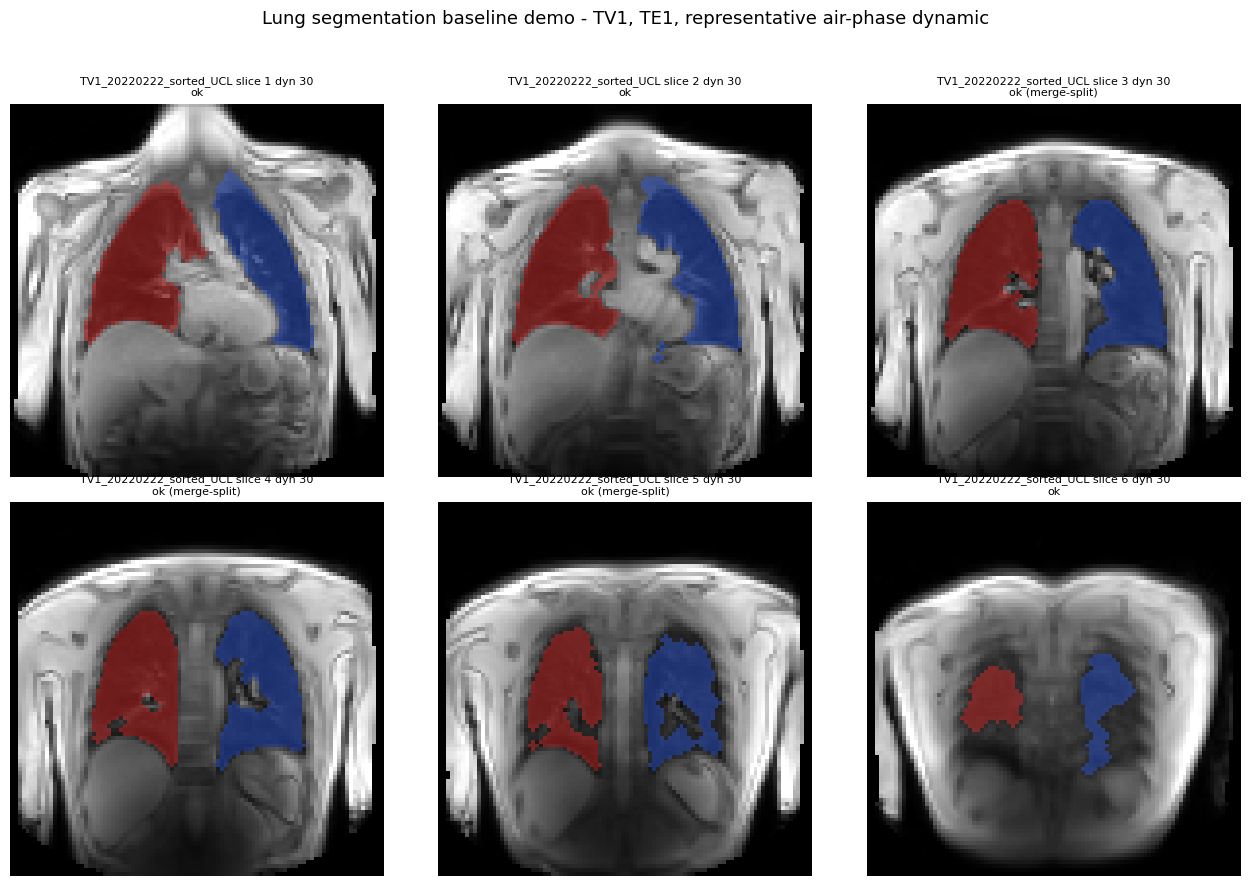

In [12]:
tv1_dir = TV_SUBJECT_DIRS[0]
tv1_demo_volume = load_tv_volume(tv1_dir)
demo_dynamic = 30

fig, axes = plt.subplots(2, 3, figsize=(13, 9))
for slice_num in range(1, NUM_SLICES + 1):
    ax = axes[(slice_num - 1) // 3, (slice_num - 1) % 3]
    img = get_tv_frame(tv1_demo_volume, slice_num=slice_num, echo_num=1, dynamic_num=demo_dynamic)
    seg = segment_lungs_te1(img)
    plot_segmentation_overlay(img, seg, ax=ax, title=f"{tv1_dir.name} slice {slice_num} dyn {demo_dynamic}")
fig.suptitle("Lung segmentation baseline demo - TV1, TE1, representative air-phase dynamic", fontsize=13)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [13]:
def process_subject(subject_dir: Path, excluded_slices: list[int] = ()) -> dict:
    """Compute the subject-level aggregate lung-area curve, the single
    max/min-expansion dynamic, per-slice masks/landmarks at that dynamic, and
    the subject-level landmark (median across slices). Does NOT compute a
    translation - that is QC-display-only and filled in later once
    TARGET_X/TARGET_Y are known (see the alignment section below).

    `excluded_slices` (see SUBJECT_SLICE_EXCLUSIONS) drops the listed slices
    from the aggregate curve's max/min-dynamic selection AND from the
    subject-level landmark median, even if that slice happens to produce a
    landmark at the chosen dynamic - a reliability exclusion (e.g. TV3 slice
    6 fails segmentation on 188/190 dynamics), not a contamination one. Each
    excluded slice's OWN segmentation-failure/temporal-rejection reliability
    is still captured independently (a single-slice curve call) and reported
    via `excluded_slice_diagnostics`, so it remains visible in detail_df
    rather than silently reading as 0 - transparency over hiding - while
    NOT being merged into `curve`'s own failure/rejection counts, since those
    should reflect only the active_slices curve actually driving selection.

    Both the max- AND min-expansion frames are segmented (min_masks/
    min_seg_reasons alongside the existing max_masks/max_seg_reasons) - the
    min-expansion image was already being loaded for min_te1_images, just
    never segmented, so this is a cheap completion (54 extra segmentations
    total across all datasets), not new expensive work.
    """
    volume = load_tv_volume(subject_dir)

    def get_te1(slice_num, dyn):
        return get_tv_frame(volume, slice_num=slice_num, echo_num=1, dynamic_num=dyn)

    active_slices = [s for s in range(1, NUM_SLICES + 1) if s not in excluded_slices]
    curve = compute_subject_aggregate_curve(get_te1, AIR_PHASE_DYNAMICS, slices=active_slices)
    max_dyn, min_dyn = curve["max_dynamic"], curve["min_dynamic"]

    excluded_slice_diagnostics = {}
    for excluded_slice in excluded_slices:
        excl_curve = compute_subject_aggregate_curve(get_te1, AIR_PHASE_DYNAMICS, slices=[excluded_slice])
        excluded_slice_diagnostics[excluded_slice] = {
            "seg_failures": len(excl_curve["per_slice_failed"][excluded_slice]),
            "temporally_rejected": len(excl_curve["per_slice_temporally_rejected"][excluded_slice]),
        }

    max_te1_images, min_te1_images = {}, {}
    max_masks, min_masks = {}, {}
    max_seg_reasons, min_seg_reasons = {}, {}
    landmarks = {}
    for slice_num in range(1, NUM_SLICES + 1):
        max_img = get_te1(slice_num, max_dyn)
        min_img = get_te1(slice_num, min_dyn)
        max_seg = segment_lungs_te1(max_img)
        min_seg = segment_lungs_te1(min_img)

        max_te1_images[slice_num] = max_img
        min_te1_images[slice_num] = min_img
        max_masks[slice_num] = max_seg["combined_mask"]
        min_masks[slice_num] = min_seg["combined_mask"]
        max_seg_reasons[slice_num] = max_seg["reason"]
        min_seg_reasons[slice_num] = min_seg["reason"]

        lm = estimate_landmarks(max_seg)
        if lm is None:
            print(f"WARNING: {subject_dir.name} slice {slice_num}: segmentation failed at the subject's "
                  f"max-expansion dynamic {max_dyn} (reason: {max_seg['reason']}) - excluded from this "
                  f"subject's landmark aggregate")
        landmarks[slice_num] = lm

    total_failed = sum(len(v) for v in curve["per_slice_failed"].values())
    total_rejected = sum(len(v) for v in curve["per_slice_temporally_rejected"].values())
    print(f"{subject_dir.name}: max expansion @ dynamic {max_dyn}, min expansion @ dynamic {min_dyn} "
          f"(segmentation failures: {total_failed}, temporally-rejected frames: {total_rejected}, "
          f"out of {len(active_slices) * len(AIR_PHASE_DYNAMICS)} slice-dynamic pairs"
          + (f", slices {sorted(excluded_slices)} excluded from the curve" if excluded_slices else "") + ")")
    for slice_num, diag in excluded_slice_diagnostics.items():
        print(f"  (excluded slice {slice_num}: {diag['seg_failures']}/{len(AIR_PHASE_DYNAMICS)} segmentation "
              f"failures on its own, {diag['temporally_rejected']} temporally-rejected - a reliability "
              f"problem for this slice specifically, not counted in the totals above)")

    valid_landmarks = [lm for slice_num, lm in landmarks.items()
                       if lm is not None and slice_num not in excluded_slices]
    subject_landmark = None
    if valid_landmarks:
        subject_landmark = {
            "mid_x": float(np.median([lm["mid_x"] for lm in valid_landmarks])),
            "diaphragm_y": float(np.median([lm["diaphragm_y"] for lm in valid_landmarks])),
            "n_slices": len(valid_landmarks),
        }
    else:
        print(f"WARNING: {subject_dir.name}: no slice produced a valid landmark - this subject cannot be aligned")

    return {
        "subject_name": subject_dir.name, "curve": curve, "max_dynamic": max_dyn, "min_dynamic": min_dyn,
        "landmarks": landmarks, "subject_landmark": subject_landmark,
        "max_seg_reasons": max_seg_reasons, "min_seg_reasons": min_seg_reasons,
        "max_te1_images": max_te1_images, "min_te1_images": min_te1_images,
        "max_masks": max_masks, "min_masks": min_masks,
        "excluded_slices": list(excluded_slices), "excluded_slice_diagnostics": excluded_slice_diagnostics,
    }


def process_iqt() -> dict:
    """Same as `process_subject`, for the IQT HR scan (30 dynamics). No slice
    exclusions apply to IQT HR - `excluded_slices`/`excluded_slice_diagnostics`
    are still populated (empty) purely for schema consistency across
    combined_results."""
    def get_te1(slice_num, dyn):
        return load_iqt_hr_frame(slice_num=slice_num, echo_num=1, dynamic_num=dyn)

    curve = compute_subject_aggregate_curve(get_te1, IQT_DYNAMICS)
    max_dyn, min_dyn = curve["max_dynamic"], curve["min_dynamic"]

    max_te1_images, min_te1_images = {}, {}
    max_masks, min_masks = {}, {}
    max_seg_reasons, min_seg_reasons = {}, {}
    landmarks = {}
    for slice_num in range(1, NUM_SLICES + 1):
        max_img = get_te1(slice_num, max_dyn)
        min_img = get_te1(slice_num, min_dyn)
        max_seg = segment_lungs_te1(max_img)
        min_seg = segment_lungs_te1(min_img)

        max_te1_images[slice_num] = max_img
        min_te1_images[slice_num] = min_img
        max_masks[slice_num] = max_seg["combined_mask"]
        min_masks[slice_num] = min_seg["combined_mask"]
        max_seg_reasons[slice_num] = max_seg["reason"]
        min_seg_reasons[slice_num] = min_seg["reason"]

        lm = estimate_landmarks(max_seg)
        if lm is None:
            print(f"WARNING: IQT HR slice {slice_num}: segmentation failed at the max-expansion dynamic "
                  f"{max_dyn} (reason: {max_seg['reason']}) - excluded from IQT's landmark aggregate")
        landmarks[slice_num] = lm

    total_failed = sum(len(v) for v in curve["per_slice_failed"].values())
    total_rejected = sum(len(v) for v in curve["per_slice_temporally_rejected"].values())
    print(f"IQT HR: max expansion @ dynamic {max_dyn}, min expansion @ dynamic {min_dyn} "
          f"(segmentation failures: {total_failed}, temporally-rejected frames: {total_rejected}, "
          f"out of {NUM_SLICES * len(IQT_DYNAMICS)} slice-dynamic pairs)")

    valid_landmarks = [lm for lm in landmarks.values() if lm is not None]
    subject_landmark = None
    if valid_landmarks:
        subject_landmark = {
            "mid_x": float(np.median([lm["mid_x"] for lm in valid_landmarks])),
            "diaphragm_y": float(np.median([lm["diaphragm_y"] for lm in valid_landmarks])),
            "n_slices": len(valid_landmarks),
        }
    else:
        print("WARNING: IQT HR: no slice produced a valid landmark")

    return {
        "subject_name": "IQT_HR", "curve": curve, "max_dynamic": max_dyn, "min_dynamic": min_dyn,
        "landmarks": landmarks, "subject_landmark": subject_landmark,
        "max_seg_reasons": max_seg_reasons, "min_seg_reasons": min_seg_reasons,
        "max_te1_images": max_te1_images, "min_te1_images": min_te1_images,
        "max_masks": max_masks, "min_masks": min_masks,
        "excluded_slices": [], "excluded_slice_diagnostics": {},
    }

## Step 2 (demo) -- Aggregate lung expansion over time: TV1 and IQT HR

For every subject/scan, segment all 6 slices at every dynamic, apply the
temporal-consistency filter, sum the areas into one aggregate curve, and
select a single subject-level maximum- and minimum-expansion dynamic.

TV1_20220222_sorted_UCL: max expansion @ dynamic 226, min expansion @ dynamic 30 (segmentation failures: 9, temporally-rejected frames: 0, out of 1140 slice-dynamic pairs)


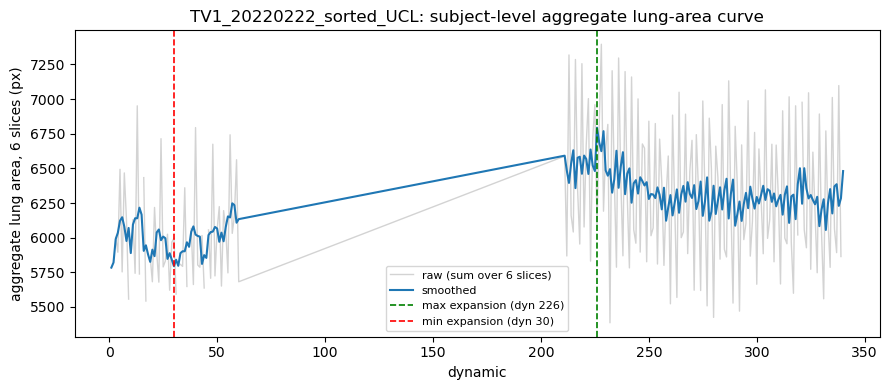

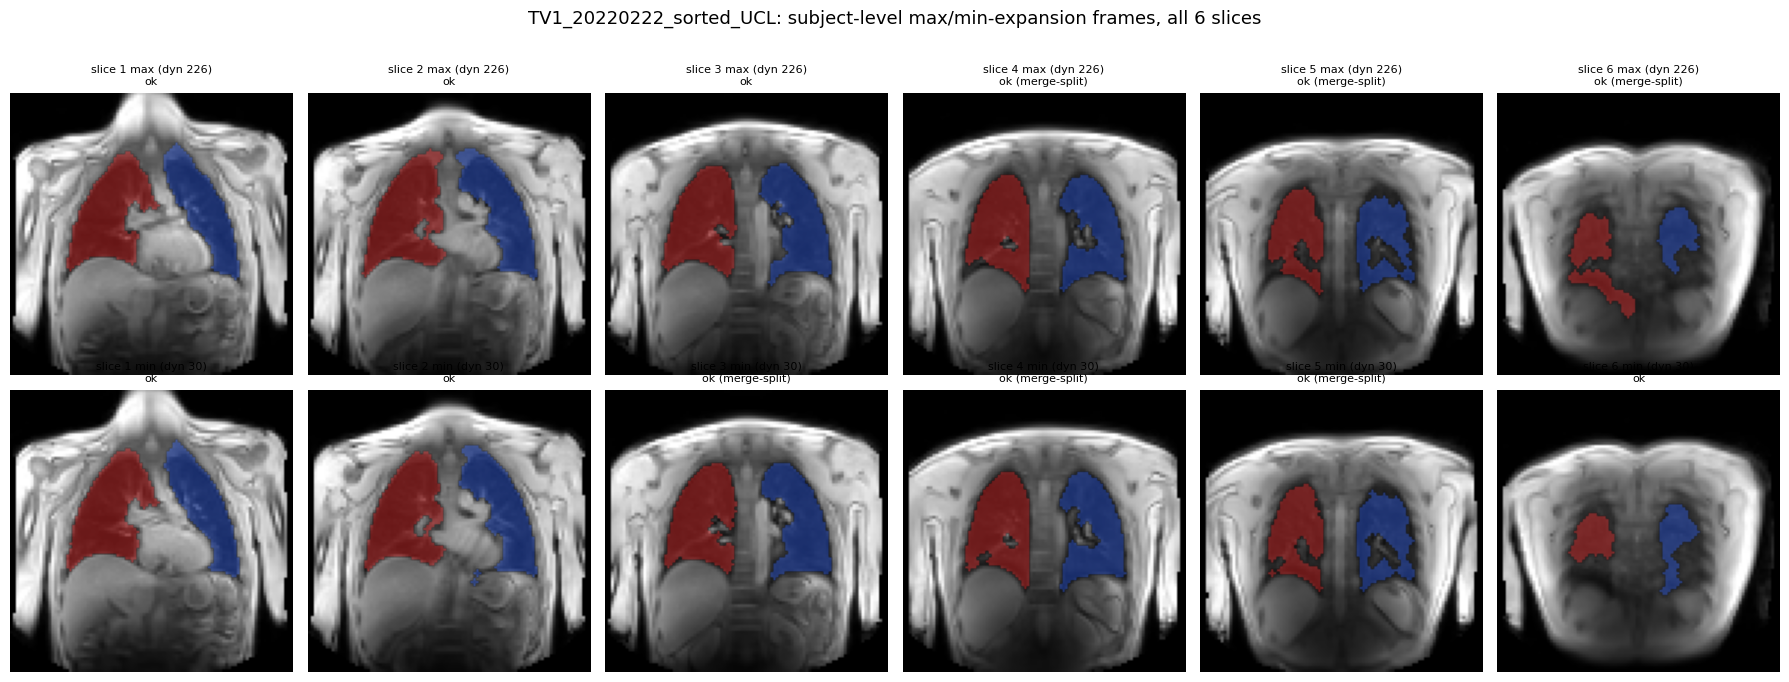

IQT HR: max expansion @ dynamic 6, min expansion @ dynamic 13 (segmentation failures: 13, temporally-rejected frames: 0, out of 180 slice-dynamic pairs)


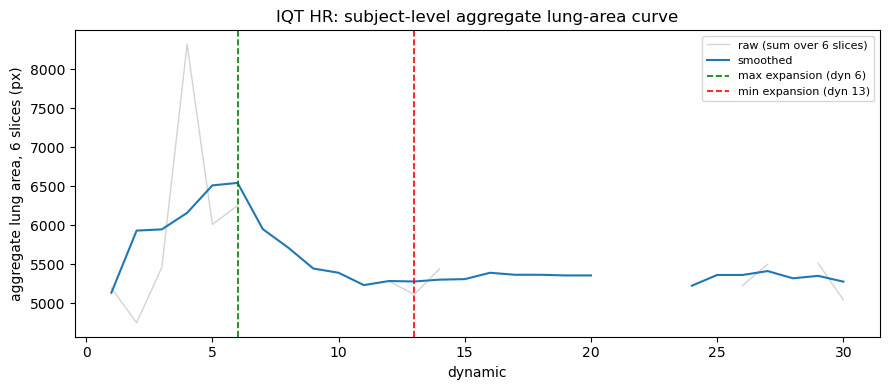

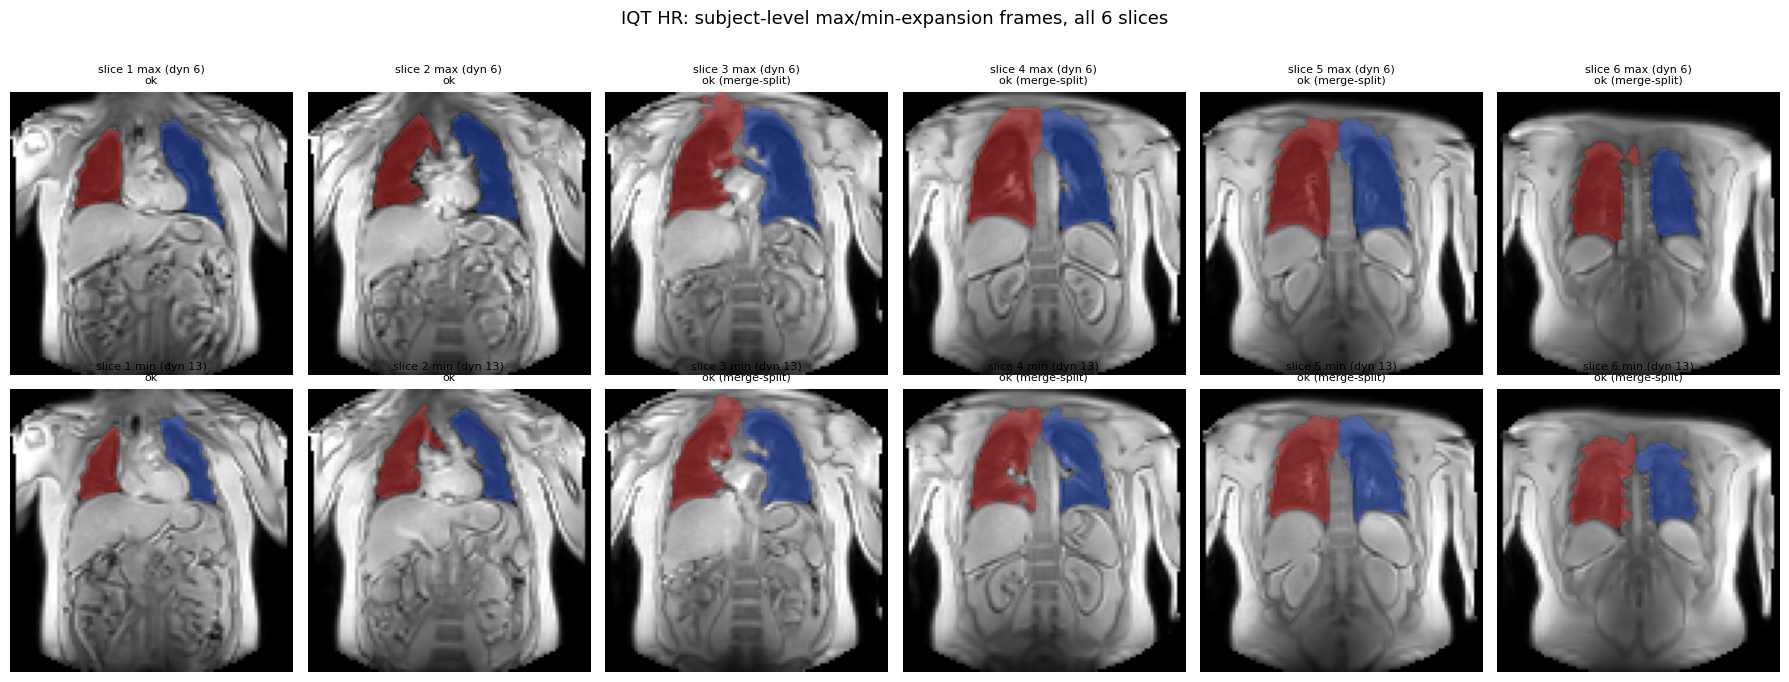

In [14]:
tv1_results = process_subject(tv1_dir, excluded_slices=SUBJECT_SLICE_EXCLUSIONS.get(tv1_dir.name, []))
plot_aggregate_curve(tv1_results, tv1_dir.name)
plot_max_min_review(tv1_results, tv1_dir.name)

iqt_results = process_iqt()
plot_aggregate_curve(iqt_results, "IQT HR")
plot_max_min_review(iqt_results, "IQT HR")

## Generalise to TV2-TV8

The demo above validated the aggregate-curve method and segmentation on TV1
and IQT HR. The same functions are now applied, unchanged, to the remaining
TV subjects.

In [15]:
all_subject_results = {tv1_dir.name: tv1_results}
for subject_dir in TV_SUBJECT_DIRS[1:]:
    all_subject_results[subject_dir.name] = process_subject(
        subject_dir, excluded_slices=SUBJECT_SLICE_EXCLUSIONS.get(subject_dir.name, [])
    )

TV2_20220222_sorted_UCL: max expansion @ dynamic 223, min expansion @ dynamic 335 (segmentation failures: 53, temporally-rejected frames: 16, out of 1140 slice-dynamic pairs)


TV3_20220208_sorted_UCL: max expansion @ dynamic 217, min expansion @ dynamic 322 (segmentation failures: 2, temporally-rejected frames: 0, out of 950 slice-dynamic pairs, slices [6] excluded from the curve)
  (excluded slice 6: 188/190 segmentation failures on its own, 0 temporally-rejected - a reliability problem for this slice specifically, not counted in the totals above)


TV4_20220204_sorted_UCL: max expansion @ dynamic 216, min expansion @ dynamic 267 (segmentation failures: 0, temporally-rejected frames: 0, out of 1140 slice-dynamic pairs)


TV5_20220307_sorted_UCL: max expansion @ dynamic 217, min expansion @ dynamic 338 (segmentation failures: 1, temporally-rejected frames: 0, out of 1140 slice-dynamic pairs)


TV6_20220307_sorted_UCL: max expansion @ dynamic 249, min expansion @ dynamic 39 (segmentation failures: 0, temporally-rejected frames: 0, out of 1140 slice-dynamic pairs)


TV7_20220315_sorted_UCL: max expansion @ dynamic 214, min expansion @ dynamic 295 (segmentation failures: 81, temporally-rejected frames: 0, out of 1140 slice-dynamic pairs)


TV8_20220307_sorted_UCL: max expansion @ dynamic 236, min expansion @ dynamic 216 (segmentation failures: 0, temporally-rejected frames: 0, out of 1140 slice-dynamic pairs)


## Diagnostics: slices-1-4-only aggregate curve, IQT HR per-slice-over-time, and
## contamination screening

Three diagnostics computed now that all 8 TV subjects + IQT are available. The
contamination screen is referenced later by both the landmark-quality diagnostic and the
Step 5 crop-feasibility analysis - one shared flag, not two separately-computed ones that
could disagree.

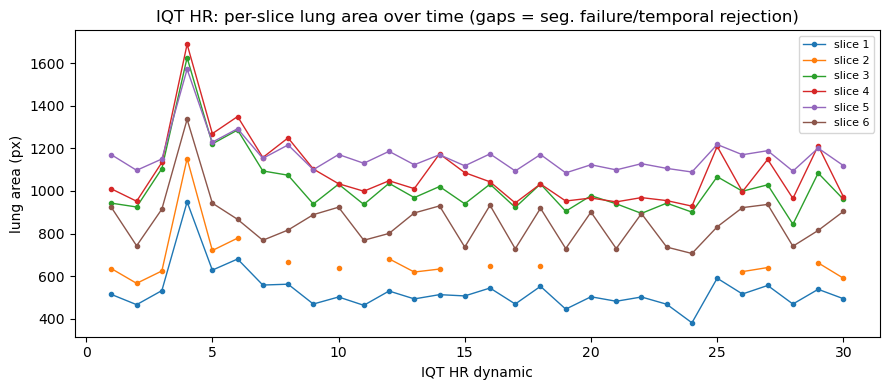

Per-slice max/min area ratio (IQT HR). NOTE: TEMPORAL_MAX_AREA_RATIO_JUMP=3.0 only bounds STEP-TO-STEP consistency against a running median that itself drifts - a slice can exceed it GLOBALLY via many individually-passing small steps (gradual drift), which the existing check cannot catch. Flagged separately below from a near-miss (2.0-3.0x) that never even approached rejection.

  slice 1: min=382 max=949 ratio=2.48 <-- FLAG: near-miss (2.0-3.0x)
  slice 2: min=567 max=1152 ratio=2.03 <-- FLAG: near-miss (2.0-3.0x)
  slice 3: min=844 max=1625 ratio=1.93
  slice 4: min=929 max=1688 ratio=1.82
  slice 5: min=1085 max=1571 ratio=1.45
  slice 6: min=707 max=1336 ratio=1.89


In [16]:
## IQT HR per-slice-over-time diagnostic - checks whether slices 3-5 are over-segmented
## ACROSS TIME (all 30 dynamics), not just at the single already-picked max-expansion
## dynamic the contamination screen (below) evaluates.
iqt_per_slice_areas = iqt_results["curve"]["per_slice_areas"]

fig, ax = plt.subplots(figsize=(9, 4))
for slice_num in range(1, NUM_SLICES + 1):
    areas = [iqt_per_slice_areas[slice_num][d] for d in IQT_DYNAMICS]
    ax.plot(IQT_DYNAMICS, areas, marker="o", ms=3, lw=1, label=f"slice {slice_num}")
ax.set_xlabel("IQT HR dynamic")
ax.set_ylabel("lung area (px)")
ax.set_title("IQT HR: per-slice lung area over time (gaps = seg. failure/temporal rejection)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print(f"Per-slice max/min area ratio (IQT HR). NOTE: TEMPORAL_MAX_AREA_RATIO_JUMP={TEMPORAL_MAX_AREA_RATIO_JUMP} "
      f"only bounds STEP-TO-STEP consistency against a running median that itself drifts - a slice can "
      f"exceed it GLOBALLY via many individually-passing small steps (gradual drift), which the existing "
      f"check cannot catch. Flagged separately below from a near-miss (2.0-3.0x) that never even "
      f"approached rejection.\n")
for slice_num in range(1, NUM_SLICES + 1):
    vals = np.array([v for v in iqt_per_slice_areas[slice_num].values() if not np.isnan(v)])
    if vals.size == 0:
        print(f"  slice {slice_num}: no successfully-segmented dynamics")
        continue
    ratio = vals.max() / vals.min() if vals.min() > 0 else np.inf
    if ratio >= TEMPORAL_MAX_AREA_RATIO_JUMP:
        flag = " <-- FLAG: exceeds threshold GLOBALLY despite passing every step-to-step check (drift)"
    elif ratio >= 2.0:
        flag = " <-- FLAG: near-miss (2.0-3.0x)"
    else:
        flag = ""
    print(f"  slice {slice_num}: min={vals.min():.0f} max={vals.max():.0f} ratio={ratio:.2f}{flag}")

In [17]:
combined_results = {**all_subject_results, "IQT_HR": iqt_results}


def compute_contamination_flags(all_results: dict) -> dict:
    """One shared contamination-flagging pass, computed once per (subject,
    slice) across ALL 6 slices of every subject + IQT - not separately
    computed checks that happen to agree on the worst cases and could in
    principle disagree on others.

    Combines two complementary rules (neither alone is sufficient):
      - shape rule (unimodality): a coronal stack's area profile should rise
        toward mid-chest and fall toward the periphery. Flags a local dip (a
        slice smaller than both neighbours - under-segmentation on a mid
        slice) or a rise in the final step (slice 6 larger than slice 5 -
        over-segmentation/border contamination). This alone is
        scale-invariant (a uniformly shifted/scaled profile still "looks"
        unimodal) and only flags transitions, not slices - a peripheral
        slice sandwiched between two other elevated slices (monotone
        through it) is invisible to this rule alone.
      - magnitude rule: flags a peripheral slice (5 or 6) whose area exceeds
        max(that same subject's own slices 1-4). Catches exactly the cases
        the shape rule misses.

    Also reports (does NOT use to exclude anything) the peak slice index -
    a peak at slice 5/6 is ambiguous between contamination and genuine
    differing slab positioning between subjects and must not, by itself,
    add or remove a slice from the flagged set - and whether any mask
    touches the image border (rows.max() == IMG_SIZE - 1), which indicates
    segment_lungs_te1's border-exclusion guarantee did not hold for the
    final returned mask.

    EXTENDED (coverage-gap fix): the two rules above only ever see ONE
    snapshot per subject - the already-selected max-expansion dynamic. That
    is a real blind spot: compute_subject_required_extents (the per-subject
    crop-extent scan) scans EVERY dynamic and keeps the MAX extent seen, so
    a single bad dynamic anywhere else in the range can dominate that
    subject's derived crop size while this screen stays "not flagged" for
    it. Confirmed live: TV2 slice 5 dyn 30, TV3 slice 6 dyn 41 and TV6 slice
    6 dyn 49 are all visibly non-lung artifacts (shoulder/arm tissue, not
    lungs) that the snapshot-only rules above never see. The same
    shape+magnitude rule is therefore ALSO evaluated at every dynamic where
    all 6 slices have a simultaneously-valid area - reusing
    `curve["per_slice_areas"]`, already computed by
    compute_subject_aggregate_curve, so this costs no new segmentation. A
    slice is `full_range_flagged` if the rule fires at ANY such dynamic:
    even one confirmed-bad frame is enough to poison a max-over-all-dynamics
    extent scan, so "flagged once" is the right bar here, not "flagged
    often". Folded into `all_flags` alongside the original two rules.

    A subject whose curve excludes a slice (SUBJECT_SLICE_EXCLUSIONS,
    currently only TV3 slice 6) cannot be full-range-screened AT ALL this
    way - `per_slice_areas` has no data for the missing slice, and the
    6-wide shape/magnitude comparison needs every slice present. Recorded as
    `full_range_note` rather than silently reporting "not flagged" for a
    slice this pass never actually looked at; that slice's exclusion instead
    rests on whatever other evidence already justified dropping it (TV3
    slice 6's own 188/190 segmentation-failure rate).
    """
    report = {}
    for name, res in all_results.items():
        areas, extents = [], []
        border_touch = set()
        for slice_num in range(1, NUM_SLICES + 1):
            mask = res["max_masks"][slice_num]
            rows, cols = np.nonzero(mask)
            if rows.size == 0:
                areas.append(0)
                extents.append(0)
                continue
            areas.append(int(mask.sum()))
            extents.append(int(rows.max() - rows.min()))
            if rows.max() == IMG_SIZE - 1:
                border_touch.add(slice_num)

        peak_slice = int(np.argmax(areas)) + 1

        shape_flags = set()
        for i in range(1, 5):  # slices 2-5 (0-indexed 1-4): local-dip check
            if areas[i] < areas[i - 1] and areas[i] < areas[i + 1]:
                shape_flags.add(i + 1)
        if areas[5] > areas[4]:  # slice 6 > slice 5: final-step rise
            shape_flags.add(6)

        baseline = max(areas[:4])
        magnitude_flags = {s for s in (5, 6) if areas[s - 1] > baseline}

        # --- full-dynamic-range extension (coverage-gap fix) ---
        per_slice_areas = res["curve"]["per_slice_areas"]
        available_slices = sorted(per_slice_areas.keys())
        full_range_flagged: dict[int, list[int]] = {}
        full_range_note = None
        if len(available_slices) == NUM_SLICES:
            common_dynamics = sorted(
                set.intersection(*(set(per_slice_areas[s].keys()) for s in available_slices))
            )
            for dyn in common_dynamics:
                dyn_areas = [per_slice_areas[s][dyn] for s in available_slices]
                if any(np.isnan(a) for a in dyn_areas):
                    continue
                dyn_shape = set()
                for i in range(1, 5):
                    if dyn_areas[i] < dyn_areas[i - 1] and dyn_areas[i] < dyn_areas[i + 1]:
                        dyn_shape.add(available_slices[i])
                if dyn_areas[5] > dyn_areas[4]:
                    dyn_shape.add(available_slices[5])
                dyn_baseline = max(dyn_areas[:4])
                dyn_magnitude = {available_slices[i] for i in (4, 5) if dyn_areas[i] > dyn_baseline}
                for s in dyn_shape | dyn_magnitude:
                    full_range_flagged.setdefault(s, []).append(dyn)
        else:
            full_range_note = (
                f"only {len(available_slices)}/{NUM_SLICES} slices in curve "
                f"(SUBJECT_SLICE_EXCLUSIONS) - full-range screen skipped entirely for this "
                f"subject, missing slice already excluded on other grounds"
            )

        n_dynamics_evaluated = len(common_dynamics) if len(available_slices) == NUM_SLICES else 0
        report[name] = {
            "areas": areas, "extents": extents, "peak_slice": peak_slice,
            "shape_flags": shape_flags, "magnitude_flags": magnitude_flags,
            "border_touch": border_touch,
            "full_range_flagged_slices": full_range_flagged, "full_range_note": full_range_note,
            "n_dynamics_evaluated": n_dynamics_evaluated,
            "all_flags": shape_flags | magnitude_flags | set(full_range_flagged.keys()),
        }
    return report


contamination_report = compute_contamination_flags(combined_results)

# Population diaphragm_y values, used below to check whether a peripheral-peak subject's
# apparent contamination is corroborated by independent (non-segmentation) evidence, or
# contradicted by it (this subject's lungs may simply sit at a different position in the
# frame - a peak at slice 5/6 alone cannot distinguish the two).
_diaphragm_ys = {n: r["subject_landmark"]["diaphragm_y"] for n, r in combined_results.items()
                 if r["subject_landmark"] is not None}
_dy_min, _dy_max = min(_diaphragm_ys.values()), max(_diaphragm_ys.values())

print("Contamination screening (shape + magnitude rules, peak-location diagnostic) - computed "
      "once here and referenced by both the item-10 residual diagnostic below and the Step 5 "
      "crop-feasibility exclusion, so the two can't disagree:\n")
for name, rep in contamination_report.items():
    peak = rep["peak_slice"]
    print(f"{name}: areas={rep['areas']} peak=slice{peak}")
    if rep["shape_flags"]:
        print(f"   shape-rule flags: {sorted(rep['shape_flags'])}")
    if rep["magnitude_flags"]:
        print(f"   magnitude-rule flags: {sorted(rep['magnitude_flags'])}")
    if rep["full_range_flagged_slices"]:
        for s, dyns in sorted(rep["full_range_flagged_slices"].items()):
            print(f"   FULL-RANGE flag: slice {s} fires the shape/magnitude rule at "
                  f"{len(dyns)} dynamic(s) (e.g. dyn {dyns[0]}) - invisible to the single-snapshot "
                  f"rules above, which only ever see this subject's max-expansion dynamic")
    if rep["full_range_note"]:
        print(f"   {rep['full_range_note']}")
    if rep["border_touch"]:
        print(f"   WARNING: mask touches the image border (row {IMG_SIZE - 1}) at slice(s) "
              f"{sorted(rep['border_touch'])} - segment_lungs_te1's 'candidates touching the "
              f"image border are dropped' guarantee did not hold for the final returned mask "
              f"(clear_border runs before the final binary_opening/binary_closing step, whose "
              f"dilation can push a pixel back across the border)")

    is_peripheral_peak = peak >= 5
    this_dy = _diaphragm_ys.get(name)
    is_dy_extreme = this_dy is not None and this_dy in (_dy_min, _dy_max)

    if is_peripheral_peak and is_dy_extreme:
        extreme_label = "minimum" if this_dy == _dy_min else "maximum"
        rule_note = (f"neither the shape nor magnitude rule fires" if not rep["all_flags"] else
                     f"a shape/magnitude rule fired on slice(s) {sorted(rep['all_flags'])}")
        print(f"   ANOMALOUS, CAUSE UNRESOLVED: peak at slice {peak} coincides with this subject's "
              f"diaphragm_y ({this_dy:.1f}) being the {extreme_label} across all {len(_diaphragm_ys)} "
              f"datasets - independent, non-segmentation evidence that this subject's lungs may "
              f"genuinely sit at a different position in the frame, not that its peripheral-slice "
              f"masks are contaminated ({rule_note}). Do NOT treat this subject as cleared or as "
              f"confirmed-contaminated - any flags above for this subject's peripheral slices should "
              f"be read as unresolved for this specific subject, not as confirmed contamination the "
              f"way they would be for a subject with no such corroborating evidence.")
    elif is_peripheral_peak and not rep["all_flags"]:
        landmark = combined_results[name]["subject_landmark"]
        print(f"   ANOMALOUS, CAUSE UNRESOLVED: peak at slice {peak} but neither the shape nor "
              f"magnitude rule fires - do NOT treat as cleared or as contaminated. subject "
              f"diaphragm_y={landmark['diaphragm_y']:.1f} (not a population extreme here, so no "
              f"corroborating evidence either way; investigate independently).")
    elif not rep["all_flags"]:
        print("   no violations")
    print()

Contamination screening (shape + magnitude rules, peak-location diagnostic) - computed once here and referenced by both the item-10 residual diagnostic below and the Step 5 crop-feasibility exclusion, so the two can't disagree:

TV1_20220222_sorted_UCL: areas=[1194, 1287, 1207, 1088, 809, 510] peak=slice2
   FULL-RANGE flag: slice 3 fires the shape/magnitude rule at 1 dynamic(s) (e.g. dyn 227) - invisible to the single-snapshot rules above, which only ever see this subject's max-expansion dynamic

TV2_20220222_sorted_UCL: areas=[684, 768, 907, 954, 826, 550] peak=slice4
   FULL-RANGE flag: slice 2 fires the shape/magnitude rule at 1 dynamic(s) (e.g. dyn 7) - invisible to the single-snapshot rules above, which only ever see this subject's max-expansion dynamic
   FULL-RANGE flag: slice 5 fires the shape/magnitude rule at 9 dynamic(s) (e.g. dyn 21) - invisible to the single-snapshot rules above, which only ever see this subject's max-expansion dynamic
   FULL-RANGE flag: slice 6 fires th

In [18]:
## Task 1 -- pixel spacing / implied FOV diagnostic (no zoom code yet)
tv1_dicom_path = find_tv_dicom_file(tv1_dir)
tv1_ds = pydicom.dcmread(str(tv1_dicom_path))

tv1_pixel_spacing = None
tv1_spacing_source = None
try:
    tv1_pixel_spacing = tv1_ds.SharedFunctionalGroupsSequence[0].PixelMeasuresSequence[0].PixelSpacing
    tv1_spacing_source = "SharedFunctionalGroupsSequence[0].PixelMeasuresSequence[0].PixelSpacing"
except (AttributeError, IndexError):
    pass
if tv1_pixel_spacing is None:
    try:
        tv1_pixel_spacing = tv1_ds.PerFrameFunctionalGroupsSequence[0].PixelMeasuresSequence[0].PixelSpacing
        tv1_spacing_source = "PerFrameFunctionalGroupsSequence[0].PixelMeasuresSequence[0].PixelSpacing"
    except (AttributeError, IndexError):
        pass
if tv1_pixel_spacing is None:
    try:
        tv1_pixel_spacing = tv1_ds.PixelSpacing
        tv1_spacing_source = "ds.PixelSpacing"
    except AttributeError:
        pass

print(f"TV1 DICOM: {tv1_dicom_path.name}")
if tv1_pixel_spacing is not None:
    print(f"  PixelSpacing: {list(tv1_pixel_spacing)} mm (source: {tv1_spacing_source})")
else:
    print("  PixelSpacing: NOT FOUND in any of the three locations tried")
print(f"  Rows: {getattr(tv1_ds, 'Rows', 'N/A')}, Columns: {getattr(tv1_ds, 'Columns', 'N/A')}")
print(f"  SliceThickness: {getattr(tv1_ds, 'SliceThickness', 'N/A')}")
print(f"  SpacingBetweenSlices: {getattr(tv1_ds, 'SpacingBetweenSlices', 'N/A')}")

# IQT HR / LR in-plane voxel size - from the already-built iqt_hr_df/iqt_lr_df "zooms" column
# (each row's zooms is (dx, dy, dz, dt) from nibabel's header.get_zooms()).
for label, df in [("IQT HR", iqt_hr_df), ("IQT LR", iqt_lr_df)]:
    zooms_inplane = df["zooms"].apply(lambda z: (z[0], z[1]))
    unique_zooms = zooms_inplane.unique()
    assert len(unique_zooms) == 1, f"{label}: in-plane voxel size is not constant across files: {unique_zooms}"
    dx, dy = unique_zooms[0]
    print(f"{label}: in-plane voxel size = ({dx}, {dy}) mm (constant across all {len(df)} files)")

# Implied in-plane FOV (mm) = spacing x matrix size, for all three.
if tv1_pixel_spacing is not None:
    tv_fov = (float(tv1_pixel_spacing[0]) * IMG_SIZE, float(tv1_pixel_spacing[1]) * IMG_SIZE)
    print(f"\nTV1 implied in-plane FOV: {tv_fov[0]:.1f} x {tv_fov[1]:.1f} mm ({IMG_SIZE}x{IMG_SIZE} px)")
else:
    print("\nTV1 implied in-plane FOV: cannot compute, PixelSpacing not found")

iqt_hr_zoom = iqt_hr_df["zooms"].iloc[0]
iqt_hr_shape = iqt_hr_df["shape"].iloc[0]
iqt_hr_fov = (float(iqt_hr_zoom[0]) * iqt_hr_shape[0], float(iqt_hr_zoom[1]) * iqt_hr_shape[1])
print(f"IQT HR implied in-plane FOV: {iqt_hr_fov[0]:.1f} x {iqt_hr_fov[1]:.1f} mm ({iqt_hr_shape[0]}x{iqt_hr_shape[1]} px)")

iqt_lr_zoom = iqt_lr_df["zooms"].iloc[0]
iqt_lr_shape = iqt_lr_df["shape"].iloc[0]
iqt_lr_fov = (float(iqt_lr_zoom[0]) * iqt_lr_shape[0], float(iqt_lr_zoom[1]) * iqt_lr_shape[1])
print(f"IQT LR implied in-plane FOV: {iqt_lr_fov[0]:.1f} x {iqt_lr_fov[1]:.1f} mm ({iqt_lr_shape[0]}x{iqt_lr_shape[1]} px)")

TV1 DICOM: IM_0028
  PixelSpacing: ['4.6875', '4.6875'] mm (source: PerFrameFunctionalGroupsSequence[0].PixelMeasuresSequence[0].PixelSpacing)
  Rows: 96, Columns: 96
  SliceThickness: N/A
  SpacingBetweenSlices: N/A
IQT HR: in-plane voxel size = (1.0, 1.0) mm (constant across all 360 files)
IQT LR: in-plane voxel size = (1.0, 1.0) mm (constant across all 360 files)

TV1 implied in-plane FOV: 450.0 x 450.0 mm (96x96 px)
IQT HR implied in-plane FOV: 96.0 x 96.0 mm (96x96 px)
IQT LR implied in-plane FOV: 64.0 x 64.0 mm (64x64 px)


## Step 3 & 4 -- Alignment target (median across all TV subjects) and landmark-quality diagnostic

`TARGET_X`/`TARGET_Y` is the **median** of every TV subject's landmark,
computed now that all 8 have been processed. It is used only as a reference
point for the landmark-quality residual check below - the actual data path
(Step 5) crops each subject using its own landmark directly, with no
shared-target shift involved.

The landmark-quality check reports, per subject: how many slices produced a
clean vs. merge-split segmentation (neither is treated as a defect - both are
`success=True`), and each slice's residual from the subject's own median
landmark, cross-referenced against the contamination screen computed above -
where the two agree, that is corroboration between independent signals, not
two separate verdicts. This pass is diagnostic-only (see the printed
distribution below) rather than hard-gated, since the thresholds aren't
calibrated yet against a full observed distribution.

In [19]:
valid_subject_landmarks = [res["subject_landmark"] for res in all_subject_results.values() if res["subject_landmark"] is not None]
assert valid_subject_landmarks, "No TV subject produced a valid landmark - cannot derive an alignment target"

TARGET_X = float(np.median([sl["mid_x"] for sl in valid_subject_landmarks]))
TARGET_Y = float(np.median([sl["diaphragm_y"] for sl in valid_subject_landmarks]))
print(f"Common alignment target (median across {len(valid_subject_landmarks)}/{len(all_subject_results)} "
      f"TV subjects): x={TARGET_X:.1f}, y={TARGET_Y:.1f}")


Common alignment target (median across 8/8 TV subjects): x=48.0, y=54.0


In [20]:
def assess_subject_alignment_quality(result: dict, name: str) -> dict:
    """Landmark-quality diagnostic, replacing the old translation-magnitude
    outlier test (which would have wrongly rejected a subject genuinely
    positioned far from the population median - exactly the thing alignment
    exists to correct for).

    This pass is diagnostic-only: ALIGNMENT_MIN_VALID_SLICES and
    ALIGNMENT_MAX_RESIDUAL_PX are printed as warnings, not hard gates -
    `alignment_ok` is False only when there is literally no valid landmark
    (subject_landmark is None). Each residual that exceeds
    ALIGNMENT_MAX_RESIDUAL_PX is cross-checked against `contamination_report`
    (computed once, above, and shared with the Step 5 crop-feasibility
    exclusion) - when a slice's residual AND its shape/magnitude flag both
    fire, that agreement is corroboration between two independent
    measurements of the same underlying problem, not two separate verdicts
    that happen to coincide. This is kept as a warning only because the
    threshold isn't calibrated yet against a full observed distribution, not
    because a residual-based signal is inherently unreliable.
    """
    landmark = result["subject_landmark"]
    if landmark is None:
        return {"alignment_ok": False, "alignment_reason": "no valid landmark on any slice",
                "n_clean": 0, "n_merge_split": 0, "residuals": {}}

    reasons = result["max_seg_reasons"]
    n_clean = sum(1 for r in reasons.values() if r == "ok")
    n_merge_split = sum(1 for r in reasons.values() if r == "ok (merge-split)")

    residuals = {
        slice_num: abs(lm["diaphragm_y"] - landmark["diaphragm_y"])
        for slice_num, lm in result["landmarks"].items() if lm is not None
    }

    warnings = []
    if landmark["n_slices"] < ALIGNMENT_MIN_VALID_SLICES:
        warnings.append(f"only {landmark['n_slices']}/{NUM_SLICES} slices produced a landmark")

    flagged_slices = contamination_report[name]["all_flags"]
    for slice_num, residual in residuals.items():
        if residual > ALIGNMENT_MAX_RESIDUAL_PX:
            corroborated = slice_num in flagged_slices
            note = (" - CORROBORATED by the shape/magnitude contamination screen (independent "
                    "agreement, not a coincidence)" if corroborated else
                    " - not corroborated by the shape/magnitude screen; investigate independently")
            warnings.append(
                f"slice {slice_num}'s diaphragm_y deviates {residual:.1f}px from the subject "
                f"median (threshold {ALIGNMENT_MAX_RESIDUAL_PX}px){note}"
            )

    return {
        "alignment_ok": True,  # this pass: only "no landmark at all" is a hard failure
        "alignment_reason": "; ".join(warnings) if warnings else "ok",
        "n_clean": n_clean, "n_merge_split": n_merge_split, "residuals": residuals,
    }


print("Landmark-quality diagnostic (residuals, ok/merge-split counts, cross-referenced against")
print("the contamination screen above) - all WARNINGS this pass, none gate alignment. Note:")
print("ALIGNMENT_MIN_VALID_SLICES/ALIGNMENT_MAX_RESIDUAL_PX are warnings only because the")
print("thresholds aren't calibrated yet against a full observed distribution, NOT because a")
print("residual-based signal is unreliable - where it agrees with the independent contamination")
print("screen, that agreement is itself evidence the signal is picking up something real.\n")

for name, res in combined_results.items():
    quality = assess_subject_alignment_quality(res, name)
    res["alignment_ok"] = quality["alignment_ok"]
    res["alignment_reason"] = quality["alignment_reason"]
    res["quality_diagnostic"] = quality
    residual_str = ", ".join(f"s{s}={r:.1f}" for s, r in sorted(quality["residuals"].items()))
    print(f"{name}: {quality['n_clean']}/{NUM_SLICES} clean, {quality['n_merge_split']}/{NUM_SLICES} merge-split, "
          f"residuals px [{residual_str}]")
    if quality["alignment_reason"] != "ok":
        print(f"   {quality['alignment_reason']}")

n_aligned = sum(1 for r in all_subject_results.values() if r["alignment_ok"])
print(f"\nTV subjects with a usable landmark: {n_aligned} / {len(all_subject_results)}")
print(f"IQT HR usable landmark: {iqt_results['alignment_ok']}")
print(f"\nNOTE: alignment_ok is trivially True for all {len(combined_results)} datasets this run "
      f"(items 4-6 restored 6/6-slice landmark coverage everywhere, so subject_landmark is never "
      f"None) - the 'NOT ALIGNED'/crop-population-exclusion code paths downstream have no live "
      f"exerciser this run. This is expected, not a surprise, and is stated here rather than left "
      f"looking silently tested (the same category of blind spot as the translation-magnitude "
      f"outlier test this replaces).")

Landmark-quality diagnostic (residuals, ok/merge-split counts, cross-referenced against
the contamination screen above) - all WARNINGS this pass, none gate alignment. Note:
ALIGNMENT_MIN_VALID_SLICES/ALIGNMENT_MAX_RESIDUAL_PX are warnings only because the
thresholds aren't calibrated yet against a full observed distribution, NOT because a
residual-based signal is unreliable - where it agrees with the independent contamination
screen, that agreement is itself evidence the signal is picking up something real.

TV1_20220222_sorted_UCL: 3/6 clean, 3/6 merge-split, residuals px [s1=5.5, s2=3.5, s3=0.5, s4=0.5, s5=2.5, s6=3.5]
TV2_20220222_sorted_UCL: 4/6 clean, 2/6 merge-split, residuals px [s1=2.5, s2=2.5, s3=0.5, s4=0.5, s5=1.5, s6=3.5]
TV3_20220208_sorted_UCL: 4/6 clean, 1/6 merge-split, residuals px [s1=5.0, s2=3.0, s3=0.0, s4=1.0, s5=3.0]
TV4_20220204_sorted_UCL: 3/6 clean, 3/6 merge-split, residuals px [s1=3.5, s2=0.5, s3=0.5, s4=0.5, s5=0.5, s6=2.5]
TV5_20220307_sorted_UCL: 4/6 clean

## Step 5 -- Crop design (per-dataset position, one shared size)

Each dataset is positioned by its own landmark (`diaphragm_y`, `mid_x`) directly - no
shared-target shift, no assumption that any two datasets' landmarks coincide. The crop
*size*, however, is one constant square shared across all 9 datasets (8 TV + IQT HR): a
downstream U-Net accepts arbitrary input size, so there is no requirement to match the
native 96x96 acquisition matrix, and a single shared size is what makes the cropped
frames directly comparable and trainable as one dataset. `CROP_SIZE` is derived below
from the measured per-dataset extents (cell 29's full-dynamic-range scan), not assumed.


In [21]:
def compute_required_half_extents(mask: np.ndarray, target_y: float, target_x: float) -> tuple[float, float, float, float]:
    """Half-extents (up, down, left, right), in pixels, needed from
    (target_y, target_x) to fully contain a mask. Called with each subject's
    OWN landmark (not a shared target) directly on the raw, un-shifted mask -
    translation-invariant equivalent of measuring on a shifted mask relative
    to a shared target, since there is no shift in the data path (see
    extract_standardised_frame below)."""
    rows, cols = np.nonzero(mask)
    if rows.size == 0:
        return 0.0, 0.0, 0.0, 0.0
    return (max(target_y - rows.min(), 0.0), max(rows.max() - target_y, 0.0),
            max(target_x - cols.min(), 0.0), max(cols.max() - target_x, 0.0))


In [22]:
## Extent scan (every dynamic, not just the max-expansion snapshot) - the basis for
## deriving one shared CROP_SIZE across all 9 datasets (8 TV + IQT HR). A genuinely
## sub-96 crop must contain the lungs at every dynamic to avoid truncation, so this scans
## the full valid dynamic range per dataset rather than one snapshot.

def compute_subject_required_extents(get_te1_frame, dynamics, landmark,
                                      records_out: list | None = None) -> dict:
    """Max up/down/left/right half-extent, in pixels, needed from `landmark` to contain
    EVERY successfully-segmented (slice, dynamic) frame's lung mask - not just one
    snapshot. If `records_out` is given, every successfully-segmented (slice_num, dyn,
    up, down, left, right) tuple is appended to it (1-based slice_num/dyn) - a free
    byproduct of this scan, for diagnostics that need to know WHICH frame produced a
    given max, not just the max itself. Omitting it (default) leaves this function's
    returned dict byte-identical to before."""
    up_max = down_max = left_max = right_max = 0.0
    for slice_num in range(1, NUM_SLICES + 1):
        for dyn in dynamics:
            seg = segment_lungs_te1(get_te1_frame(slice_num, dyn))
            if not seg["success"]:
                continue
            up, down, left, right = compute_required_half_extents(
                seg["combined_mask"], landmark["diaphragm_y"], landmark["mid_x"]
            )
            if records_out is not None:
                records_out.append((slice_num, dyn, up, down, left, right))
            up_max, down_max = max(up_max, up), max(down_max, down)
            left_max, right_max = max(left_max, left), max(right_max, right)
    return {"up": up_max, "down": down_max, "left": left_max, "right": right_max}


def _round_up_to_multiple(value: float, multiple: int) -> int:
    return int(np.ceil(value / multiple) * multiple)


print("Scanning every valid dynamic (not just the max-expansion snapshot) to derive "
      "truncation-free crop extents - this re-segments each dataset's full "
      "dynamic range once per subject...")

per_subject_extents = {}
per_subject_extent_records = {}  # (slice_num, dyn, up, down, left, right) per dataset
for subject_dir in TV_SUBJECT_DIRS:
    name = subject_dir.name
    landmark = all_subject_results[name]["subject_landmark"]
    if landmark is None:
        continue
    volume = load_tv_volume(subject_dir)

    def get_te1(slice_num, dyn, volume=volume):
        return get_tv_frame(volume, slice_num=slice_num, echo_num=1, dynamic_num=dyn)

    _records = []
    per_subject_extents[name] = compute_subject_required_extents(
        get_te1, AIR_PHASE_DYNAMICS, landmark, records_out=_records)
    per_subject_extent_records[name] = _records
    print(f"  {name}: scanned")

iqt_landmark = iqt_results["subject_landmark"]


def _get_iqt_te1(slice_num, dyn):
    return load_iqt_hr_frame(slice_num=slice_num, echo_num=1, dynamic_num=dyn)


_iqt_records = []
per_subject_extents["IQT_HR"] = compute_subject_required_extents(
    _get_iqt_te1, IQT_DYNAMICS, iqt_landmark, records_out=_iqt_records)
per_subject_extent_records["IQT_HR"] = _iqt_records
print("  IQT_HR: scanned")

print("\nPer-dataset raw extents (own landmark, every valid dynamic - see the cell below "
      "for the exclusion-aware, robust-statistic derivation of the shared CROP_SIZE):")
for name, e in per_subject_extents.items():
    print(f"  {name}: up={e['up']:.1f} down={e['down']:.1f} left={e['left']:.1f} right={e['right']:.1f}")


Scanning every valid dynamic (not just the max-expansion snapshot) to derive truncation-free crop extents - this re-segments each dataset's full dynamic range once per subject...


  TV1_20220222_sorted_UCL: scanned


  TV2_20220222_sorted_UCL: scanned


  TV3_20220208_sorted_UCL: scanned


  TV4_20220204_sorted_UCL: scanned


  TV5_20220307_sorted_UCL: scanned


  TV6_20220307_sorted_UCL: scanned


  TV7_20220315_sorted_UCL: scanned


  TV8_20220307_sorted_UCL: scanned


  IQT_HR: scanned

Per-dataset raw extents (own landmark, every valid dynamic - see the cell below for the exclusion-aware, robust-statistic derivation of the shared CROP_SIZE):
  TV1_20220222_sorted_UCL: up=44.5 down=18.5 left=30.7 right=29.3
  TV2_20220222_sorted_UCL: up=58.5 down=21.5 left=46.0 right=46.0
  TV3_20220208_sorted_UCL: up=44.0 down=17.0 left=38.7 right=40.3
  TV4_20220204_sorted_UCL: up=36.5 down=14.5 left=28.7 right=28.3
  TV5_20220307_sorted_UCL: up=37.0 down=36.0 left=29.1 right=25.9
  TV6_20220307_sorted_UCL: up=34.5 down=44.5 left=42.3 right=25.7
  TV7_20220315_sorted_UCL: up=40.5 down=39.5 left=30.9 right=38.1
  TV8_20220307_sorted_UCL: up=44.0 down=22.0 left=26.2 right=25.8
  IQT_HR: up=41.2 down=24.8 left=27.4 right=27.6


In [23]:
## Derive MEASUREMENT_EXCLUDE and the shared CROP_SIZE from the extent scan above.
## Three design choices, kept from the diagnostic pass that led to this cell:
##   1. Replace the raw max per axis/direction with a robust statistic (99th percentile
##      of a rolling-min-over-3-consecutive-dynamics "sustained" pool) - a single bad
##      dynamic (e.g. TV6 slice 6 dyn 49) can no longer single-handedly set the geometry.
##      The raw max is still reported alongside it for comparison, not used for CROP_SIZE.
##   2. A NEW extent-based outlier detector, complementary to compute_contamination_flags'
##      AREA-based screen: compares each frame's own up/down/left/right against THAT
##      SLICE's own typical range (median +/- 3*MAD, a robust z-score fence) across every
##      dynamic - catches a mis-located mask with an ordinary pixel count, which is
##      exactly how TV6 slice 6 dyn 49 slipped past the area-only rule. Gated at >=10%
##      of a slice's own dynamics, same bar applied retroactively to the area screen's
##      per-dynamic-count output, so a 1-in-190 blip and a 114/190 persistent problem are
##      no longer treated the same way.
##   3. Two SEPARATE exclusion lists. MEASUREMENT_EXCLUDE (used below to derive the
##      shared CROP_SIZE) = union of the two frequency-gated automated screens above and a
##      manual override list (TV3 slice 6, TV5 slices 5-6, TV6 slices 4-6, TV7 slices
##      4-6 - the last of these three visually confirmed inaccurate segmentation, not
##      derived from either automated screen). TRAINING_EXCLUDE is NOT decided here -
##      the automated screens' single-/few-dynamic flags on TV1/TV2/TV8/IQT_HR are
##      reported below for visibility only; nothing is added to a training-exclusion
##      list on that evidence alone.
## Reuses per_subject_extent_records (cell above) and contamination_report (the
## contamination-screening cell) - no new segmentation scan. CROP_SIZE is committed
## below as a single constant (see the truncation comparison at 64 vs 80 that decided
## it - those diagnostic cells have since been removed once the decision was made).

FREQ_THRESHOLD = 0.10
SUSTAIN_WINDOW = 3
ROBUST_PERCENTILE = 99


def _sustained_pool(records: list[tuple], direction_idx: int, window: int = SUSTAIN_WINDOW) -> list[float]:
    """Pool of rolling-min values over a centered window of `window` TRULY CONSECUTIVE
    dynamics (verified via dyn[i] == dyn[i-1] + 1, never bridging the oxygen-phase gap
    or a segmentation-failure gap), computed per slice and pooled across every slice in
    `records`. A value only contributes near its own level if its immediate neighbours
    reach that level too - an isolated 1-frame spike gets washed down to its neighbours'
    lower level rather than standing on its own in the pool that `_axis_stats` below
    takes a percentile of."""
    by_slice: dict[int, list[tuple]] = {}
    for r in records:
        by_slice.setdefault(r[0], []).append(r)

    half = window // 2
    pool = []
    for slice_records in by_slice.values():
        slice_records = sorted(slice_records, key=lambda r: r[1])
        dyns = [r[1] for r in slice_records]
        vals = [r[direction_idx] for r in slice_records]
        n = len(dyns)
        run_breaks = [i for i in range(1, n) if dyns[i] != dyns[i - 1] + 1]
        runs = np.split(np.arange(n), run_breaks) if n > 1 else [np.arange(n)]
        for run in runs:
            if len(run) < window:
                continue
            for pos in range(half, len(run) - half):
                window_idxs = run[pos - half: pos + half + 1]
                pool.append(min(vals[j] for j in window_idxs))
    return pool


def _axis_stats(records: list[tuple], dir_a: str, dir_b: str, margin=CROP_MARGIN_PX) -> dict:
    """Both the new robust needed-extent (99th percentile of the sustained pool, summed
    across dir_a/dir_b) and the old raw-max needed-extent (with its single driving
    (slice, dyn) frame, exactly as before), reported side by side."""
    idx = {"up": 2, "down": 3, "left": 4, "right": 5}
    if not records:
        return {"robust_needed": margin, "raw_max_needed": margin, "robust_a": 0.0, "robust_b": 0.0,
                "max_a": 0.0, "max_b": 0.0, "max_driver_direction": None, "max_driver_value": 0.0,
                "max_driver_slice": None, "max_driver_dyn": None}
    ia, ib = idx[dir_a], idx[dir_b]

    pool_a, pool_b = _sustained_pool(records, ia), _sustained_pool(records, ib)
    robust_a = float(np.percentile(pool_a, ROBUST_PERCENTILE)) if pool_a else 0.0
    robust_b = float(np.percentile(pool_b, ROBUST_PERCENTILE)) if pool_b else 0.0

    max_a = max(r[ia] for r in records)
    max_b = max(r[ib] for r in records)
    max_direction, max_value = (dir_a, max_a) if max_a >= max_b else (dir_b, max_b)
    max_driver = next(r for r in records if r[idx[max_direction]] == max_value)

    return {
        "robust_needed": robust_a + robust_b + margin, "raw_max_needed": max_a + max_b + margin,
        "robust_a": robust_a, "robust_b": robust_b, "max_a": max_a, "max_b": max_b,
        "max_driver_direction": max_direction, "max_driver_value": max_value,
        "max_driver_slice": max_driver[0], "max_driver_dyn": max_driver[1],
    }


def compute_extent_outlier_flags(records_by_name: dict, freq_threshold: float = FREQ_THRESHOLD) -> dict:
    """Extent-based outlier detector, complementary to compute_contamination_flags'
    AREA-based screen (cell 25) - that screen compares AREA across the 6 slices at one
    dynamic, so a mis-located mask with an ordinary pixel count slips through it
    entirely (confirmed: TV6 slice 6 dyn 49). This instead compares each (slice, dyn)
    frame's own up/down/left/right against THAT SLICE's own typical range across every
    other dynamic it was measured at: a frame is an 'extent outlier' if any of its 4
    directions falls outside median +/- 3*1.4826*MAD (a robust z-score fence, chosen
    over a fixed percentile cutoff since a slice's own extent distribution isn't
    assumed to have any particular shape). A slice is only `confirmed` if outlier
    frames make up >= freq_threshold of its own evaluated dynamics - a single 1-in-190
    blip must not count the same as a slice wrong on the majority of its frames."""
    idx = {"up": 2, "down": 3, "left": 4, "right": 5}
    report = {}
    for name, records in records_by_name.items():
        by_slice: dict[int, list[tuple]] = {}
        for r in records:
            by_slice.setdefault(r[0], []).append(r)

        slice_reports = {}
        for slice_num, slice_records in by_slice.items():
            outlier_dyns = set()
            for direction, i in idx.items():
                values = np.array([r[i] for r in slice_records], dtype=float)
                median = np.median(values)
                mad = np.median(np.abs(values - median))
                if mad == 0:
                    continue
                threshold = 3.0 * 1.4826 * mad
                for r, v in zip(slice_records, values):
                    if abs(v - median) > threshold:
                        outlier_dyns.add(r[1])
            n_total = len(slice_records)
            freq = len(outlier_dyns) / n_total if n_total else 0.0
            slice_reports[slice_num] = {
                "n_outlier_dyns": len(outlier_dyns), "n_total": n_total, "freq": freq,
                "outlier_dyns": sorted(outlier_dyns), "confirmed": freq >= freq_threshold,
            }
        report[name] = slice_reports
    return report


extent_outlier_report = compute_extent_outlier_flags(per_subject_extent_records)

print(f"Extent-based outlier detector (median +/- 3*MAD per slice, own dynamics only), "
      f"gated at >= {FREQ_THRESHOLD:.0%} of a slice's dynamics:\n")
for name, slice_reports in extent_outlier_report.items():
    flagged = {s: r for s, r in slice_reports.items() if r["n_outlier_dyns"] > 0}
    if not flagged:
        print(f"  {name}: no extent outliers on any slice")
        continue
    for s, r in sorted(flagged.items()):
        tag = "CONFIRMED" if r["confirmed"] else "below threshold"
        print(f"  {name} slice {s}: {r['n_outlier_dyns']}/{r['n_total']} dynamics "
              f"({r['freq']:.1%}) - {tag}" + (f", e.g. dyn {r['outlier_dyns'][0]}" if r["outlier_dyns"] else ""))


def _area_screen_confirmed(name: str) -> set:
    """Same >=10% frequency bar applied retroactively to compute_contamination_flags'
    full_range_flagged_slices - that raw per-dynamic-count output is unfiltered by
    design (cell 25), so the threshold is applied here instead of changing cell 25's
    own semantics a second time."""
    rep = contamination_report[name]
    n_eval = rep.get("n_dynamics_evaluated") or 0
    if n_eval == 0:
        return set()
    return {s for s, dyns in rep["full_range_flagged_slices"].items() if len(dyns) / n_eval >= FREQ_THRESHOLD}


AUTOMATED_CONFIRMED = {
    name: _area_screen_confirmed(name) | {s for s, r in extent_outlier_report[name].items() if r["confirmed"]}
    for name in per_subject_extent_records
}

MANUAL_OVERRIDE_EXCLUDE = {
    "TV2_20220222_sorted_UCL": {5, 6},  # slice 5 dyn 30: visually confirmed shoulder-tissue
                                         # artifact (see the driving-frame overlay earlier) -
                                         # neither automated screen catches it (both are
                                         # single-frame spikes the sustained-pool percentile
                                         # washes out); it was still producing real measured-
                                         # slice truncation until added here. Slice 6 goes with
                                         # it (same subject, same peripheral-slice pattern).
    "TV3_20220208_sorted_UCL": {6},
    "TV5_20220307_sorted_UCL": {5, 6},
    "TV6_20220307_sorted_UCL": {4, 5, 6},
    "TV7_20220315_sorted_UCL": {4, 5, 6},
}

MEASUREMENT_EXCLUDE = {
    name: (AUTOMATED_CONFIRMED.get(name, set())
           | MANUAL_OVERRIDE_EXCLUDE.get(name, set())
           | set(SUBJECT_SLICE_EXCLUSIONS.get(name, [])))
    for name in per_subject_extent_records
}

print(f"\nAutomated-screen output (both screens, >= {FREQ_THRESHOLD:.0%} gate) vs. "
      f"MANUAL_OVERRIDE_EXCLUDE vs. the resulting MEASUREMENT_EXCLUDE:\n")
for name in per_subject_extent_records:
    auto = sorted(AUTOMATED_CONFIRMED.get(name, set()))
    manual = sorted(MANUAL_OVERRIDE_EXCLUDE.get(name, set()))
    final = sorted(MEASUREMENT_EXCLUDE.get(name, set()))
    print(f"  {name}: automated={auto or '(none)'} | manual={manual or '(none)'} "
          f"-> MEASUREMENT_EXCLUDE={final or '(none)'}")

# TRAINING_EXCLUDE, frozen: exactly the manually/visually confirmed cases
# (MANUAL_OVERRIDE_EXCLUDE) - a copy, not a reference, so future edits to one don't
# silently move the other. Deliberately NOT the automated screens' single-/few-dynamic
# flags on TV1/TV4/TV8/IQT_HR (see above) - those remain unverified, so they stay out of
# MEASUREMENT_EXCLUDE's crop-sizing role only via the automated path, never promoted to
# "confirmed bad, don't train on it" without visual confirmation.
TRAINING_EXCLUDE = {name: set(slices) for name, slices in MANUAL_OVERRIDE_EXCLUDE.items()}
print(f"\nTRAINING_EXCLUDE (frozen, manually/visually confirmed only):")
for name, slices in TRAINING_EXCLUDE.items():
    print(f"  {name}: {sorted(slices)}")

crop_rect_diagnostic = {}
for name, records in per_subject_extent_records.items():
    contaminated = MEASUREMENT_EXCLUDE.get(name, set())
    clean_records = [r for r in records if r[0] not in contaminated]
    crop_rect_diagnostic[name] = {
        "contaminated": sorted(contaminated),
        "n_clean_records": len(clean_records),
        "height": _axis_stats(clean_records, "up", "down"),
        "width": _axis_stats(clean_records, "left", "right"),
    }
    if not clean_records:
        print(f"WARNING: {name}: every record fell in MEASUREMENT_EXCLUDE - "
              f"height/width default to margin-only, treat as unreliable")

print(f"\nPer-dataset height/width span (MEASUREMENT_EXCLUDE applied), robust "
      f"({ROBUST_PERCENTILE}th pct of a {SUSTAIN_WINDOW}-consecutive-dynamic sustained pool) "
      f"vs. raw max, side by side:\n")
for name, d in crop_rect_diagnostic.items():
    h, w = d["height"], d["width"]
    print(f"  {name} (MEASUREMENT_EXCLUDE: {d['contaminated'] if d['contaminated'] else 'none'}):")
    print(f"      height: robust={h['robust_needed']:.1f} (up_p99={h['robust_a']:.1f}, "
          f"down_p99={h['robust_b']:.1f})  |  raw_max={h['raw_max_needed']:.1f} "
          f"(driven by slice {h['max_driver_slice']} dyn {h['max_driver_dyn']}, "
          f"{h['max_driver_direction']}={h['max_driver_value']:.1f})  |  gap="
          f"{h['raw_max_needed'] - h['robust_needed']:.1f}")
    print(f"      width:  robust={w['robust_needed']:.1f} (left_p99={w['robust_a']:.1f}, "
          f"right_p99={w['robust_b']:.1f})  |  raw_max={w['raw_max_needed']:.1f} "
          f"(driven by slice {w['max_driver_slice']} dyn {w['max_driver_dyn']}, "
          f"{w['max_driver_direction']}={w['max_driver_value']:.1f})  |  gap="
          f"{w['raw_max_needed'] - w['robust_needed']:.1f}")

_max_height_name = max(crop_rect_diagnostic, key=lambda n: crop_rect_diagnostic[n]["height"]["robust_needed"])
_max_width_name = max(crop_rect_diagnostic, key=lambda n: crop_rect_diagnostic[n]["width"]["robust_needed"])
_max_height_robust = crop_rect_diagnostic[_max_height_name]["height"]["robust_needed"]
_max_width_robust = crop_rect_diagnostic[_max_width_name]["width"]["robust_needed"]

print(f"\nGlobal maxima, robust (99th pct of a {SUSTAIN_WINDOW}-consecutive-dynamic pool):")
print(f"  height: {_max_height_robust:.1f}px (dataset: {_max_height_name})")
print(f"  width:  {_max_width_robust:.1f}px (dataset: {_max_width_name})")
print(f"round_up_to_{CROP_SIZE_MULTIPLE}({max(_max_height_robust, _max_width_robust):.1f}) = "
      f"{_round_up_to_multiple(max(_max_height_robust, _max_width_robust), CROP_SIZE_MULTIPLE)} - "
      f"but the 64-vs-80 truncation comparison (run before this constant was committed; see "
      f"those diagnostic cells' output, since removed) showed 64 still truncated measured, "
      f"non-excluded lung pixels (TV1 5.7%, TV2 1.3%/14px), while 80 reduced that to "
      f"near-zero. CROP_SIZE is committed at 80 for that reason, not a bare round-up.")

# KNOWN LIMITATIONS (not fixed here - flagged for the TRAINING_EXCLUDE freeze):
#  - TV8 slice 6 sits in MEASUREMENT_EXCLUDE on a false positive: the extent-outlier
#    detector is two-sided and fired on a SMALLER-than-typical mask (dyn 1, down=9.0 vs.
#    slice median 19.0) - a small mask cannot inflate a crop size, so this exclusion has
#    no measurable effect at CROP_SIZE=80 (confirmed in the truncation comparison). Not
#    corrected here.
#  - TV2 slice 5 dyn 30 is a visually confirmed shoulder-tissue artifact still sitting in
#    the MEASUREMENT_EXCLUDE-clean pool - neither the area screen nor the extent-outlier
#    screen catches it (both are single-frame spikes that the sustained-pool percentile
#    washes out before they can move CROP_SIZE, confirmed to have no measurable effect at
#    80px in the truncation comparison). Not corrected here.
#  - TV6 slices 4-6 and TV7 slices 4-6 truncate at ~46% and ~76% of their own dynamics
#    even at CROP_SIZE=80 (see the truncation scan below) - a structural segmentation
#    failure on those slices, not a crop-sizing problem. MEASUREMENT_EXCLUDE already
#    keeps them out of the CROP_SIZE derivation above; they belong in TRAINING_EXCLUDE
#    once it is frozen.

CROP_SIZE = 80  # committed value - see the print above for why 80 over the bare round-up
assert CROP_SIZE % CROP_SIZE_MULTIPLE == 0

# TV3 with/without-slice-6 comparison, reworked against the single CROP_SIZE (was: two
# independently-derived crop_h x crop_w shapes under the old per-subject sizing scheme,
# now superseded by the shared-CROP_SIZE design).
_tv3_name = "TV3_20220208_sorted_UCL"
_tv3_all_records = per_subject_extent_records[_tv3_name]
_tv3_with6_height = _axis_stats(_tv3_all_records, "up", "down")
_tv3_with6_width = _axis_stats(_tv3_all_records, "left", "right")
_tv3_without6 = crop_rect_diagnostic[_tv3_name]  # MEASUREMENT_EXCLUDE already drops slice 6
_tv3_identical = (
    (_tv3_with6_height["robust_needed"], _tv3_with6_width["robust_needed"])
    == (_tv3_without6["height"]["robust_needed"], _tv3_without6["width"]["robust_needed"])
)
print(f"\nTV3 CAVEAT: slice 6 fails segmentation on 188/190 dynamics for this subject - an "
      f"unreliable slice, in MEASUREMENT_EXCLUDE. Robust height/width WITH slice 6 included: "
      f"{_tv3_with6_height['robust_needed']:.1f} x {_tv3_with6_width['robust_needed']:.1f} vs. "
      f"WITHOUT (current): {_tv3_without6['height']['robust_needed']:.1f} x "
      f"{_tv3_without6['width']['robust_needed']:.1f} - both well under CROP_SIZE={CROP_SIZE}."
      + (" Identical: slice 6's 2 successful dynamics can never form the "
         f">={SUSTAIN_WINDOW}-consecutive run the sustained-pool filter requires, so including "
         "it changes nothing." if _tv3_identical else " NOT identical - investigate."))


def _crop_anchor(height_stats: dict, width_stats: dict, crop_size: int, margin: int = CROP_MARGIN_PX) -> tuple[int, int]:
    """BALANCED anchor inside the fixed CROP_SIZE window from this dataset's own ROBUST
    up/down/left/right, slack distributed evenly - the same formula the old per-subject
    _derive_per_subject_crop used, just against a shared crop_size instead of a
    per-dataset one. This is a starting point only - it ignores where the landmark
    actually sits in the native frame, which is why it must be clipped into a feasible
    interval below (see _feasible_anchor_interval) before use."""
    up, down = height_stats["robust_a"], height_stats["robust_b"]
    left, right = width_stats["robust_a"], width_stats["robust_b"]
    slack_h = crop_size - (up + down + margin)
    slack_w = crop_size - (left + right + margin)
    anchor_row = int(round(up + margin / 2 + slack_h / 2))
    anchor_col = int(round(left + margin / 2 + slack_w / 2))
    return anchor_row, anchor_col


def _feasible_anchor_interval(extent_lo: float, extent_hi: float, landmark_pos: float,
                               crop_size: int, margin: int = CROP_MARGIN_PX) -> dict:
    """Feasible interval for one axis's anchor coordinate, derived from this dataset's own
    extent AND its own absolute landmark position in the native frame - the balanced
    formula above only accounts for the former. Lower bound: large enough to contain
    extent_lo (up/left) with half the margin, AND to keep the window from extending past
    the far edge of the native frame (anchor >= landmark_pos - (IMG_SIZE - crop_size)).
    Upper bound: small enough to contain extent_hi (down/right) with half the margin,
    AND to keep the window from extending past the near edge (anchor <= landmark_pos).

    If the margin-driven lower bound would exceed the upper bound - no anchor gives both
    the full requested margin AND keeps the window inside the native frame - the interval
    COLLAPSES (lower is pulled down to upper) rather than being reported as empty: the
    margin actually available shrinks to whatever is left, reported explicitly via
    `margin_achieved` rather than silently accepted or fatally raised. Confirmed necessary
    live: IQT_HR's own up-extent (99th pct, 41.2px) is numerically equal to its own
    diaphragm_y (41.2px) - its lung mask's top row sits at row 0 of the native frame for
    the worst-normal dynamic, leaving zero margin available above it, not just a reduced
    one. 6/9 datasets separately needed their anchor shifted away from the balanced value
    to stay inside the frame at all (see the per-dataset print below), a distinct
    question from whether full margin was ALSO achieved once shifted."""
    lower_margin_term = extent_lo + margin / 2
    edge_lower = landmark_pos - (IMG_SIZE - crop_size)
    lower_raw = max(lower_margin_term, edge_lower)

    upper_margin_term = crop_size - extent_hi - margin / 2
    edge_upper = landmark_pos
    upper_raw = min(upper_margin_term, edge_upper)

    lower = min(lower_raw, upper_raw)  # collapse instead of leaving lower > upper

    margin_lo_achieved = lower - extent_lo
    margin_hi_achieved = crop_size - upper_raw - extent_hi
    margin_achieved = min(margin_lo_achieved, margin_hi_achieved)

    return {"lower": lower, "upper": upper_raw, "margin_achieved": margin_achieved}


def _clip_anchor(balanced: float, lower: float, upper: float) -> int:
    return int(round(min(max(balanced, lower), upper)))


MARGIN_REQUESTED = CROP_MARGIN_PX / 2

per_subject_crop = {}
print(f"\nPer-subject crop (single CROP_SIZE={CROP_SIZE}, per-dataset anchor clipped into "
      f"its own feasible interval - see _feasible_anchor_interval; margin shrinks rather "
      f"than raising when the requested {MARGIN_REQUESTED:.1f}px isn't available):")
for name, d in crop_rect_diagnostic.items():
    h_stats, w_stats = d["height"], d["width"]
    up, down = h_stats["robust_a"], h_stats["robust_b"]
    left, right = w_stats["robust_a"], w_stats["robust_b"]
    landmark = (all_subject_results[name]["subject_landmark"] if name != "IQT_HR"
                else iqt_results["subject_landmark"])

    anchor_row_balanced, anchor_col_balanced = _crop_anchor(h_stats, w_stats, CROP_SIZE)
    row_interval = _feasible_anchor_interval(up, down, landmark["diaphragm_y"], CROP_SIZE)
    col_interval = _feasible_anchor_interval(left, right, landmark["mid_x"], CROP_SIZE)
    row_lower, row_upper = row_interval["lower"], row_interval["upper"]
    col_lower, col_upper = col_interval["lower"], col_interval["upper"]

    anchor_row = _clip_anchor(anchor_row_balanced, row_lower, row_upper)
    anchor_col = _clip_anchor(anchor_col_balanced, col_lower, col_upper)
    per_subject_crop[name] = {
        "crop_size": CROP_SIZE, "anchor_row": anchor_row, "anchor_col": anchor_col,
        "up": up, "down": down, "left": left, "right": right,
    }

    row_shift, col_shift = anchor_row - anchor_row_balanced, anchor_col - anchor_col_balanced
    shift_note = f" [row shift {row_shift:+d}]" if row_shift else ""
    shift_note += f" [col shift {col_shift:+d}]" if col_shift else ""

    row_margin, col_margin = row_interval["margin_achieved"], col_interval["margin_achieved"]
    margin_note = ""
    if row_margin < MARGIN_REQUESTED - 1e-9:
        margin_note += f" [ROW MARGIN SHORTFALL: {row_margin:.1f}px achieved vs {MARGIN_REQUESTED:.1f}px requested]"
    if col_margin < MARGIN_REQUESTED - 1e-9:
        margin_note += f" [COL MARGIN SHORTFALL: {col_margin:.1f}px achieved vs {MARGIN_REQUESTED:.1f}px requested]"

    print(f"  {name}: anchor=({anchor_row},{anchor_col}) balanced=({anchor_row_balanced},"
          f"{anchor_col_balanced}) row_interval=[{row_lower:.1f},{row_upper:.1f}] "
          f"col_interval=[{col_lower:.1f},{col_upper:.1f}]{shift_note}{margin_note}")


Extent-based outlier detector (median +/- 3*MAD per slice, own dynamics only), gated at >= 10% of a slice's dynamics:

  TV1_20220222_sorted_UCL slice 3: 18/190 dynamics (9.5%) - below threshold, e.g. dyn 213
  TV1_20220222_sorted_UCL slice 4: 1/190 dynamics (0.5%) - below threshold, e.g. dyn 227
  TV2_20220222_sorted_UCL slice 1: 3/152 dynamics (2.0%) - below threshold, e.g. dyn 7
  TV3_20220208_sorted_UCL: no extent outliers on any slice
  TV4_20220204_sorted_UCL slice 5: 5/190 dynamics (2.6%) - below threshold, e.g. dyn 8
  TV4_20220204_sorted_UCL slice 6: 1/190 dynamics (0.5%) - below threshold, e.g. dyn 335
  TV5_20220307_sorted_UCL: no extent outliers on any slice
  TV6_20220307_sorted_UCL: no extent outliers on any slice
  TV7_20220315_sorted_UCL: no extent outliers on any slice
  TV8_20220307_sorted_UCL slice 6: 73/190 dynamics (38.4%) - CONFIRMED, e.g. dyn 1
  IQT_HR slice 3: 2/30 dynamics (6.7%) - below threshold, e.g. dyn 4
  IQT_HR slice 4: 3/30 dynamics (10.0%) - CONFIRMED

In [24]:
## Crop utility functions, parameterised by the single CROP_SIZE committed above.
## Moved out of the old half-extents cell (which computed CROP_SIZE-independent
## half-extents only) since these need CROP_SIZE/per_subject_crop to already exist.

def _crop_origin(landmark: dict, crop_size: int, anchor_row: int, anchor_col: int, h: int, w: int,
                  extents: tuple[float, float, float, float]) -> tuple[int, int]:
    """Shared by extract_standardised_frame and the crop-box overlays, so a plotted
    crop box can never drift out of sync with the actual crop.

    `extents` = (up, down, left, right) - this dataset's own ROBUST extent (the SAME
    values its anchor was derived and feasibility-clipped from in the CROP_SIZE cell),
    NOT a live per-frame mask. A live frame's real mask can occasionally exceed this by
    design (a 99th-percentile statistic, not a max) - that is exactly why
    check_crop_truncation reports truncation per-frame separately rather than crashing
    here. What this asserts is that the ANCHOR CHOICE ITSELF is geometrically valid:
    landmark-exactly-at-anchor (the old invariant) is not required at this crop size -
    6/9 datasets need their anchor clipped away from that ideal to stay inside the
    native frame (see the CROP_SIZE cell) - but lung containment against the dataset's
    own designed extent still is required, and should hold by construction once that
    clipping is correct."""
    y0 = max(0, min(int(round(landmark["diaphragm_y"])) - anchor_row, h - crop_size))
    x0 = max(0, min(int(round(landmark["mid_x"])) - anchor_col, w - crop_size))
    up, down, left, right = extents
    row_top, row_bottom = landmark["diaphragm_y"] - up, landmark["diaphragm_y"] + down
    col_left, col_right = landmark["mid_x"] - left, landmark["mid_x"] + right
    assert y0 <= row_top and row_bottom <= y0 + crop_size, (
        f"lung mask row-extent not contained in the crop window (need rows "
        f"[{row_top:.1f},{row_bottom:.1f}], window gives [{y0},{y0 + crop_size}])"
    )
    assert x0 <= col_left and col_right <= x0 + crop_size, (
        f"lung mask col-extent not contained in the crop window (need cols "
        f"[{col_left:.1f},{col_right:.1f}], window gives [{x0},{x0 + crop_size}])"
    )
    return y0, x0


def extract_standardised_frame(image: np.ndarray, landmark: dict, crop_size: int, anchor_row: int, anchor_col: int,
                                extents: tuple[float, float, float, float]) -> np.ndarray:
    """Integer-offset crop placing the subject's own landmark at
    (anchor_row, anchor_col) within the crop. No interpolation, no padding."""
    h, w = image.shape[:2]
    y0, x0 = _crop_origin(landmark, crop_size, anchor_row, anchor_col, h, w, extents)
    return image[y0:y0 + crop_size, x0:x0 + crop_size]


def check_crop_truncation(mask: np.ndarray, landmark: dict, crop_size: int, anchor_row: int, anchor_col: int,
                           extents: tuple[float, float, float, float]) -> bool:
    """True if any True pixels of the ORIGINAL mask would be cut off by the
    fixed crop. Compares the original mask's pixel count to the extracted
    crop's count - both computed from the same un-shifted mask, so there is
    no ambiguity about what "before" means."""
    total_before = int(mask.sum())
    if total_before == 0:
        return False
    cropped = extract_standardised_frame(mask.astype(np.float32), landmark, crop_size, anchor_row, anchor_col, extents) > 0.5
    return int(cropped.sum()) < total_before


def _truncation_overflow_px(mask: np.ndarray, landmark: dict, crop_size: int,
                             anchor_row: int, anchor_col: int) -> float:
    """How far this frame's own real extent (compute_required_half_extents on its actual
    mask, not the dataset's robust/nominal extents) exceeds the room the anchor makes
    available on whichever side is worst - the magnitude behind a True from
    check_crop_truncation, in px."""
    up, down, left, right = compute_required_half_extents(mask, landmark["diaphragm_y"], landmark["mid_x"])
    avail_up, avail_down = anchor_row, crop_size - anchor_row
    avail_left, avail_right = anchor_col, crop_size - anchor_col
    return max(up - avail_up, down - avail_down, left - avail_left, right - avail_right, 0.0)


def check_truncation_for_subject(subject_dir: Path, landmark: dict | None, crop_size: int,
                                  anchor_row: int, anchor_col: int, extents: tuple[float, float, float, float],
                                  excluded_slices: set[int] = frozenset()) -> dict:
    """Scans every (slice, dyn) air-phase pair, partitioning results into 'measured'
    (slices NOT in excluded_slices - the ones the crop was actually sized from) and
    'excluded' (MEASUREMENT_EXCLUDE slices - reported for visibility, never gating,
    since they are already known-unreliable). Each entry is (slice_num, dyn,
    overflow_px) - overflow_px is 0 only for entries kept for schema consistency
    elsewhere; every entry actually appended here comes from a real check_crop_truncation
    True, so overflow_px > 0 always in practice."""
    if landmark is None:
        return {"measured": [], "excluded": []}
    volume = load_tv_volume(subject_dir)
    measured, excluded = [], []
    for slice_num in range(1, NUM_SLICES + 1):
        bucket = excluded if slice_num in excluded_slices else measured
        for dyn in AIR_PHASE_DYNAMICS:
            img = get_tv_frame(volume, slice_num=slice_num, echo_num=1, dynamic_num=dyn)
            seg = segment_lungs_te1(img)
            if not seg["success"]:
                continue
            if check_crop_truncation(seg["combined_mask"], landmark, crop_size, anchor_row, anchor_col, extents):
                overflow = _truncation_overflow_px(seg["combined_mask"], landmark, crop_size, anchor_row, anchor_col)
                bucket.append((slice_num, dyn, overflow))
    return {"measured": measured, "excluded": excluded}


def check_truncation_for_iqt(landmark: dict | None, crop_size: int, anchor_row: int, anchor_col: int,
                              extents: tuple[float, float, float, float],
                              excluded_slices: set[int] = frozenset()) -> dict:
    """Same as check_truncation_for_subject, for the IQT HR scan (30 dynamics)."""
    if landmark is None:
        return {"measured": [], "excluded": []}
    measured, excluded = [], []
    for slice_num in range(1, NUM_SLICES + 1):
        bucket = excluded if slice_num in excluded_slices else measured
        for dyn in IQT_DYNAMICS:
            img = load_iqt_hr_frame(slice_num=slice_num, echo_num=1, dynamic_num=dyn)
            seg = segment_lungs_te1(img)
            if not seg["success"]:
                continue
            if check_crop_truncation(seg["combined_mask"], landmark, crop_size, anchor_row, anchor_col, extents):
                overflow = _truncation_overflow_px(seg["combined_mask"], landmark, crop_size, anchor_row, anchor_col)
                bucket.append((slice_num, dyn, overflow))
    return {"measured": measured, "excluded": excluded}


# Synthetic unit test - independent of whatever CROP_SIZE the live data resolves to.
# `_test_extents` is a nominal/safe placeholder DECOUPLED from the test mask's own real
# 70px span - `extents` always represents an independently-derived designed value (the
# dataset's robust percentile in the live pipeline), never the specific frame's own
# exact extent. That decoupling is exactly why check_crop_truncation can still report a
# genuinely truncated REAL frame without the containment assert above ever firing.
_test_mask = np.zeros((96, 96), dtype=bool)
_test_mask[10:80, 10:80] = True  # a 70x70 block
_test_landmark = {"diaphragm_y": 45.0, "mid_x": 45.0}
_test_extents = (20.0, 20.0, 20.0, 20.0)
assert check_crop_truncation(_test_mask, _test_landmark, 64, 32, 32, _test_extents)                        # 70px span > 64px crop -> truncates
assert not check_crop_truncation(_test_mask, _test_landmark, CROP_SIZE, CROP_SIZE // 2, CROP_SIZE // 2, _test_extents)  # 70px span < committed CROP_SIZE -> no truncation
print(f"check_crop_truncation unit test passed (70px span: truncates at 64px crop, not at "
      f"the committed CROP_SIZE={CROP_SIZE})")


check_crop_truncation unit test passed (70px span: truncates at 64px crop, not at the committed CROP_SIZE=80)


  TV1_20220222_sorted_UCL: crop 80x80 (measured slices) -> 0/1140 truncated (0.00%), worst overflow 0.0px


  TV2_20220222_sorted_UCL: crop 80x80 (measured slices) -> 0/760 truncated (0.00%), worst overflow 0.0px
      (MEASUREMENT_EXCLUDE slices [5, 6], non-gating: 13 pairs, slices [5, 6])


  TV3_20220208_sorted_UCL: crop 80x80 (measured slices) -> 0/950 truncated (0.00%), worst overflow 0.0px
      (MEASUREMENT_EXCLUDE slices [6], non-gating: 2 pairs, slices [6])


  TV4_20220204_sorted_UCL: crop 80x80 (measured slices) -> 0/1140 truncated (0.00%), worst overflow 0.0px


  TV5_20220307_sorted_UCL: crop 80x80 (measured slices) -> 0/760 truncated (0.00%), worst overflow 0.0px
      (MEASUREMENT_EXCLUDE slices [5, 6], non-gating: 4 pairs, slices [6])


  TV6_20220307_sorted_UCL: crop 80x80 (measured slices) -> 0/380 truncated (0.00%), worst overflow 0.0px
      (MEASUREMENT_EXCLUDE slices [2, 4, 5, 6], non-gating: 180 pairs, slices [4, 6])


  TV7_20220315_sorted_UCL: crop 80x80 (measured slices) -> 0/570 truncated (0.00%), worst overflow 0.0px
      (MEASUREMENT_EXCLUDE slices [4, 5, 6], non-gating: 380 pairs, slices [5, 6])


  TV8_20220307_sorted_UCL: crop 80x80 (measured slices) -> 0/950 truncated (0.00%), worst overflow 0.0px
      (MEASUREMENT_EXCLUDE slices [6], non-gating: no truncation)


  IQT_HR: crop 80x80 (measured slices) -> 0/120 truncated (0.00%), worst overflow 0.0px
      (MEASUREMENT_EXCLUDE slices [4, 5], non-gating: no truncation)

Measured-slice truncation tolerance: rate < 0.5%, worst overflow < 4.0px per dataset:
  TV1_20220222_sorted_UCL: rate=0.00% worst_overflow=0.0px -> within tolerance
  TV2_20220222_sorted_UCL: rate=0.00% worst_overflow=0.0px -> within tolerance
  TV3_20220208_sorted_UCL: rate=0.00% worst_overflow=0.0px -> within tolerance
  TV4_20220204_sorted_UCL: rate=0.00% worst_overflow=0.0px -> within tolerance
  TV5_20220307_sorted_UCL: rate=0.00% worst_overflow=0.0px -> within tolerance
  TV6_20220307_sorted_UCL: rate=0.00% worst_overflow=0.0px -> within tolerance
  TV7_20220315_sorted_UCL: rate=0.00% worst_overflow=0.0px -> within tolerance
  TV8_20220307_sorted_UCL: rate=0.00% worst_overflow=0.0px -> within tolerance
  IQT_HR: rate=0.00% worst_overflow=0.0px -> within tolerance

Confirmed: every dataset's measured (non-excluded) truncation

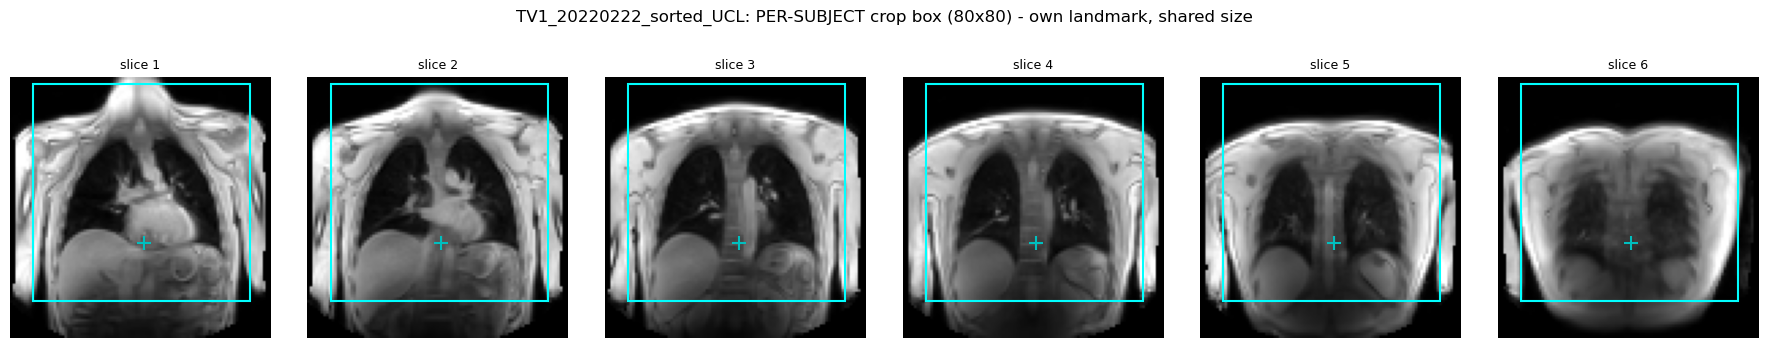

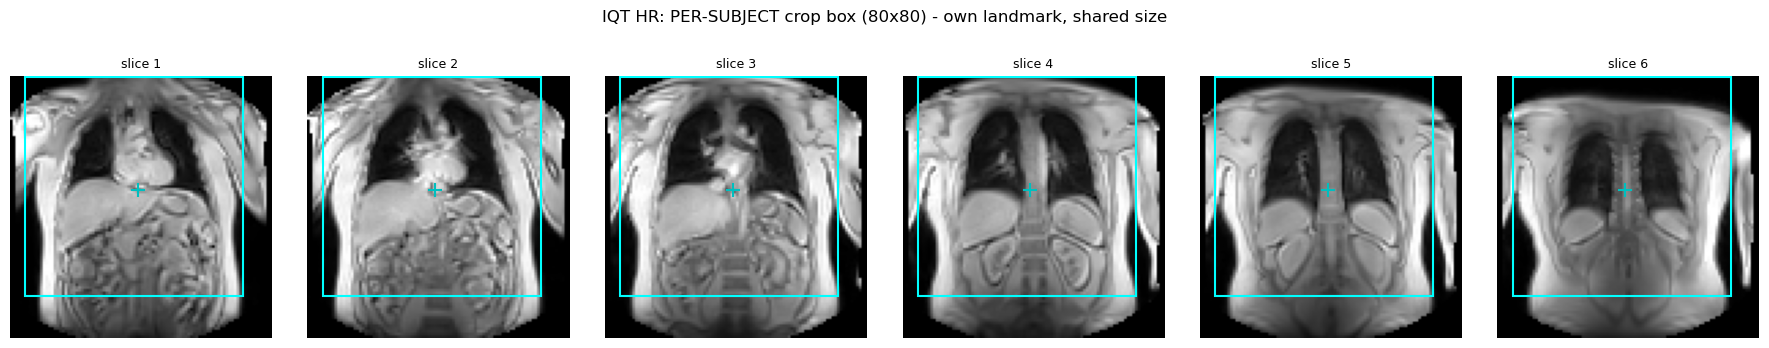

In [25]:
## Per-subject crop truncation scan (B4) - gated on each dataset's own
## MEASUREMENT_EXCLUDE-clean ("measured") slices only; excluded slices are reported
## separately and never gate the assert below, since they are already known-unreliable
## (see cell above's known-limitations comments for TV6/TV7's expected large excluded-
## slice truncation).
##
## The gate below is a TOLERANCE, not zero-truncation: CROP_SIZE and each dataset's
## anchor were derived from the 99th percentile of that dataset's own extent (see the
## CROP_SIZE cell), not the max - a small tail beyond the 99th percentile truncating
## occasionally is the expected, accepted cost of that choice, not a bug. A hard
## zero-tolerance assert can never coexist with a percentile-based (not max-based)
## derivation. The tolerance (rate < 0.5%, worst overflow < 4px per dataset) still fails
## loudly if truncation is worse than what the percentile choice was expected to cost.
RATE_TOLERANCE = 0.005
OVERFLOW_TOLERANCE_PX = 4.0

per_subject_truncation_report = {}
per_subject_truncation_stats = {}
for subject_dir in TV_SUBJECT_DIRS:
    name = subject_dir.name
    c = per_subject_crop[name]
    landmark = all_subject_results[name]["subject_landmark"]
    excluded = MEASUREMENT_EXCLUDE.get(name, set())
    extents = (c["up"], c["down"], c["left"], c["right"])
    result = check_truncation_for_subject(subject_dir, landmark, c["crop_size"],
                                           c["anchor_row"], c["anchor_col"], extents, excluded_slices=excluded)
    per_subject_truncation_report[name] = result
    measured, excl_trunc = result["measured"], result["excluded"]

    n_measured_slices = NUM_SLICES - len(excluded)
    n_total_measured = n_measured_slices * len(AIR_PHASE_DYNAMICS)
    rate = len(measured) / n_total_measured if n_total_measured else 0.0
    worst_overflow = max((o for _, _, o in measured), default=0.0)
    per_subject_truncation_stats[name] = {"rate": rate, "worst_overflow": worst_overflow}

    print(f"  {name}: crop {c['crop_size']}x{c['crop_size']} (measured slices) -> "
          f"{len(measured)}/{n_total_measured} truncated ({rate:.2%}), worst overflow {worst_overflow:.1f}px")
    if excluded:
        excl_status = "no truncation" if not excl_trunc else f"{len(excl_trunc)} pairs, slices {sorted({s for s, _, _ in excl_trunc})}"
        print(f"      (MEASUREMENT_EXCLUDE slices {sorted(excluded)}, non-gating: {excl_status})")

c_iqt = per_subject_crop["IQT_HR"]
excluded_iqt = MEASUREMENT_EXCLUDE.get("IQT_HR", set())
iqt_extents = (c_iqt["up"], c_iqt["down"], c_iqt["left"], c_iqt["right"])
iqt_result = check_truncation_for_iqt(iqt_results["subject_landmark"], c_iqt["crop_size"],
                                       c_iqt["anchor_row"], c_iqt["anchor_col"], iqt_extents, excluded_slices=excluded_iqt)
per_subject_truncation_report["IQT_HR"] = iqt_result
iqt_measured, iqt_excl_trunc = iqt_result["measured"], iqt_result["excluded"]

iqt_n_measured_slices = NUM_SLICES - len(excluded_iqt)
iqt_n_total_measured = iqt_n_measured_slices * len(IQT_DYNAMICS)
iqt_rate = len(iqt_measured) / iqt_n_total_measured if iqt_n_total_measured else 0.0
iqt_worst_overflow = max((o for _, _, o in iqt_measured), default=0.0)
per_subject_truncation_stats["IQT_HR"] = {"rate": iqt_rate, "worst_overflow": iqt_worst_overflow}

print(f"  IQT_HR: crop {c_iqt['crop_size']}x{c_iqt['crop_size']} (measured slices) -> "
      f"{len(iqt_measured)}/{iqt_n_total_measured} truncated ({iqt_rate:.2%}), worst overflow {iqt_worst_overflow:.1f}px")
if excluded_iqt:
    excl_status = "no truncation" if not iqt_excl_trunc else f"{len(iqt_excl_trunc)} pairs"
    print(f"      (MEASUREMENT_EXCLUDE slices {sorted(excluded_iqt)}, non-gating: {excl_status})")

print(f"\nMeasured-slice truncation tolerance: rate < {RATE_TOLERANCE:.1%}, "
      f"worst overflow < {OVERFLOW_TOLERANCE_PX:.1f}px per dataset:")
for name, stats in per_subject_truncation_stats.items():
    within = stats["rate"] < RATE_TOLERANCE and stats["worst_overflow"] < OVERFLOW_TOLERANCE_PX
    print(f"  {name}: rate={stats['rate']:.2%} worst_overflow={stats['worst_overflow']:.1f}px -> "
          f"{'within tolerance' if within else 'EXCEEDS TOLERANCE'}")

assert all(s["rate"] < RATE_TOLERANCE and s["worst_overflow"] < OVERFLOW_TOLERANCE_PX
           for s in per_subject_truncation_stats.values()), (
    f"Per-subject crop exceeds the measured-slice truncation tolerance "
    f"(rate<{RATE_TOLERANCE:.1%}, overflow<{OVERFLOW_TOLERANCE_PX:.1f}px) somewhere - "
    f"investigate before trusting per_subject_crop"
)
print("\nConfirmed: every dataset's measured (non-excluded) truncation is within tolerance.")


def plot_per_subject_crop_box_overlay(result: dict, title_prefix: str, crop_params: dict) -> None:
    """Crop box overlay for a PER-SUBJECT crop (per_subject_crop): single CROP_SIZE,
    per-dataset anchor."""
    fig, axes = plt.subplots(1, NUM_SLICES, figsize=(3 * NUM_SLICES, 3.5))
    landmark = result["subject_landmark"]
    crop_size = crop_params["crop_size"]
    anchor_row, anchor_col = crop_params["anchor_row"], crop_params["anchor_col"]
    for slice_num in range(1, NUM_SLICES + 1):
        ax = axes[slice_num - 1]
        img = result["max_te1_images"][slice_num]
        ax.imshow(normalise_for_display(img), cmap="gray", vmin=0, vmax=1)
        if landmark is None:
            ax.set_title(f"slice {slice_num}: NO LANDMARK", fontsize=9)
            ax.axis("off")
            continue
        h, w = img.shape[:2]
        extents = (crop_params["up"], crop_params["down"], crop_params["left"], crop_params["right"])
        y0, x0 = _crop_origin(landmark, crop_size, anchor_row, anchor_col, h, w, extents)
        rect = mpatches.Rectangle((x0, y0), crop_size, crop_size, linewidth=1.5, edgecolor="cyan", facecolor="none")
        ax.add_patch(rect)
        ax.plot(landmark["mid_x"], landmark["diaphragm_y"], "c+", ms=10, mew=1.5)
        ax.set_title(f"slice {slice_num}", fontsize=9)
        ax.axis("off")
    fig.suptitle(f"{title_prefix}: PER-SUBJECT crop box ({crop_size}x{crop_size}) - own landmark, shared size", fontsize=12)
    plt.tight_layout(rect=[0, 0, 1, 0.92])
    plt.show()


# Rendered for TV1 + IQT HR only (walkthrough) - per_subject_crop/truncation numbers above
# already cover all 9 datasets; only the image grid is restricted, per the notebook's
# figure-trimming convention.
plot_per_subject_crop_box_overlay(all_subject_results[tv1_dir.name], tv1_dir.name, per_subject_crop[tv1_dir.name])
plot_per_subject_crop_box_overlay(iqt_results, "IQT HR", per_subject_crop["IQT_HR"])


## Step 6 -- TV1 vs. IQT HR: does per-dataset-centred framing make lung sizes comparable?

This figure and its measurement table test a specific claim: that framing each dataset
around its OWN landmark makes TV and IQT HR lung sizes visually and quantitatively
comparable. TV1 stands in as the representative example (this notebook's established
baseline-walkthrough subject) - the measurement table is the actual evidence, not the
picture alone.

Every panel is now the actual `CROP_SIZE x CROP_SIZE` crop each dataset trains on
(`extract_standardised_frame`, own landmark, own anchor) - not the full native 96x96
frame. Pixel scale remains trivially identical between the TV and IQT columns (both are
the same `CROP_SIZE`, at native pixel spacing, no resizing), so the original scale
argument still holds; the difference is that these panels are now what the model
actually sees, not an intermediate diagnostic view of it.

Layout: rows = slices 1-6, columns = [TV1 max | IQT max | TV1 min | IQT min], TE1 only -
no TE2, no 4-column TE1/TE2 grid (that was a different figure with a different purpose,
dropped here). Each panel's title gives the dynamic number and the segmented lung area in
pixels, measured on the CROPPED mask (`extract_standardised_frame` applied to
`max_masks`/`min_masks`, not the native masks). The table below gives, per slice: TV1 and
IQT area at max- and min-expansion, and their ratio (TV1/IQT) at each - a ratio near 1.0
supports comparable sizing, one outside roughly 0.7-1.4 does not, and is reported as a
negative finding, not smoothed over, along with a note whenever either mask is a
merge-split reconstruction or a segmentation failure (the area comparison is only as
trustworthy as the two masks feeding it). TV1 and IQT HR are different participants -
this remains a standardised-view comparison, not a registered pair.


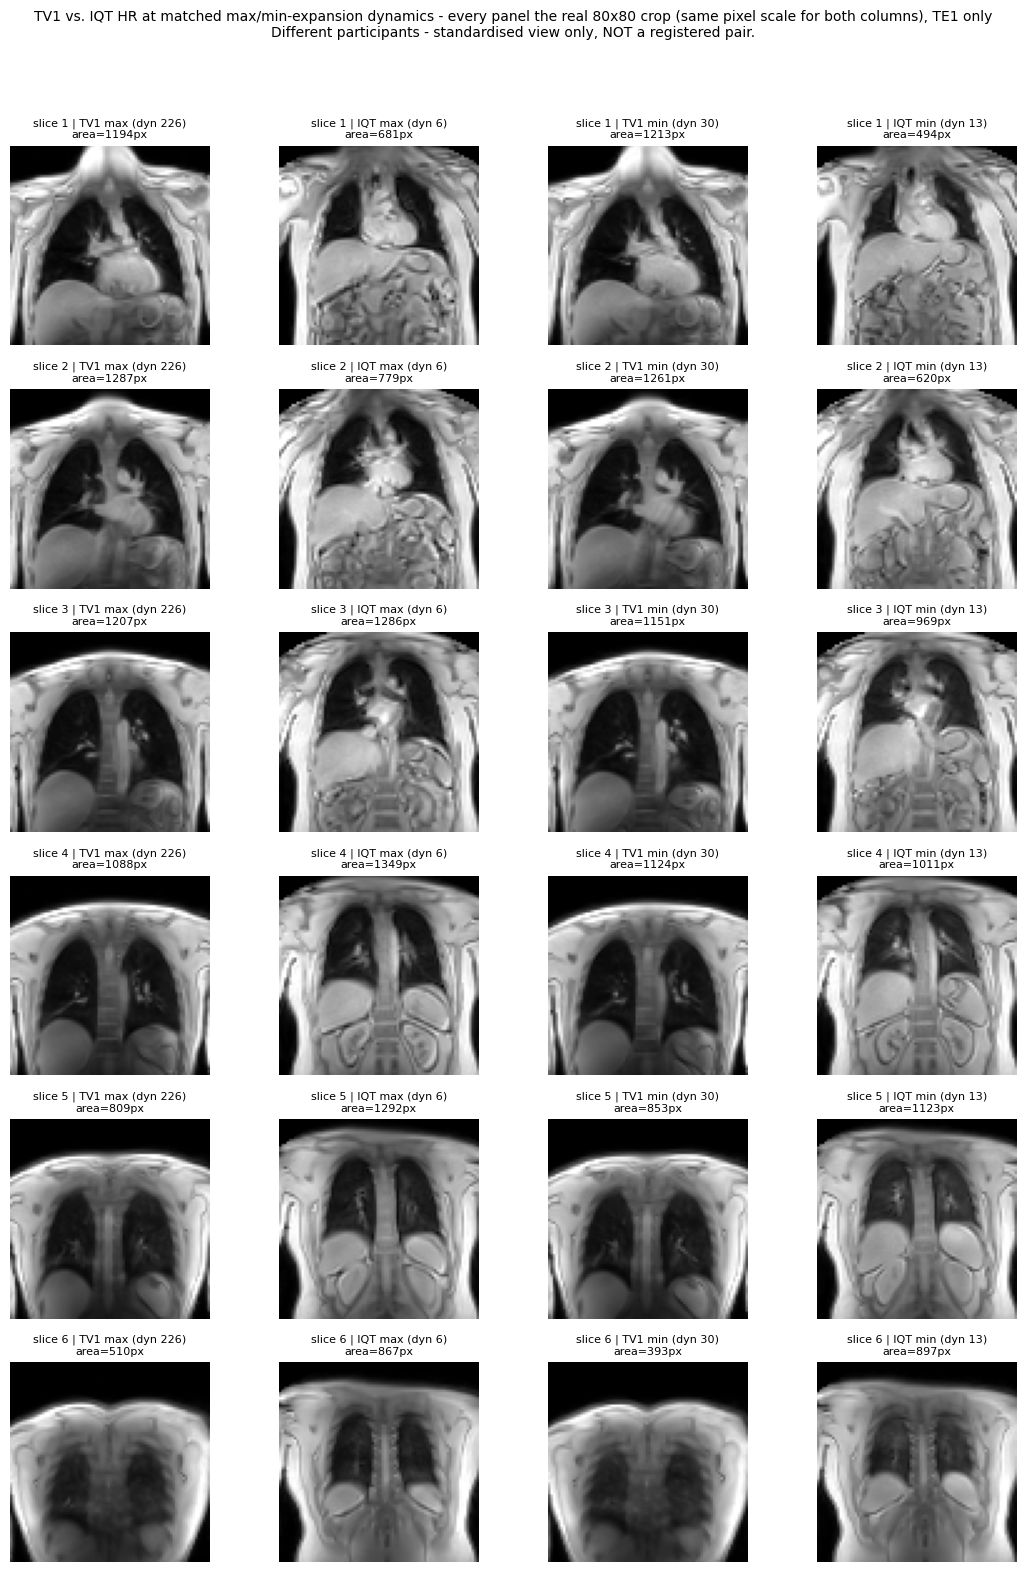


TV1 vs. IQT HR lung-area comparison (80x80 crop, TE1):


,slice,tv1_max_area,iqt_max_area,max_ratio_tv_over_iqt,max_ratio_flag,max_notes,tv1_min_area,iqt_min_area,min_ratio_tv_over_iqt,min_ratio_flag,min_notes
0,1,1194,681,1.75,True,,1213,494,2.46,True,
1,2,1287,779,1.65,True,,1261,620,2.03,True,
2,3,1207,1286,0.94,False,IQT: merge-split,1151,969,1.19,False,TV1: merge-split; IQT: merge-split
3,4,1088,1349,0.81,False,TV1: merge-split; IQT: merge-split,1124,1011,1.11,False,TV1: merge-split; IQT: merge-split
4,5,809,1292,0.63,True,TV1: merge-split; IQT: merge-split,853,1123,0.76,False,TV1: merge-split; IQT: merge-split
5,6,510,867,0.59,True,TV1: merge-split; IQT: merge-split,393,897,0.44,True,IQT: merge-split



Max-expansion TV1/IQT area ratio across 6/6 slices: mean=1.06, range=[0.59, 1.75]
Min-expansion TV1/IQT area ratio across 6/6 slices: mean=1.33, range=[0.44, 2.46]

NEGATIVE FINDING: 4/6 slices show a ratio outside the ~0.7-1.4 'comparable size' band at max- and/or min-expansion (see max_ratio_flag/min_ratio_flag above) - framing each dataset around its own landmark does NOT reliably make TV1 and IQT HR lung areas comparable at every slice. This is a real limit of the framing approach, not smoothed over.


In [26]:
def _reason_note(name, reason):
    if reason == "ok":
        return None
    if reason == "ok (merge-split)":
        return f"{name}: merge-split"
    return f"{name}: FAILED ({reason})"


def _combined_note(tv_reason, iqt_reason):
    notes = [n for n in [_reason_note("TV1", tv_reason), _reason_note("IQT", iqt_reason)] if n]
    return "; ".join(notes) if notes else ""


RATIO_OK_BAND = (0.7, 1.4)

_tv1_crop = per_subject_crop[tv1_dir.name]
_iqt_crop = per_subject_crop["IQT_HR"]
_tv1_landmark = tv1_results["subject_landmark"]
_iqt_landmark = iqt_results["subject_landmark"]
_tv1_extents = (_tv1_crop["up"], _tv1_crop["down"], _tv1_crop["left"], _tv1_crop["right"])
_iqt_extents = (_iqt_crop["up"], _iqt_crop["down"], _iqt_crop["left"], _iqt_crop["right"])


def _cropped_area(mask: np.ndarray, landmark: dict, crop: dict) -> int:
    extents = (crop["up"], crop["down"], crop["left"], crop["right"])
    cropped = extract_standardised_frame(mask.astype(np.float32), landmark, crop["crop_size"],
                                          crop["anchor_row"], crop["anchor_col"], extents) > 0.5
    return lung_mask_area(cropped)


comparison_rows = []
for slice_num in range(1, NUM_SLICES + 1):
    tv1_max_area = _cropped_area(tv1_results["max_masks"][slice_num], _tv1_landmark, _tv1_crop)
    iqt_max_area = _cropped_area(iqt_results["max_masks"][slice_num], _iqt_landmark, _iqt_crop)
    tv1_min_area = _cropped_area(tv1_results["min_masks"][slice_num], _tv1_landmark, _tv1_crop)
    iqt_min_area = _cropped_area(iqt_results["min_masks"][slice_num], _iqt_landmark, _iqt_crop)

    max_ratio = tv1_max_area / iqt_max_area if iqt_max_area > 0 else np.nan
    min_ratio = tv1_min_area / iqt_min_area if iqt_min_area > 0 else np.nan
    max_ratio_flag = np.isnan(max_ratio) or not (RATIO_OK_BAND[0] <= max_ratio <= RATIO_OK_BAND[1])
    min_ratio_flag = np.isnan(min_ratio) or not (RATIO_OK_BAND[0] <= min_ratio <= RATIO_OK_BAND[1])

    comparison_rows.append({
        "slice": slice_num,
        "tv1_max_area": tv1_max_area, "iqt_max_area": iqt_max_area,
        "max_ratio_tv_over_iqt": round(max_ratio, 2) if not np.isnan(max_ratio) else np.nan,
        "max_ratio_flag": max_ratio_flag,
        "max_notes": _combined_note(tv1_results["max_seg_reasons"][slice_num], iqt_results["max_seg_reasons"][slice_num]),
        "tv1_min_area": tv1_min_area, "iqt_min_area": iqt_min_area,
        "min_ratio_tv_over_iqt": round(min_ratio, 2) if not np.isnan(min_ratio) else np.nan,
        "min_ratio_flag": min_ratio_flag,
        "min_notes": _combined_note(tv1_results["min_seg_reasons"][slice_num], iqt_results["min_seg_reasons"][slice_num]),
    })

comparison_df = pd.DataFrame(comparison_rows)


def plot_tv1_iqt_comparability(tv1_results, iqt_results) -> None:
    """6 rows (slice) x 4 columns [TV1 max | IQT max | TV1 min | IQT min], TE1 only. Every
    panel is the real CROP_SIZE x CROP_SIZE crop (own landmark, own anchor) - identical
    dimensions and pixel scale for every panel, and now what the model actually trains
    on rather than a diagnostic view of the native frame. The measurement table (below)
    is the actual evidence for size comparability, not this picture."""
    fig, axes = plt.subplots(NUM_SLICES, 4, figsize=(11, 16))
    tv1_max_dyn, tv1_min_dyn = tv1_results["max_dynamic"], tv1_results["min_dynamic"]
    iqt_max_dyn, iqt_min_dyn = iqt_results["max_dynamic"], iqt_results["min_dynamic"]

    for slice_num in range(1, NUM_SLICES + 1):
        tv1_max_img = extract_standardised_frame(tv1_results["max_te1_images"][slice_num], _tv1_landmark,
                                                   _tv1_crop["crop_size"], _tv1_crop["anchor_row"], _tv1_crop["anchor_col"], _tv1_extents)
        iqt_max_img = extract_standardised_frame(iqt_results["max_te1_images"][slice_num], _iqt_landmark,
                                                   _iqt_crop["crop_size"], _iqt_crop["anchor_row"], _iqt_crop["anchor_col"], _iqt_extents)
        tv1_min_img = extract_standardised_frame(tv1_results["min_te1_images"][slice_num], _tv1_landmark,
                                                   _tv1_crop["crop_size"], _tv1_crop["anchor_row"], _tv1_crop["anchor_col"], _tv1_extents)
        iqt_min_img = extract_standardised_frame(iqt_results["min_te1_images"][slice_num], _iqt_landmark,
                                                   _iqt_crop["crop_size"], _iqt_crop["anchor_row"], _iqt_crop["anchor_col"], _iqt_extents)
        panels = [
            (tv1_max_img, _cropped_area(tv1_results["max_masks"][slice_num], _tv1_landmark, _tv1_crop), f"TV1 max (dyn {tv1_max_dyn})"),
            (iqt_max_img, _cropped_area(iqt_results["max_masks"][slice_num], _iqt_landmark, _iqt_crop), f"IQT max (dyn {iqt_max_dyn})"),
            (tv1_min_img, _cropped_area(tv1_results["min_masks"][slice_num], _tv1_landmark, _tv1_crop), f"TV1 min (dyn {tv1_min_dyn})"),
            (iqt_min_img, _cropped_area(iqt_results["min_masks"][slice_num], _iqt_landmark, _iqt_crop), f"IQT min (dyn {iqt_min_dyn})"),
        ]
        for col, (img, area, col_title) in enumerate(panels):
            ax = axes[slice_num - 1, col]
            ax.imshow(normalise_for_display(img), cmap="gray", vmin=0, vmax=1)
            ax.set_title(f"slice {slice_num} | {col_title}\narea={area}px", fontsize=8)
            ax.axis("off")

    fig.suptitle(
        f"TV1 vs. IQT HR at matched max/min-expansion dynamics - every panel the real "
        f"{CROP_SIZE}x{CROP_SIZE} crop (same pixel scale for both columns), TE1 "
        f"only\nDifferent participants - standardised view only, NOT a registered pair.",
        fontsize=10,
    )
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


plot_tv1_iqt_comparability(tv1_results, iqt_results)

print(f"\nTV1 vs. IQT HR lung-area comparison ({CROP_SIZE}x{CROP_SIZE} crop, TE1):")
display(comparison_df)

# The actual answer to "are they comparably sized" - the mean and range of the ratio
# across all 6 slices, not one good-looking picture.
_valid_max_ratios = [r["max_ratio_tv_over_iqt"] for r in comparison_rows if not np.isnan(r["max_ratio_tv_over_iqt"])]
_valid_min_ratios = [r["min_ratio_tv_over_iqt"] for r in comparison_rows if not np.isnan(r["min_ratio_tv_over_iqt"])]
_n_flagged = sum(1 for r in comparison_rows if r["max_ratio_flag"] or r["min_ratio_flag"])

print(f"\nMax-expansion TV1/IQT area ratio across {len(_valid_max_ratios)}/{NUM_SLICES} slices: "
      f"mean={np.mean(_valid_max_ratios):.2f}, range=[{min(_valid_max_ratios):.2f}, {max(_valid_max_ratios):.2f}]")
print(f"Min-expansion TV1/IQT area ratio across {len(_valid_min_ratios)}/{NUM_SLICES} slices: "
      f"mean={np.mean(_valid_min_ratios):.2f}, range=[{min(_valid_min_ratios):.2f}, {max(_valid_min_ratios):.2f}]")

if _n_flagged:
    print(f"\nNEGATIVE FINDING: {_n_flagged}/{NUM_SLICES} slices show a ratio outside the "
          f"~{RATIO_OK_BAND[0]}-{RATIO_OK_BAND[1]} 'comparable size' band at max- and/or min-expansion "
          f"(see max_ratio_flag/min_ratio_flag above) - framing each dataset around its own landmark does "
          f"NOT reliably make TV1 and IQT HR lung areas comparable at every slice. This is a real limit "
          f"of the framing approach, not smoothed over.")
else:
    print(f"\nAll {NUM_SLICES}/{NUM_SLICES} slices fall within the "
          f"~{RATIO_OK_BAND[0]}-{RATIO_OK_BAND[1]} band at both max- and min-expansion - supports the "
          f"claim that per-dataset-centred framing makes lung sizes comparable.")


## Step 7 -- IQT HR vs. IQT LR phase pairing

IQT HR and IQT LR are two different acquisitions of the same anatomy, each with its own
respiratory-phase timeline (IQT LR confirmed live above: 6 slices, 2 echoes, 30 dynamics -
same counts as HR - but a different native resolution, 64x64 vs. HR's 96x96). Dynamics are
NOT assumed synchronized between the two series - LR dynamic N does not necessarily
correspond to HR dynamic N.

Pairing works by computing each series' own aggregate lung-area curve (the same method
used throughout this notebook), rescaling each curve to a `[0, 1]` "respiratory position"
anchored to that curve's own already-selected maximum/minimum-expansion dynamic, then
matching each LR dynamic to the HR dynamic with the closest rescaled position. LR frames
are upscaled to 96x96 (cubic spline) before segmentation only, reusing this notebook's
already-calibrated segmentation/temporal-consistency constants rather than deriving and
separately validating a second set at 64x64 - `load_iqt_lr_frame` itself still returns
native 64x64 pixels, for any future actual LR training-data use.

IQT LR: max expansion @ dynamic 8, min expansion @ dynamic 27
Phase bins assigned: HR 30/30 dynamics, LR 30/30 dynamics (n_bins=10).
LR -> nearest-same-phase-and-direction HR dynamic pairing (7/30 used the no-exact-match fallback):
  LR dyn 1 (bin 1, exhale) -> HR dyn 29
  LR dyn 2 (bin 1, inhale) -> HR dyn 24
  LR dyn 3 (bin 5, inhale) -> HR dyn 24 [FALLBACK: no HR dynamic shares this bin+direction]
  LR dyn 4 (bin 1, exhale) -> HR dyn 12
  LR dyn 5 (bin 5, exhale) -> HR dyn 20
  LR dyn 6 (bin 1, inhale) -> HR dyn 1
  LR dyn 7 (bin 5, inhale) -> HR dyn 24 [FALLBACK: no HR dynamic shares this bin+direction]
  LR dyn 8 (bin 1, exhale) -> HR dyn 12
  LR dyn 9 (bin 4, exhale) -> HR dyn 19
  LR dyn 10 (bin 7, exhale) -> HR dyn 24 [FALLBACK: no HR dynamic shares this bin+direction]
  LR dyn 11 (bin 1, inhale) -> HR dyn 24
  LR dyn 12 (bin 1, exhale) -> HR dyn 12
  LR dyn 13 (bin 4, exhale) -> HR dyn 19
  LR dyn 14 (bin 7, exhale) -> HR dyn 1 [FALLBACK: no HR dynamic shares this bin+directio

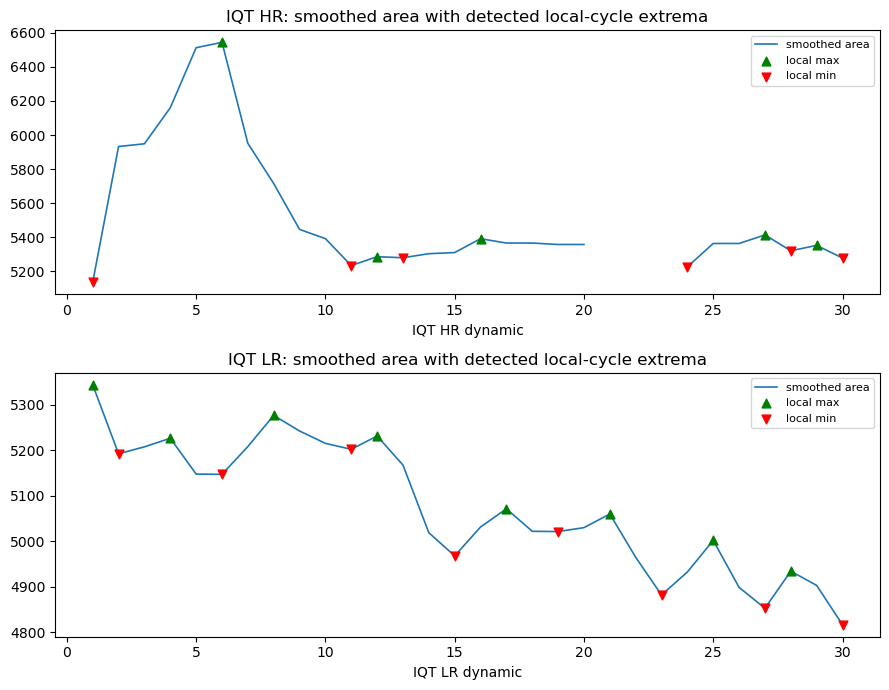

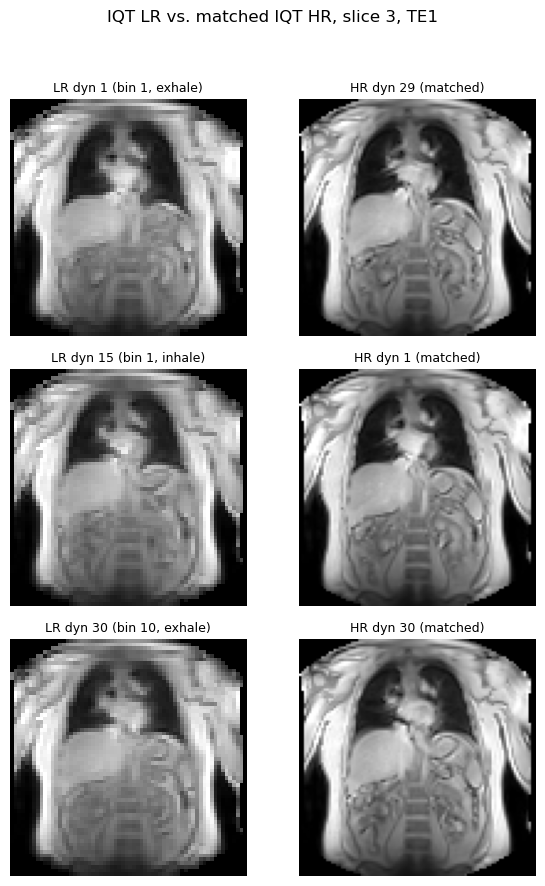


Per-pair mask-overlap (Dice) report, 30 pairs - distribution only, not gated:
count    30.000000
mean      0.889097
std       0.033407
min       0.832355
25%       0.852754
50%       0.897842
75%       0.916541
max       0.934407
Name: mean_dice, dtype: float64


,lr_dynamic,hr_dynamic,phase_bin,direction,fallback,n_slices_scored,mean_dice
0,1,29,1,exhale,False,6,0.914346
1,2,24,1,inhale,False,5,0.850304
2,3,24,5,inhale,True,5,0.902611
3,4,12,1,exhale,False,6,0.853888
4,5,20,5,exhale,False,5,0.934407
5,6,1,1,inhale,False,6,0.915797
6,7,24,5,inhale,True,5,0.893072
7,8,12,1,exhale,False,6,0.852376
8,9,19,4,exhale,False,5,0.904975
9,10,24,7,exhale,True,5,0.845845


In [27]:
## IQT LR aggregate curve, phase-bin pairing, and HR/LR mask-overlap (Dice) report
from skimage.transform import resize


def get_lr_te1_frame_for_segmentation(slice_num: int, dyn: int) -> np.ndarray:
    """LR TE1 frame, upscaled to IMG_SIZE x IMG_SIZE (cubic) before segmentation ONLY -
    SEGMENTATION-ONLY, never reaches training data. load_iqt_lr_frame itself still
    returns native 64x64 pixels for any future actual LR training-data use. This is one
    of only two permitted resizes on the data path (the other is the degradation model
    below) - the 'no interpolation' rule otherwise governs the crop itself
    (extract_standardised_frame, integer-offset only)."""
    frame = load_iqt_lr_frame(slice_num=slice_num, echo_num=1, dynamic_num=dyn)
    if frame.shape != (IMG_SIZE, IMG_SIZE):
        frame = resize(frame, (IMG_SIZE, IMG_SIZE), order=3, mode="edge",
                        anti_aliasing=False, preserve_range=True)
    return frame


lr_curve = compute_subject_aggregate_curve(get_lr_te1_frame_for_segmentation, IQT_LR_DYNAMICS)
print(f"IQT LR: max expansion @ dynamic {lr_curve['max_dynamic']}, min expansion @ dynamic {lr_curve['min_dynamic']}")


def dice_coefficient(mask_a: np.ndarray, mask_b: np.ndarray) -> float:
    a, b = mask_a.astype(bool), mask_b.astype(bool)
    denom = a.sum() + b.sum()
    return (2.0 * np.logical_and(a, b).sum() / denom) if denom > 0 else np.nan


PHASE_BINS = 10


def find_local_extrema(dynamics: list[int], smoothed: np.ndarray) -> list[tuple[int, str]]:
    """Indices (into `dynamics`) of local minima/maxima of `smoothed`, detected
    independently within each contiguous dynamic run - reuses smooth_area_curve's own
    run-splitting (a break wherever dynamics[i] != dynamics[i-1]+1), so extrema are
    never detected across the excluded oxygen-phase gap. A run's own first/last valid
    reading is included as a boundary extremum (relative to its one interior neighbour),
    so every dynamic in the run falls between two bounding extrema. NaN gaps WITHIN an
    otherwise-contiguous run (an unsegmented dynamic) are skipped over - the two
    straddling valid dynamics are treated as adjacent for extremum purposes, a known
    simplification consistent with how this notebook already combines valid readings
    elsewhere. Returns [(index, 'min'|'max'), ...] sorted by index."""
    dynamics_arr = np.asarray(dynamics)
    run_breaks = np.where(np.diff(dynamics_arr) != 1)[0] + 1
    runs = np.split(np.arange(len(dynamics_arr)), run_breaks) if len(dynamics_arr) > 1 else [np.arange(len(dynamics_arr))]
    extrema = []
    for run in runs:
        valid_mask = ~np.isnan(smoothed[run])
        idxs = run[valid_mask]
        if len(idxs) < 2:
            continue
        v = smoothed[idxs]
        local_idxs = [int(idxs[0])]
        kinds = ["max" if v[0] >= v[1] else "min"]
        for k in range(1, len(idxs) - 1):
            if v[k] > v[k - 1] and v[k] > v[k + 1]:
                local_idxs.append(int(idxs[k])); kinds.append("max")
            elif v[k] < v[k - 1] and v[k] < v[k + 1]:
                local_idxs.append(int(idxs[k])); kinds.append("min")
        local_idxs.append(int(idxs[-1]))
        kinds.append("max" if v[-1] >= v[-2] else "min")
        extrema.extend(zip(local_idxs, kinds))
    return sorted(extrema, key=lambda x: x[0])


def assign_phase_bins(dynamics: list[int], smoothed: np.ndarray, n_bins: int = PHASE_BINS) -> dict:
    """Per-dynamic {'phase_bin': 1..n_bins, 'direction': 'inhale'|'exhale'} from this
    dynamic's fractional position within its OWN local half-cycle (between the two
    extrema bounding it), NOT a single global [0,1] rescaling anchored to one
    subject-level max/min - a deep and a shallow respiratory cycle reach the same
    normalised phase at different absolute areas, which a single global rescaling
    mislabels. 'inhale' = rising toward the next local max; 'exhale' = falling toward
    the next local min. A dynamic sitting exactly on a shared boundary between two
    half-cycles gets whichever half-cycle is processed last (an arbitrary but harmless
    tie at a single instant)."""
    extrema = find_local_extrema(dynamics, smoothed)
    result = {}
    for (i0, kind0), (i1, kind1) in zip(extrema[:-1], extrema[1:]):
        if kind0 == kind1 or i1 <= i0:
            continue  # no half-cycle to assign (plateau or degenerate span)
        direction = "inhale" if kind1 == "max" else "exhale"
        span = i1 - i0
        for i in range(i0, i1 + 1):
            frac = (i - i0) / span
            bin_idx = min(n_bins, max(1, int(np.ceil(frac * n_bins)) or 1))
            result[dynamics[i]] = {"phase_bin": bin_idx, "direction": direction}
    return result


hr_phase = assign_phase_bins(iqt_results["curve"]["dynamics"], iqt_results["curve"]["aggregate_smoothed"])
lr_phase = assign_phase_bins(lr_curve["dynamics"], lr_curve["aggregate_smoothed"])
print(f"Phase bins assigned: HR {len(hr_phase)}/{len(iqt_results['curve']['dynamics'])} dynamics, "
      f"LR {len(lr_phase)}/{len(lr_curve['dynamics'])} dynamics (n_bins={PHASE_BINS}).")


def pair_lr_to_hr_by_phase(lr_curve: dict, lr_phase: dict, hr_curve: dict, hr_phase: dict) -> dict:
    """Pair each LR dynamic to an HR dynamic sharing the same (phase_bin, direction) -
    NOT a single global rescaled-position match, since breathing amplitude varies
    between cycles (a deep and a shallow cycle reach the same phase at different areas,
    and an inhaling frame is not the same respiratory phase as an exhaling frame at the
    same lung area). Among HR candidates sharing the (bin, direction) key, ties are
    broken by nearest smoothed area - same-phase candidates are phase-equivalent by
    construction, so area is the next-best positional signal. Falls back to
    nearest-by-area across ALL valid HR dynamics, flagged explicitly via 'fallback', if
    no HR dynamic shares that LR dynamic's (bin, direction) at all."""
    hr_dynamics = hr_curve["dynamics"]
    hr_smoothed = hr_curve["aggregate_smoothed"]
    hr_by_key: dict[tuple, list[int]] = {}
    for i, dyn in enumerate(hr_dynamics):
        info = hr_phase.get(dyn)
        if info is None or np.isnan(hr_smoothed[i]):
            continue
        hr_by_key.setdefault((info["phase_bin"], info["direction"]), []).append(i)
    all_valid_hr = [i for i in range(len(hr_dynamics)) if not np.isnan(hr_smoothed[i])]

    lr_dynamics = lr_curve["dynamics"]
    lr_smoothed = lr_curve["aggregate_smoothed"]
    pairs = {}
    for i, lr_dyn in enumerate(lr_dynamics):
        info = lr_phase.get(lr_dyn)
        if info is None or np.isnan(lr_smoothed[i]):
            pairs[lr_dyn] = {"hr_dynamic": None, "fallback": False, "phase_bin": None, "direction": None}
            continue
        key = (info["phase_bin"], info["direction"])
        candidates = hr_by_key.get(key, [])
        fallback = False
        if not candidates:
            candidates = all_valid_hr
            fallback = True
        if not candidates:
            pairs[lr_dyn] = {"hr_dynamic": None, "fallback": True, "phase_bin": info["phase_bin"], "direction": info["direction"]}
            continue
        lr_area = lr_smoothed[i]
        best_j = min(candidates, key=lambda j: abs(hr_smoothed[j] - lr_area))
        pairs[lr_dyn] = {"hr_dynamic": int(hr_dynamics[best_j]), "fallback": fallback,
                          "phase_bin": info["phase_bin"], "direction": info["direction"]}
    return pairs


lr_pairing = pair_lr_to_hr_by_phase(lr_curve, lr_phase, iqt_results["curve"], hr_phase)
lr_to_hr_dynamic = {lr_dyn: info["hr_dynamic"] for lr_dyn, info in lr_pairing.items()}
n_fallback = sum(1 for info in lr_pairing.values() if info["fallback"])
print(f"LR -> nearest-same-phase-and-direction HR dynamic pairing ({n_fallback}/{len(lr_pairing)} "
      f"used the no-exact-match fallback):")
for lr_dyn, info in lr_pairing.items():
    fb_note = " [FALLBACK: no HR dynamic shares this bin+direction]" if info["fallback"] else ""
    print(f"  LR dyn {lr_dyn} (bin {info['phase_bin']}, {info['direction']}) -> HR dyn {info['hr_dynamic']}{fb_note}")

# QC (a): both curves' own smoothed area with detected local extrema marked - shows the
# local-cycle structure the phase-bin assignment is actually built on (replaces the old
# single-[0,1]-rescaling overlay, which no longer exists as a single global curve).
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 7), sharex=False)
for ax, curve, phase, label in [(ax1, iqt_results["curve"], hr_phase, "IQT HR"),
                                  (ax2, lr_curve, lr_phase, "IQT LR")]:
    ax.plot(curve["dynamics"], curve["aggregate_smoothed"], color="C0", lw=1.2, label="smoothed area")
    extrema = find_local_extrema(curve["dynamics"], curve["aggregate_smoothed"])
    max_x = [curve["dynamics"][i] for i, k in extrema if k == "max"]
    max_y = [curve["aggregate_smoothed"][i] for i, k in extrema if k == "max"]
    min_x = [curve["dynamics"][i] for i, k in extrema if k == "min"]
    min_y = [curve["aggregate_smoothed"][i] for i, k in extrema if k == "min"]
    ax.scatter(max_x, max_y, color="green", marker="^", s=40, zorder=3, label="local max")
    ax.scatter(min_x, min_y, color="red", marker="v", s=40, zorder=3, label="local min")
    ax.set_title(f"{label}: smoothed area with detected local-cycle extrema")
    ax.set_xlabel(f"{label} dynamic")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


# QC (b): representative side-by-side frame pairs, slice 3 (mid-chest), TE1
def representative_lr_dynamics(lr_curve, lr_pairing, n=3):
    valid = [d for d in lr_curve["dynamics"] if lr_pairing.get(d, {}).get("hr_dynamic") is not None]
    if len(valid) <= n:
        return valid
    idx = np.linspace(0, len(valid) - 1, n).round().astype(int)
    return [valid[i] for i in idx]


qc_slice = 3
qc_lr_dynamics = representative_lr_dynamics(lr_curve, lr_pairing, n=3)
fig, axes = plt.subplots(len(qc_lr_dynamics), 2, figsize=(6, 3 * len(qc_lr_dynamics)))
for row, lr_dyn in enumerate(qc_lr_dynamics):
    hr_dyn = lr_to_hr_dynamic[lr_dyn]
    info = lr_pairing[lr_dyn]
    lr_img = load_iqt_lr_frame(slice_num=qc_slice, echo_num=1, dynamic_num=lr_dyn)
    hr_img = load_iqt_hr_frame(slice_num=qc_slice, echo_num=1, dynamic_num=hr_dyn)
    axes[row, 0].imshow(normalise_for_display(lr_img), cmap="gray", vmin=0, vmax=1)
    axes[row, 0].set_title(f"LR dyn {lr_dyn} (bin {info['phase_bin']}, {info['direction']})", fontsize=9)
    axes[row, 1].imshow(normalise_for_display(hr_img), cmap="gray", vmin=0, vmax=1)
    axes[row, 1].set_title(f"HR dyn {hr_dyn} (matched)", fontsize=9)
    for ax in axes[row]:
        ax.axis("off")
fig.suptitle(f"IQT LR vs. matched IQT HR, slice {qc_slice}, TE1", fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# Mask-overlap (Dice) report per accepted pair - report-only, NOT gated. Diaphragm
# misalignment in a phase-mismatched pair is exactly the failure mode a low Dice score
# should surface here.
pairing_quality_rows = []
for lr_dyn, info in lr_pairing.items():
    hr_dyn = info["hr_dynamic"]
    if hr_dyn is None:
        continue
    dice_scores = []
    for slice_num in range(1, NUM_SLICES + 1):
        lr_img = get_lr_te1_frame_for_segmentation(slice_num, lr_dyn)
        hr_img = load_iqt_hr_frame(slice_num=slice_num, echo_num=1, dynamic_num=hr_dyn)
        lr_seg = segment_lungs_te1(lr_img)
        hr_seg = segment_lungs_te1(hr_img)
        if not (lr_seg["success"] and hr_seg["success"]):
            continue
        dice_scores.append(dice_coefficient(lr_seg["combined_mask"], hr_seg["combined_mask"]))
    pairing_quality_rows.append({
        "lr_dynamic": lr_dyn, "hr_dynamic": hr_dyn, "phase_bin": info["phase_bin"],
        "direction": info["direction"], "fallback": info["fallback"],
        "n_slices_scored": len(dice_scores),
        "mean_dice": float(np.mean(dice_scores)) if dice_scores else np.nan,
    })

pairing_quality_df = pd.DataFrame(pairing_quality_rows)
print(f"\nPer-pair mask-overlap (Dice) report, {len(pairing_quality_df)} pairs - distribution only, not gated:")
print(pairing_quality_df["mean_dice"].describe())
display(pairing_quality_df)


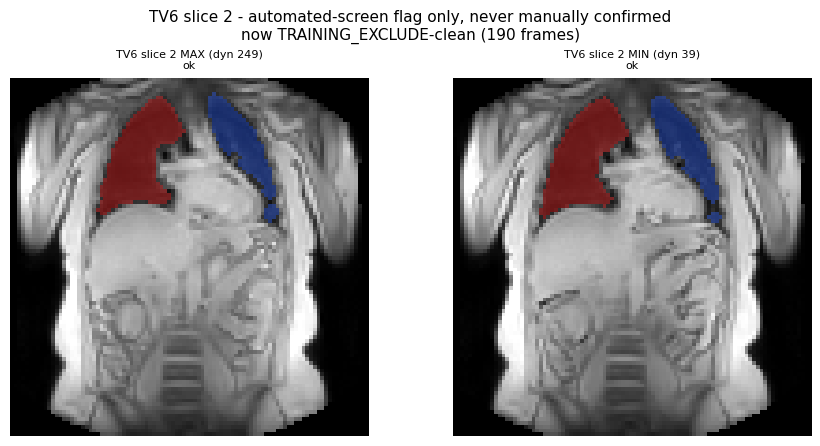

success: max=True (ok), min=True (ok)


In [28]:
## SLIDE FIGURE 1 -- TV6 slice 2, max + min expansion. Automated-screen-flagged, never
## manually confirmed, now TRAINING_EXCLUDE-clean (190 frames in the export).
_tv6_name = "TV6_20220307_sorted_UCL"
_tv6_res = all_subject_results[_tv6_name]
_tv6_max_dyn, _tv6_min_dyn = _tv6_res["max_dynamic"], _tv6_res["min_dynamic"]
_tv6_dir = next(d for d in TV_SUBJECT_DIRS if d.name == _tv6_name)
_tv6_volume = load_tv_volume(_tv6_dir)
_tv6_max_img = get_tv_frame(_tv6_volume, slice_num=2, echo_num=1, dynamic_num=_tv6_max_dyn)
_tv6_min_img = get_tv_frame(_tv6_volume, slice_num=2, echo_num=1, dynamic_num=_tv6_min_dyn)
_tv6_max_seg = segment_lungs_te1(_tv6_max_img)
_tv6_min_seg = segment_lungs_te1(_tv6_min_img)

fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))
plot_segmentation_overlay(_tv6_max_img, _tv6_max_seg, ax=axes[0], title=f"TV6 slice 2 MAX (dyn {_tv6_max_dyn})")
plot_segmentation_overlay(_tv6_min_img, _tv6_min_seg, ax=axes[1], title=f"TV6 slice 2 MIN (dyn {_tv6_min_dyn})")
fig.suptitle("TV6 slice 2 - automated-screen flag only, never manually confirmed\n"
             "now TRAINING_EXCLUDE-clean (190 frames)", fontsize=11)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "slide1_TV6_slice2_max_min.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"success: max={_tv6_max_seg['success']} ({_tv6_max_seg['reason']}), "
      f"min={_tv6_min_seg['success']} ({_tv6_min_seg['reason']})")


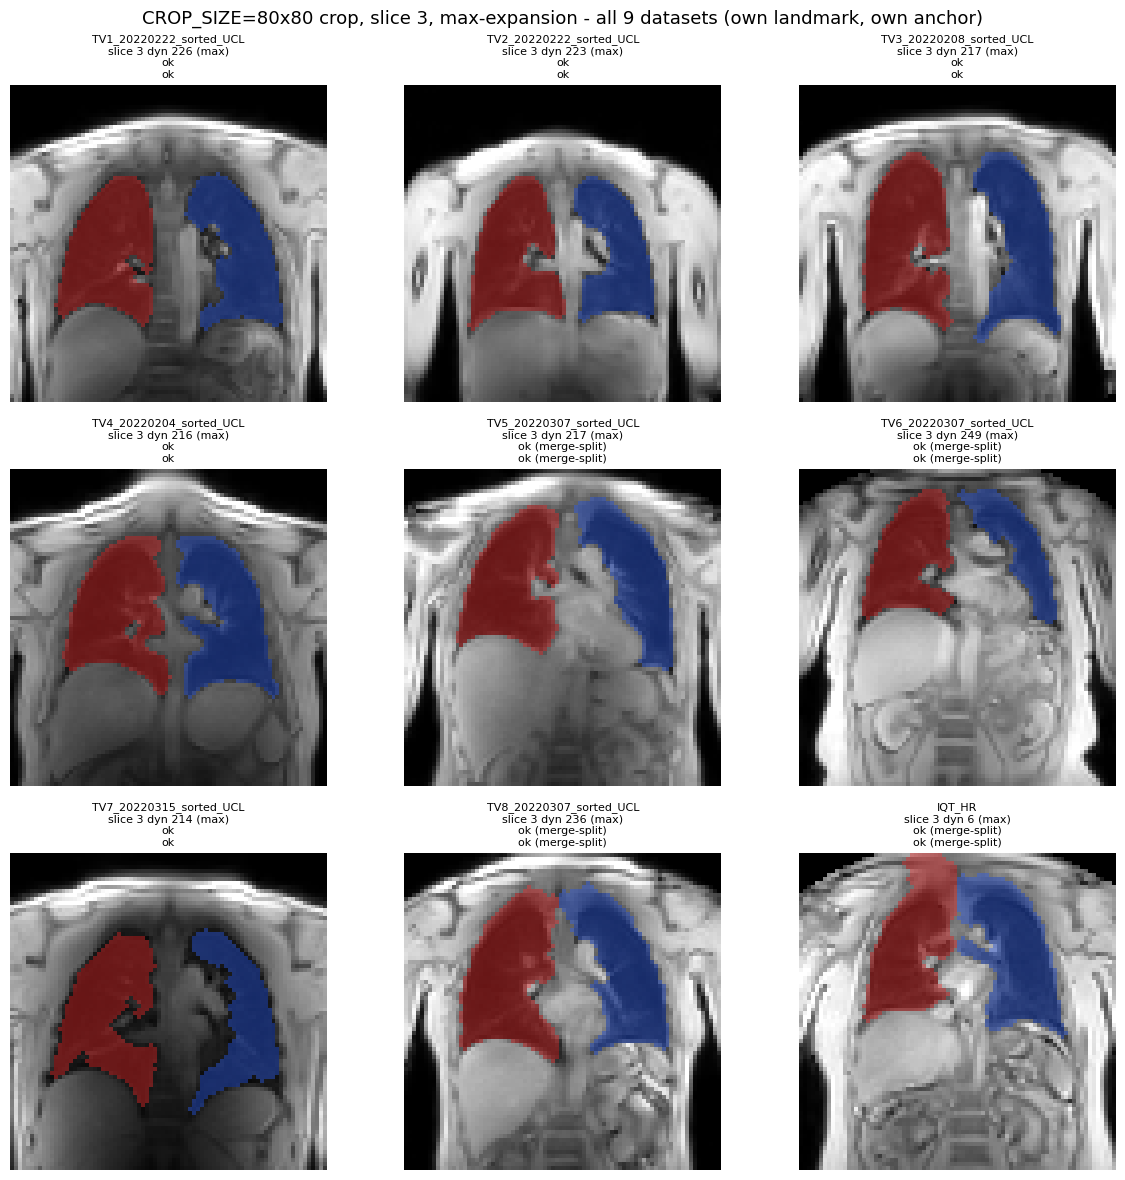

In [29]:
## SLIDE FIGURE 2 -- the payoff figure. CROP_SIZE crop + segmentation overlay, slice 3
## (clean for every dataset - not in any dataset's MEASUREMENT_EXCLUDE), max-expansion,
## all 9 datasets (8 TV + IQT HR), one panel each.
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
for ax, name in zip(axes.flat, per_subject_crop.keys()):
    crop = per_subject_crop[name]
    result = iqt_results if name == "IQT_HR" else all_subject_results[name]
    landmark = result["subject_landmark"]
    extents = (crop["up"], crop["down"], crop["left"], crop["right"])
    img = result["max_te1_images"][3]
    cropped_img = extract_standardised_frame(img, landmark, crop["crop_size"], crop["anchor_row"], crop["anchor_col"], extents)
    seg = segment_lungs_te1(cropped_img)
    dyn = result["max_dynamic"]
    status = seg["reason"] if seg["success"] else f"FAILED: {seg['reason']}"
    plot_segmentation_overlay(cropped_img, seg, ax=ax, title=f"{name}\nslice 3 dyn {dyn} (max)\n{status}")
fig.suptitle(f"CROP_SIZE={CROP_SIZE}x{CROP_SIZE} crop, slice 3, max-expansion - all 9 datasets "
             f"(own landmark, own anchor)", fontsize=13)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "slide2_crop_payoff_all9_slice3_max.png", dpi=150, bbox_inches="tight")
plt.show()


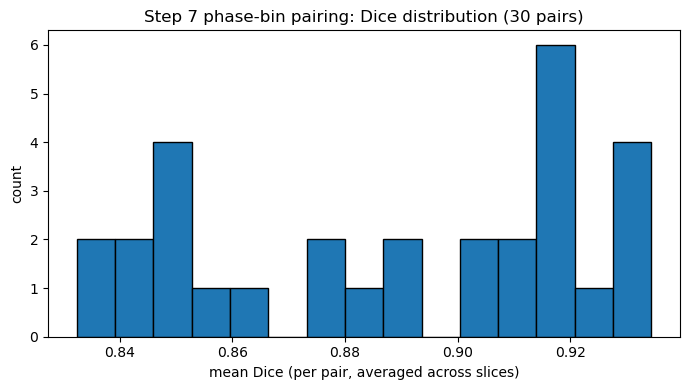

 lr_dynamic  hr_dynamic  phase_bin direction  fallback  n_slices_scored  mean_dice
          1          29          1    exhale     False                6   0.914346
          2          24          1    inhale     False                5   0.850304
          3          24          5    inhale      True                5   0.902611
          4          12          1    exhale     False                6   0.853888
          5          20          5    exhale     False                5   0.934407
          6           1          1    inhale     False                6   0.915797
          7          24          5    inhale      True                5   0.893072
          8          12          1    exhale     False                6   0.852376
          9          19          4    exhale     False                5   0.904975
         10          24          7    exhale      True                5   0.845845
         11          24          1    inhale     False                5   0.850852
    

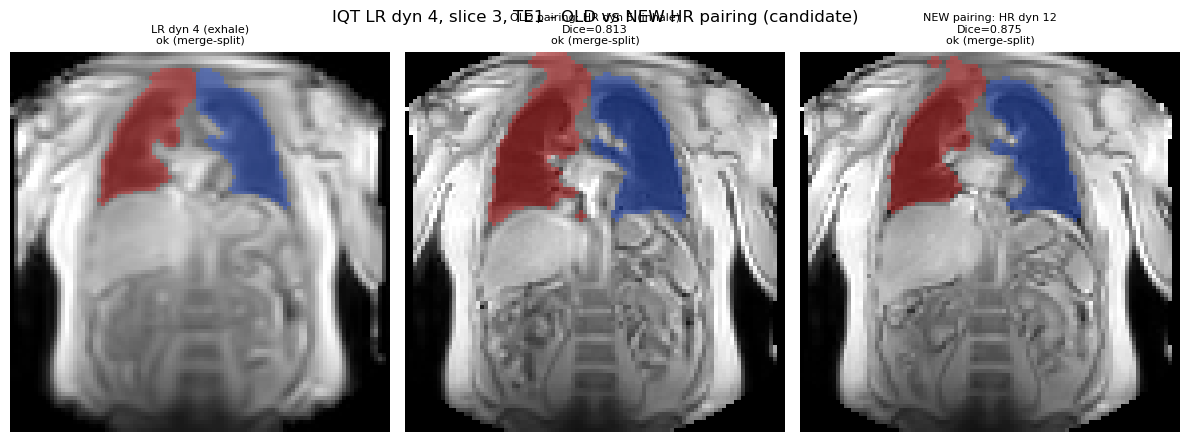

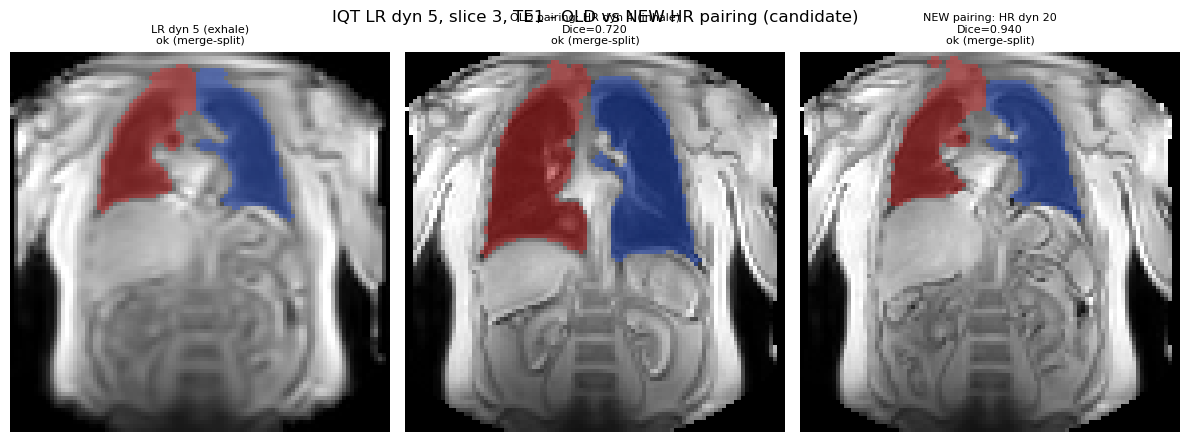

In [30]:
## SLIDE FIGURE 4 -- Dice distribution + per-pair table from the rewritten Step 7 pairing,
## plus an old-vs-new pairing comparison to check the left-lung diaphragm misalignment
## Yuliang flagged. The exact LR dynamic he flagged wasn't recorded anywhere in this
## notebook's history, so this reconstructs the OLD (pre-fix) _rescaled_position_curve
## pairing on the side (not touching the real notebook) and flags every LR dynamic where
## the two methods disagree on the matched HR dynamic AND that disagreement crosses a
## breathing-direction boundary (inhale vs exhale) - exactly the failure mode the phase-
## bin+direction rewrite targets. These are CANDIDATES for the flagged pair, not a
## confirmed match to it.

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(pairing_quality_df["mean_dice"].dropna(), bins=15, color="C0", edgecolor="black")
ax.set_xlabel("mean Dice (per pair, averaged across slices)")
ax.set_ylabel("count")
ax.set_title(f"Step 7 phase-bin pairing: Dice distribution ({len(pairing_quality_df)} pairs)")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "slide4a_dice_histogram.png", dpi=150, bbox_inches="tight")
plt.show()
print(pairing_quality_df.to_string(index=False))


def _old_rescaled_position_curve(curve):
    dynamics, smoothed = curve["dynamics"], curve["aggregate_smoothed"]
    ref_max = smoothed[dynamics.index(curve["max_dynamic"])]
    ref_min = smoothed[dynamics.index(curve["min_dynamic"])]
    return np.clip((smoothed - ref_min) / (ref_max - ref_min), 0.0, 1.0)


def _old_pair_lr_to_hr(lr_curve, lr_position, hr_curve, hr_position):
    hr_dynamics = np.asarray(hr_curve["dynamics"])
    hr_valid = ~np.isnan(hr_position)
    pairs = {}
    for i, lr_dyn in enumerate(lr_curve["dynamics"]):
        if np.isnan(lr_position[i]) or not hr_valid.any():
            pairs[lr_dyn] = None
            continue
        diffs = np.abs(hr_position[hr_valid] - lr_position[i])
        pairs[lr_dyn] = int(hr_dynamics[hr_valid][int(np.argmin(diffs))])
    return pairs


_old_hr_position = _old_rescaled_position_curve(iqt_results["curve"])
_old_lr_position = _old_rescaled_position_curve(lr_curve)
_old_lr_to_hr = _old_pair_lr_to_hr(lr_curve, _old_lr_position, iqt_results["curve"], _old_hr_position)

_mismatch_candidates = []
for _lr_dyn, _info in lr_pairing.items():
    _old_hr_dyn = _old_lr_to_hr.get(_lr_dyn)
    _new_hr_dyn = _info["hr_dynamic"]
    if _old_hr_dyn is None or _new_hr_dyn is None or _old_hr_dyn == _new_hr_dyn:
        continue
    _old_hr_info = hr_phase.get(_old_hr_dyn)
    _lr_info = lr_phase.get(_lr_dyn)
    if _old_hr_info is None or _lr_info is None:
        continue
    _direction_mismatch = _old_hr_info["direction"] != _lr_info["direction"]
    _mismatch_candidates.append({
        "lr_dyn": _lr_dyn, "old_hr_dyn": _old_hr_dyn, "new_hr_dyn": _new_hr_dyn,
        "lr_direction": _lr_info["direction"], "old_hr_direction": _old_hr_info["direction"],
        "direction_mismatch": _direction_mismatch,
    })
_mismatch_candidates.sort(key=lambda c: not c["direction_mismatch"])

print(f"\n{len(_mismatch_candidates)} LR dynamics where old vs new pairing disagree on the "
      f"matched HR dynamic:")
for _c in _mismatch_candidates:
    _flag = " <-- OPPOSITE BREATHING DIRECTION (old pairing crossed inhale/exhale)" if _c["direction_mismatch"] else ""
    print(f"  LR dyn {_c['lr_dyn']}: old->HR {_c['old_hr_dyn']} ({_c['old_hr_direction']}) vs "
          f"new->HR {_c['new_hr_dyn']} (LR itself is {_c['lr_direction']}){_flag}")


def _dice_for_pair(lr_dyn, hr_dyn, slice_num=3):
    lr_img = get_lr_te1_frame_for_segmentation(slice_num, lr_dyn)
    hr_img = load_iqt_hr_frame(slice_num=slice_num, echo_num=1, dynamic_num=hr_dyn)
    lr_seg = segment_lungs_te1(lr_img)
    hr_seg = segment_lungs_te1(hr_img)
    dice = dice_coefficient(lr_seg["combined_mask"], hr_seg["combined_mask"]) if (lr_seg["success"] and hr_seg["success"]) else None
    return dice, lr_img, hr_img, lr_seg, hr_seg


_top_candidates = [c for c in _mismatch_candidates if c["direction_mismatch"]][:2]
if not _top_candidates:
    _top_candidates = _mismatch_candidates[:2]
    print("\nNo direction-crossing disagreement found - showing the largest old-vs-new "
          "disagreements instead (candidates only, not confirmed matches to the flagged pair).")

for _cand in _top_candidates:
    _lr_dyn, _old_hr_dyn, _new_hr_dyn = _cand["lr_dyn"], _cand["old_hr_dyn"], _cand["new_hr_dyn"]
    _old_dice, _lr_img, _old_hr_img, _lr_seg, _old_hr_seg = _dice_for_pair(_lr_dyn, _old_hr_dyn)
    _new_dice, _, _new_hr_img, _, _new_hr_seg = _dice_for_pair(_lr_dyn, _new_hr_dyn)

    fig, axes = plt.subplots(1, 3, figsize=(12, 4.5))
    plot_segmentation_overlay(_lr_img, _lr_seg, ax=axes[0], title=f"LR dyn {_lr_dyn} ({_cand['lr_direction']})")
    _old_title = (f"OLD pairing: HR dyn {_old_hr_dyn} ({_cand['old_hr_direction']})\nDice={_old_dice:.3f}"
                  if _old_dice is not None else f"OLD pairing: HR dyn {_old_hr_dyn}\nseg failed")
    plot_segmentation_overlay(_old_hr_img, _old_hr_seg, ax=axes[1], title=_old_title)
    _new_title = (f"NEW pairing: HR dyn {_new_hr_dyn}\nDice={_new_dice:.3f}"
                  if _new_dice is not None else f"NEW pairing: HR dyn {_new_hr_dyn}\nseg failed")
    plot_segmentation_overlay(_new_hr_img, _new_hr_seg, ax=axes[2], title=_new_title)
    fig.suptitle(f"IQT LR dyn {_lr_dyn}, slice 3, TE1 - OLD vs NEW HR pairing (candidate)", fontsize=12)
    plt.tight_layout()
    fig.savefig(OUTPUT_DIR / f"slide4b_old_vs_new_pairing_lrdyn{_lr_dyn}.png", dpi=150, bbox_inches="tight")
    plt.show()
